In [ ]:
import matplotlib.pyplot as plt
def show(img,cma='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cma)
    a
    plt.show()

In [2]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

ret, frame = cap.read()
avg = np.float32(frame)  # convert to float32 for accumulation

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # accumulate weighted average
    cv2.accumulateWeighted(frame, avg, 0.1)

    # convert avg to uint8 for display
    res = cv2.convertScaleAbs(avg)

    cv2.imshow("Running Average Background", res)
    cv2.imshow("Current Frame", frame)

    if cv2.waitKey(1) == 27:  # press ESC to exit
        break

cap.release()
cv2.destroyAllWindows()


D:\zaynu\Documents\pythonfiles\CV_mod\foler_w_vids\hadcamphone.mp4

In [22]:
# backround substracton

import cv2
import numpy as np
import time
allcnts=[]                           
allcntsindexes=[]
mog2substractor=cv2.createBackgroundSubtractorMOG2()
knnsubstractor=cv2.createBackgroundSubtractorKNN()
# cam=cv2.VideoCapture(0)
cam=cv2.VideoCapture(r"D:\zaynu\Documents\pythonfiles\CV_mod\foler_w_vids\hadcamphone.mp4")
# cam=cv2.VideoCapture(r"D:\zaynu\Documents\pythonfiles\CV_mod\foler_w_vids\anirudhmoving.mp4")
# cam=cv2.VideoCapture(r"D:\zaynu\Documents\pythonfiles\CV_mod\foler_w_vids\floor2footage_1.mp4")
frametime=0
# minarea=int(input())
minarea=6000
print(minarea)
while True:
    if cv2.waitKey(1)==ord('q'):
        break
    ret,frame=cam.read()
    frametime+=1
    if frametime==2:
        time.sleep(2)
        s=time.time()
        
    if ret:
        
        
        knnmask=knnsubstractor.apply(frame)
        kernal=np.ones((2,2))
    
        
        fg=cv2.erode(knnmask.copy(),kernal,iterations=2)
        fg=cv2.dilate(fg,           kernal,iterations=2)
        fg[np.abs(fg)<250]=0
        knnmask=fg.copy()
        cnts,hierarchy=cv2.findContours(knnmask,cv2.RETR_CCOMP,cv2.CHAIN_APPROX_SIMPLE)
        # knnmask=cv2.cvtColor(knnmask,cv2.COLOR_GRAY2BGR)
        fgcnted=np.zeros((knnmask.shape[0],knnmask.shape[1],3))
        # framcnts=[]
        framcntsindexes=[]
        # print("Frameno ",frametime)
        for i in range(len(cnts)):
            if hierarchy[0][i][3]==-1:
                if cv2.contourArea(cnts[i])>minarea:
                    cv2.drawContours(fgcnted,cnts,i,(0,255,0),4)
                    
                    framcntsindexes.append(i)
                    
                    # framcnts.append(cnts)
        allcnts.append(cnts)          
        allcntsindexes.append(framcntsindexes) 
        cv2.imshow("backsubstraction",fg)    
        cv2.imshow("drawn_contours",fgcnted)    
        # cv2.imshow("normal",frame)    
    else:
        print("no ret")
        break
cv2.destroyAllWindows()
cam.release()

print(time.time()-s)
    

6000
no ret
8.9977548122406


In [4]:
knnmask.shape

(1280, 720)

In [ ]:
6.89
12.22

In [18]:
frametime

421

In [18]:
import math
import numpy as np
class Point:
    def __init__(self,x,y):
        self.x=x
        self.y=y
    
    def __str__(self):
        return f"[{self.x},{self.y}]"
    def coords(self):
        return (self.x,self.y)

class Box:
    def __init__(self,x,y,w,h):
        self.TL=Point(x,y)
        self.w=w
        self.h=h
        self.BL=Point(x,y+h)
        self.TR=Point(x+w,y)
        self.BR=Point(x+w,y+h)
        self.centre=Point(x+w//2,y+h//2)
        
    def __str__(self):
        temp=np.zeros(shape=(self.h+1,self.w+1))*10001
        temp.dtype="str"
        # temp[*(self.TL.coords()[::-1])]=str(self.TL)
        # temp[*(self.TR.coords()[::-1])]=str(self.TR)
        # temp[*(self.BL.coords()[::-1])]=str(self.BL)
        # temp[*(self.BR.coords()[::-1])]=str(self.BR)
        temp[0,0]=f"[{self.w},{self.h}]"
        
        return str(temp)
        
def betweenBox(b1,b2,axis=0):
    if ((b1.TL.x<b2.TL.x and b2.TL.x<b1.TR.x) or b1.TL.x<b2.TR.x and b2.TR.x<b1.TR.x):
        return True
    else:
        return False
    
def hypolen(s,w):
    return w/math.cos(math.atan(s))

def dist(p1,p2):
    return math.sqrt((p1.x-p2.x)**2+(p1.x-p2.x)**2)

def closeproximity(b1,b2,aproxmin):
    s=slope(b1.centre,b2.centre)
    
    if not (betweenBox(b1,b2,0)):
        base1=b1.w
        base2=b2.w
    else:
        base1=b1.h
        base2=b2.h
        
     
    hyp=hypolen(s,base1)+hypolen(s,base2)
    if dist(b1.centre,b2.centre) >hyp+ aproxmin:
        return False
    else:
        return True
    
def slope(p1:Point  ,p2:Point) ->float:
    return (p1.y-p2.y)/(p1.x-p2.x)


def combiner(b1:Box,b2:Box,s:float):
    if s<0:
        sortedpo=sorted([b1.TR,b1.BL,b2.TR,b2.BL],key=lambda x: x.x)
        # TR=sortedpo[-2:].sort(key=lambda x: x.y)[-1]  
        # BL=sortedpo[:2].sort(key=lambda x: x.y)[0]  
        TR=max(sortedpo[-2:],   key=lambda x: x.y) 
        BL=min(sortedpo[:2],   key=lambda x: x.y) 
        return Box(BL.x,TR.y,TR.x-BL.x,BL.y-TR.y)
    
    else:
    
        sortedpo=sorted([b1.TL,b1.BR,b2.TL,b2.BR],key=lambda x: x.x)
        print([i.x for  i in sortedpo])
        TL=max(sortedpo[:2],   key=lambda x: x.y) 
        BR=min(sortedpo[-2:],   key=lambda x: x.y) 
        # TL=sortedpo[:2].sort(key=lambda x: x.y)[-1] 
        # BR=sortedpo[-2:].sort(key=lambda x: x.y)[0]  
        return Box(TL.x,TL.y,BR.x-TL.x,BR.y-TL.y)
        
        




def lessen_boxes(boxarray:list):
    for i in range(boxarray):
        for j in range(i+1,boxarray):
            while closeproximity(boxarray[i],boxarray[j]):
                boxarray[i]=combiner(boxarray[i],boxarray[j],slope(boxarray[i].centre,boxarray[j].centre))
                boxarray.remove(boxarray[j])
    return boxarray


                                                            


# p1=Box(0,0,1,1)    
# p2=Box(4,5,1,1)    
# print(slo:=slope(p2.centre,p1.centre))
# print(closeproximity(p2,p1,10))
                                                                
# if closeproximity(p1,p2,10):
#     b=combiner(p1,p2,slo)

# print(b.TL,b.TR)
# print(b.BL,b.BR)
# print(b)







In [19]:
import matplotlib.pyplot as plt

In [20]:
testimge=np.zeros((1280,720,3))
framenumber=200
tempcountursindexes=allcntsindexes[framenumber-1]
tempcounturs=allcnts[framenumber-1]
sortedtempcountursindexes=sorted(tempcountursindexes,key=lambda x:1/cv2.contourArea(tempcounturs[x]))
contourcount=len(sortedtempcountursindexes)

for i in sortedtempcountursindexes[:contourcount]:
# for i in sortedtempcountursindexes[:1]:
    cv2.drawContours(testimge,tempcounturs,i,(0,0,255),4)

# framcnts
show(testimge)

print(len(allcnts))
print("\n")
# print(frametime)
print(framenumber)
print(contourcount)
print("\n"*2)
for i in sortedtempcountursindexes:
    print(cv2.contourArea(tempcounturs[i]))
    
print("centre dists")
for j in range(len(sortedtempcountursindexes)-1):
    print(dist(Box(*cv2.boundingRect(tempcounturs[j])).centre,Box(*cv2.boundingRect(tempcounturs[j+1])).centre   ))                
    # print(dist(Box(*cv2.boundingRect(tempcounturs[j])).centre,Box(*cv2.boundingRect(tempcounturs[j+1])).centre   ))                
print("\n"*2)
print(type(np.array(cv2.boundingRect(tempcounturs[j]))))
contourcountlist=[len(i) for i in allcntsindexes]
print(max(contourcountlist[210::]))


NameError: name 'allcntsindexes' is not defined

In [13]:
len(tempcounturs[0])

4

In [ ]:

# contourcountlist=np.array([len(i) for i in allcntsindexes])
# print(contourcountlist[233:280].max())
# print(contourcountlist[233:280].argmax())

1
0


In [ ]:
print(allcnts[1],
allcntsindexes[1])
print(allcnts[1],
allcntsindexes[1])

(array([[[   0,    0]],

       [[   0, 1279]],

       [[ 719, 1279]],

       [[ 719,    0]]], dtype=int32),) [0]


In [ ]:
cv2.ContourApproximationModes

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(2952, 1, 2)
(2952, 2)


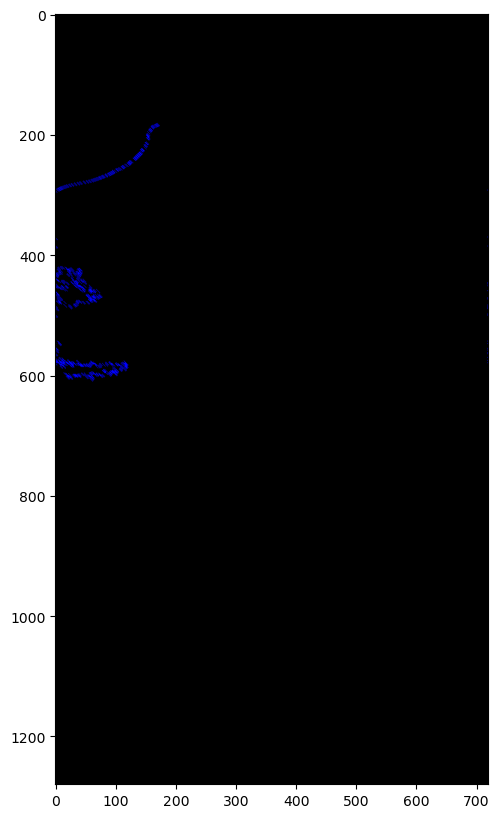

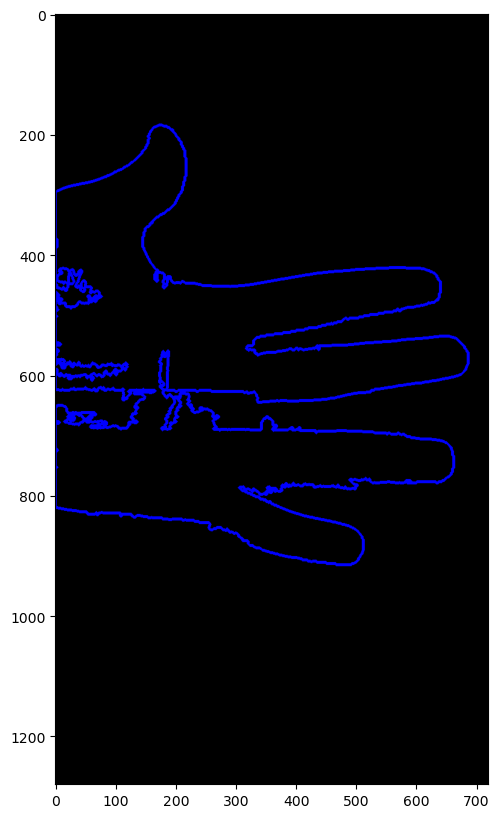

In [83]:
# for i in sortedtempcountursindexes:
smalcnt=tempcounturs[sortedtempcountursindexes[0]]
testimge2=np.zeros((1280,720,3))

smalcnt=np.array(smalcnt)
print(smalcnt.shape)
smalcnt=smalcnt.squeeze()
print(smalcnt.shape)
for r,c in smalcnt[:round(len(smalcnt)/4)]:
    for i in range(5):
        testimge2[c-3+i,r-3+i]=[0,0,255]
        # testimge2[c+1,r+1]=[0,0,255]
        # testimge2[c-1,r-1]=[0,0,255]
show(testimge2)
show(testimge)


# for i in sortedtempcountursindexes[:contourcount]:
# # for i in sortedtempcountursindexes[:1]:
#     cv2.drawContours(testimge2,tempcounturs,i,(0,0,255),4)
# show(testimge2)


In [3]:
import cv2
import numpy as np
import face_recognition as FRE
import math
import time
from typing import List,Dict,Sequence
import face_recognition as FR
import matplotlib.pyplot as plt
def show(img,cma='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cma)
    
    plt.show()

class Point:
    def __init__(self,x,y):
        self.x=x
        self.y=y
    
    def __str__(self):
        return f"[{self.x},{self.y}]"
    def coords(self):
        return (self.x,self.y)

class Box: 
    def __init__(self,x:int,y:int,w:int,h:int):
        self.TL=Point(x,y)
        self.w=w
        self.h=h
        self.BL=Point(x,y+h)
        self.TR=Point(x+w,y)
        self.BR=Point(x+w,y+h)
        self.centre=Point(x+w//2,y+h//2)
        
    def __str__(self):
        
        return f"{self.TL} {self.TR} {self.BL} {self.BR}"
    

def nameread()->str : 
    return 'name'



        
def betweenBox(b1,b2,axis=0):
    if ((b1.TL.x<=b2.TL.x and b2.TL.x<=b1.TR.x) or (b1.TL.x<=b2.TR.x and b2.TR.x<=b1.TR.x)):
        # print("stat1",(b1.TL.x<b2.TL.x and b2.TL.x<b1.TR.x))
        # print("stat2",(b1.TL.x<b2.TR.x and b2.TR.x<b1.TR.x))
        return True
    else:
        return False
    
def hypolen(s,w,inverse=False):
    if inverse:
        return abs(w/math.cos(((math.pi/2)-math.atan(s))))
        
    return abs(w/math.cos(math.atan(s)))

def dist(p1,p2):
    return math.sqrt(((p1.x-p2.x)**2)+((p1.y-p2.y)**2))

def slope(p1:Point  ,p2:Point) ->float:
    if  (p1.x-p2.x)!=0:
        return (p1.y-p2.y)/(p1.x-p2.x)
    else:
        return (p1.y-p2.y)/(1)

def closeproximity(b1,b2,aproxmin,multi):
    s=slope(b1.centre,b2.centre)
    
    if not (betweenBox(b1,b2,0)):
        base1=b1.w
        base2=b2.w
        inverse=False
    else:
        base1=b1.h
        base2=b2.h
        inverse=True
    
    # print("isbetweeb" ,betweenBox(b1,b2,0))
    
    hyp1=hypolen(s,base1,inverse)
    # print(hyp1)
    hyp2=hypolen(s,base2,inverse)
    # print(hyp2)
    hyp=hyp1+hyp2
    
    # print("total dist is",dist(b1.centre,b2.centre))
    if dist(b1.centre,b2.centre) >hyp+ aproxmin*multi:
        return False
    else:
        return True
    


def combiner(b1:Box,b2:Box,s:float):
    if s<0:
        sortedpo=sorted([b1.TR,b1.BL,b2.TR,b2.BL],key=lambda x: x.x)
        # TR=sortedpo[-2:].sort(key=lambda x: x.y)[-1]  
        # BL=sortedpo[:2].sort(key=lambda x: x.y)[0]  
        TR=min(sortedpo[-2:],   key=lambda x: x.y) 
        BL=max(sortedpo[:2],   key=lambda x: x.y) 
        return Box(BL.x,TR.y,TR.x-BL.x,BL.y-TR.y)
    
    else:
    
        sortedpo=sorted([b1.TL,b1.BR,b2.TL,b2.BR],key=lambda x: x.x)
        print([i.x for  i in sortedpo])
        TL=min(sortedpo[:2],   key=lambda x: x.y) 
        BR=max(sortedpo[-2:],   key=lambda x: x.y) 
        # TL=sortedpo[:2].sort(key=lambda x: x.y)[-1] 
        # BR=sortedpo[-2:].sort(key=lambda x: x.y)[0]  
        return Box(TL.x,TL.y,BR.x-TL.x,BR.y-TL.y)
        
        

def coordsToBoxes(coordslist):
    return  [Box(*i) for i in coordslist]

def BoxesToCoords(boxlist:list[Box])->list[tuple[int,int,int,int]]:
            return [ (b.TL.x,b.TL.y,b.w,b.h) for b in boxlist ] 

    


def lessen_boxes(boxarray:list[Box],resolution=(1080,720)):
    for i in range(len(boxarray)):
        for j in range(i+1,len(boxarray)):
            while closeproximity(boxarray[i],boxarray[j],resolution[1],1):
                print("i and j are ",i,j)   
                    # print("while iteration")
                print("pre change ",[ str(i) for i in boxarray])
                
                boxarray[i]=combiner(boxarray[i],boxarray[j],slope(boxarray[i].centre,boxarray[j].centre))
                
                boxarray.remove(boxarray[j])
                print("post change",[ str(i) for i in boxarray])
                if j>len(boxarray)-1:
                    break
            if j>len(boxarray)-1:
                break
    print("\n")
    return boxarray




def frame_large_countours(knnmask,minarea=5000,give_contours=False)->np.ndarray|tuple[np.ndarray, tuple[tuple, list[int]]]:
    cnt_indexes=[]
    rectangles=[]
    kernal=np.ones((2,2))
    fg=cv2.erode(knnmask.copy(),kernal,iterations=2)
    fg=cv2.dilate(fg           ,kernal,iterations=2)
    cnts,hierarchy=cv2.findContours(knnmask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for i in range(len(cnts)):
            if hierarchy[0][i][3]==-1:
                if cv2.contourArea(cnts[i])>minarea:
                    rectangles.append(np.array(cv2.boundingRect(cnts[i])))
                    if give_contours:
                        cnt_indexes.append(i)
    if give_contours:
        return (np.array(rectangles),(cnts,cnt_indexes))
    return np.array(rectangles)


cap=cv2.VideoCapture(r"D:\zaynu\Documents\pythonfiles\CV_mod\foler_w_vids\hadcamphone.mp4")
knnsubstractor=cv2.createBackgroundSubtractorKNN()
frameno=0
minarea=7000

ret,frame=cap.read()

fgcnted=np.zeros((frame.shape[0],frame.shape[1],3))


# s=time.time()

selectedframe=240
selectedframe=242
# selectedframe=246
while True:
    
    
    if cv2.waitKey(1)==ord('q'):
        break
    # if cv2.waitKey(0)==ord('k'):
    #     pass
    ret,frame=cap.read()
    if ret:
        frameno+=1
        if frameno==2:
            time.sleep(2)
            s=time.time()
            

        knnmask=knnsubstractor.apply(frame)

        kernal=np.ones((2,2))
        fg=cv2.erode(knnmask.copy(),kernal,iterations=2)
        fg=cv2.dilate(fg,           kernal,iterations=2)
        fg[np.abs(fg)<250]=0
        # if True:
        if fg[fg>0].size >knnmask.size*0.05 or True:
            rectangles,(counturs,cntIndexes)=frame_large_countours(fg,minarea,give_contours=True)
            for i in cntIndexes:
                cv2.drawContours(fgcnted,counturs,i,(0,255,0),4)
                
            boxes=coordsToBoxes(rectangles)
            combined_rectangles=BoxesToCoords(lessen_boxes(boxes,fg.shape[:2]))
            for x,y,w,h in combined_rectangles:
                fgcnted=cv2.rectangle(fgcnted,(x,y),(x+w,y+h),(0,0,255),4)
            if len(rectangles)>1:
                print("fraameno:",frameno)
        cv2.imshow("backsubstraction",fg)    
        cv2.imshow("drawn_contours",fgcnted) 
        if frameno==selectedframe:
            selected_fc=fgcnted.copy()
            selected_rectangles=rectangles
            (selected_counturs,selected_cntIndexes)=(counturs,cntIndexes)
            selected_boxes=boxes
            selected_combined_rectangles=combined_rectangles
        
        fgcnted*=0
    else:
        print("no frame")
        break
cv2.destroyAllWindows()
cap.release()
print(time.time()-s)
    
    
        






































































































































































































































































































































































i and j are  0 1
pre change  ['[0,699] [128,699] [0,802] [128,802]', '[0,544] [109,544] [0,627] [109,627]']
[0, 0, 109, 128]
post change ['[0,544] [128,544] [0,802] [128,802]']


fraameno: 178
i and j are  0 1
pre change  ['[0,699] [133,699] [0,801] [133,801]', '[0,545] [118,545] [0,629] [118,629]']
[0, 0, 118, 133]
post change ['[0,545] [133,545] [0,801] [133,801]']


fraameno: 179
i and j are  0 1
pre change  ['[0,699] [141,699] [0,801] [141,801]', '[0,544] [128,544] [0,629] [128,629]']
[0, 0, 128, 141]
post change ['[0,544] [141,544] [0,801] [141,801]']


fraameno: 180
i and j are  0 1
pre change  ['[0,699] [144,699] [0,802] [144,802]'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


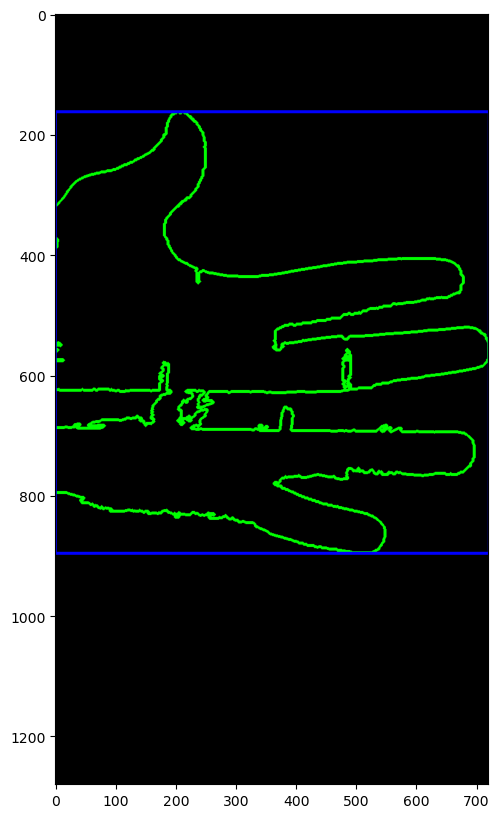

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


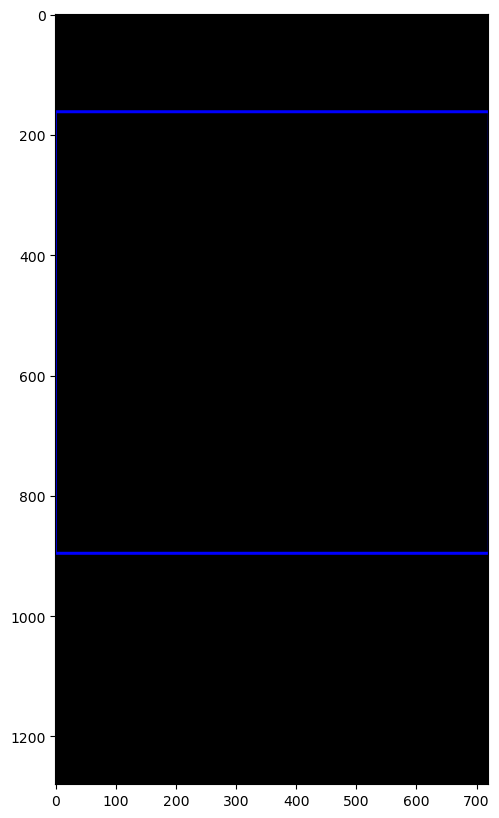

[[  0 162 720 734]]


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [2]:
show(selected_fc)
fgtest=np.zeros(shape=selected_fc.shape)
for x,y,w,h in selected_rectangles:
    fgtest=cv2.rectangle(fgtest,(x,y),(x+w,y+h),(0,0,255),4)
show(fgtest)
print(selected_rectangles)
print

In [ ]:
def dist(p1,p2):
    return math.sqrt(((p1.x-p2.x)**2)+((p1.y-p2.y)**2))
def hypolen(s,w,inverse=False):
    if inverse:
        return abs(w/math.cos(((math.pi/2)-math.atan(s))))
        
    return w/math.cos(math.atan(s))
def betweenBox(b1,b2,axis=0):
    if ((b1.TL.x<=b2.TL.x and b2.TL.x<=b1.TR.x) or (b1.TL.x<=b2.TR.x and b2.TR.x<=b1.TR.x)):
        # print("stat1.1",(b1.TL.x<b2.TL.x ))
        # print("stat1.2",(b2.TL.x<b1.TR.x))
        # print("stat2.1",(b1.TL.x<b2.TR.x ))
        # print("stat2.2",( b2.TR.x<b1.TR.x))
        return True
    else:
        # print("stat1.1",(b1.TL.x<b2.TL.x ))
        # print("stat1.2",(b2.TL.x<b1.TR.x))
        # print("stat2.1",(b1.TL.x<b2.TR.x ))
        # print("stat2.2",( b2.TR.x<b1.TR.x))
        return False

def testcloseproximity(b1,b2,aproxmin,multi):
    s=slope(b1.centre,b2.centre)
    
    if not (betweenBox(b1,b2,0)):
        base1=b1.w
        base2=b2.w
        inverse=False
    else:
        base1=b1.h
        base2=b2.h
        inverse=True
    
    print("isbetweeb" ,betweenBox(b1,b2,0))
    
    hyp1=hypolen(s,base1,inverse)
    print(hyp1)
    hyp2=hypolen(s,base2,inverse)
    print(hyp2)
    hyp=hyp1+hyp2
    
    print("total dist is",dist(b1.centre,b2.centre))
    if dist(b1.centre,b2.centre) >hyp+ aproxmin*multi:
        return False
    else:
        return True
    
def slope(p1:Point  ,p2:Point) ->float:
    if  (p1.x-p2.x)!=0:
        return (p1.y-p2.y)/(p1.x-p2.x)
    else:
        return (p1.y-p2.y)/(1)


b1=Box(  0, 687, 208, 115)
b2=Box(  0, 535, 217, 106)
b3=Box(  0, 426, 175,  88)
isclose=testcloseproximity(b1,b2,720,1)
print(isclose)
print(slo:=slope(b1.centre,b2.centre))
# print(hypolen(slo,))
# Lb=combiner(b1,b2,slope(b1.centre,b2.centre))
# print( BoxesToCoords([Lb]))
# # print( Lb.TL,Lb.w,Lb.h)
# for x,y,w,h in BoxesToCoords([Lb]):
#     fgtest=cv2.rectangle(fgtest,(x,y),(x+w,y+h),(0,255,255),4)
# show(fgtest)

# sclose=closeproximity(Lb,b3,720)
# print(isclose)
# print(slope(Lb.centre,b3.centre))
# NLb=combiner(Lb,b3,slope(Lb.centre,b3.centre))
# print( NLb)
# for x,y,w,h in BoxesToCoords([NLb]):
#     copfgtest=cv2.rectangle(fgtest,(x,y),(x+w,y+h),(0,255,255),4)
# show(copfgtest)

stat1.1 False
stat1.2 True
stat2.1 True
stat2.2 False
stat1.1 False
stat1.2 True
stat2.1 True
stat2.2 False
isbetweeb True
115.03779786461965
106.03483977086681
total dist is 156.05127362504928
True
-39.0


In [89]:
s=1
print(math.pi/4)
print(math.atan(s))
print(math.cos(math.atan(s)))

0.7853981633974483
0.7853981633974483
0.7071067811865476


In [73]:
def test_lessen_boxes(boxarray:list[Box],resolution=(1080,720)):
    for i in range(len(boxarray)):
        for j in range(i+1,len(boxarray)):
            while closeproximity(boxarray[i],boxarray[j],resolution[1]):
                print("i and j are ",i,j)   
                    # print("while iteration")
                print("pre change ",[ str(i) for i in boxarray])
                
                boxarray[i]=combiner(boxarray[i],boxarray[j],slope(boxarray[i].centre,boxarray[j].centre))
                
                boxarray.remove(boxarray[j])
                print("post change",[ str(i) for i in boxarray])
                if j>len(boxarray)-1:
                    break
            if j>len(boxarray)-1:
                break
    print("\n")
    return boxarray

print(selected_rectangles)
print(test_lessen_boxes(coordsToBoxes(selected_rectangles)))


[[  0 687 208 115]
 [  0 535 217 106]
 [  0 426 175  88]]
i and j are  0 1
pre change  ['[0,687] [208,687] [0,802] [208,802]', '[0,535] [217,535] [0,641] [217,641]', '[0,426] [175,426] [0,514] [175,514]']
post change ['[0,535] [217,535] [0,802] [217,802]', '[0,426] [175,426] [0,514] [175,514]']
i and j are  0 1
pre change  ['[0,535] [217,535] [0,802] [217,802]', '[0,426] [175,426] [0,514] [175,514]']
[0, 0, 175, 217]
post change ['[0,426] [217,426] [0,802] [217,802]']




2160
True 1
entered show


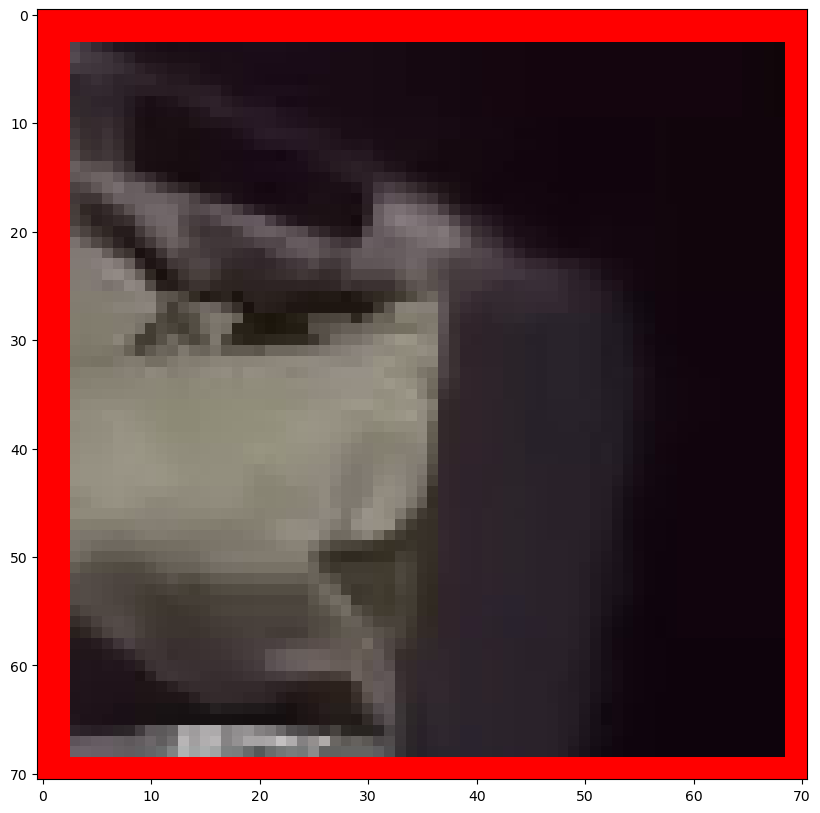




True 1
entered show


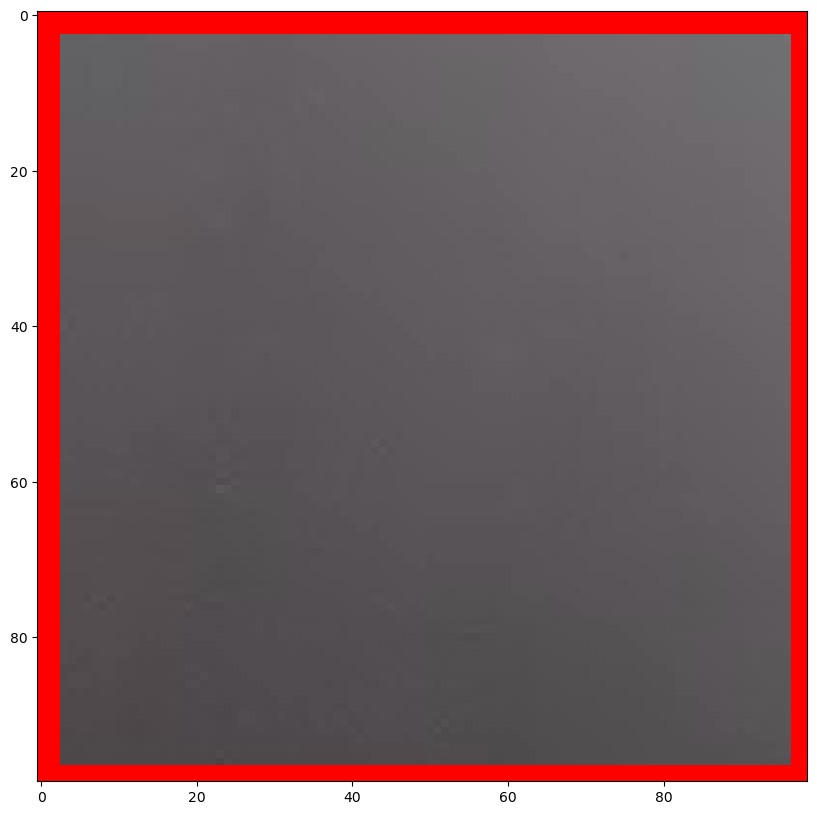




True 1
entered show


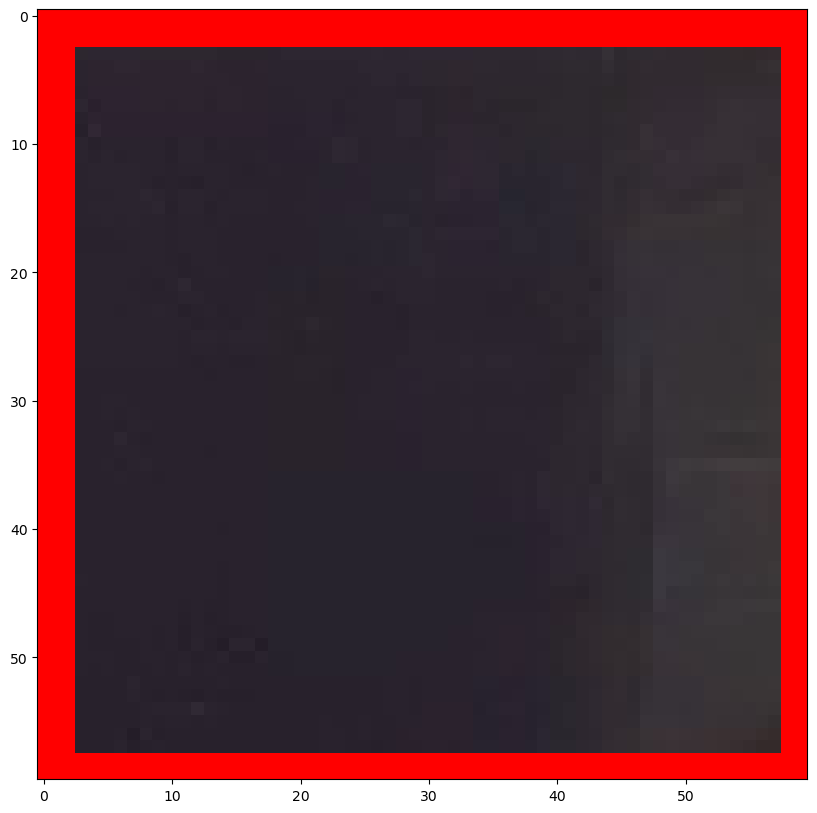




True 1
entered show


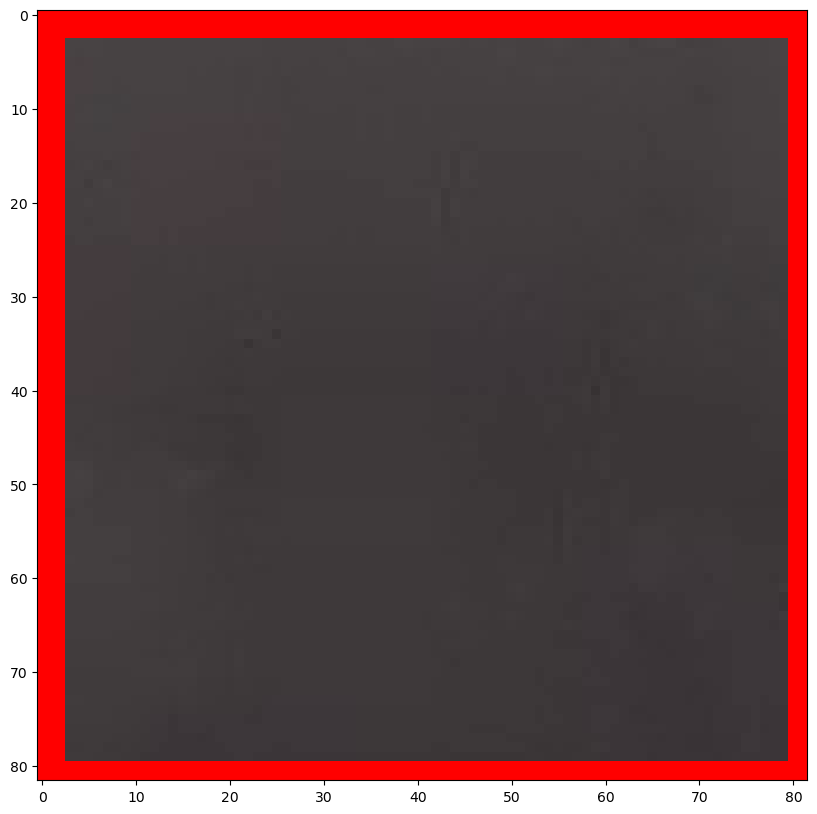




True 1
entered show


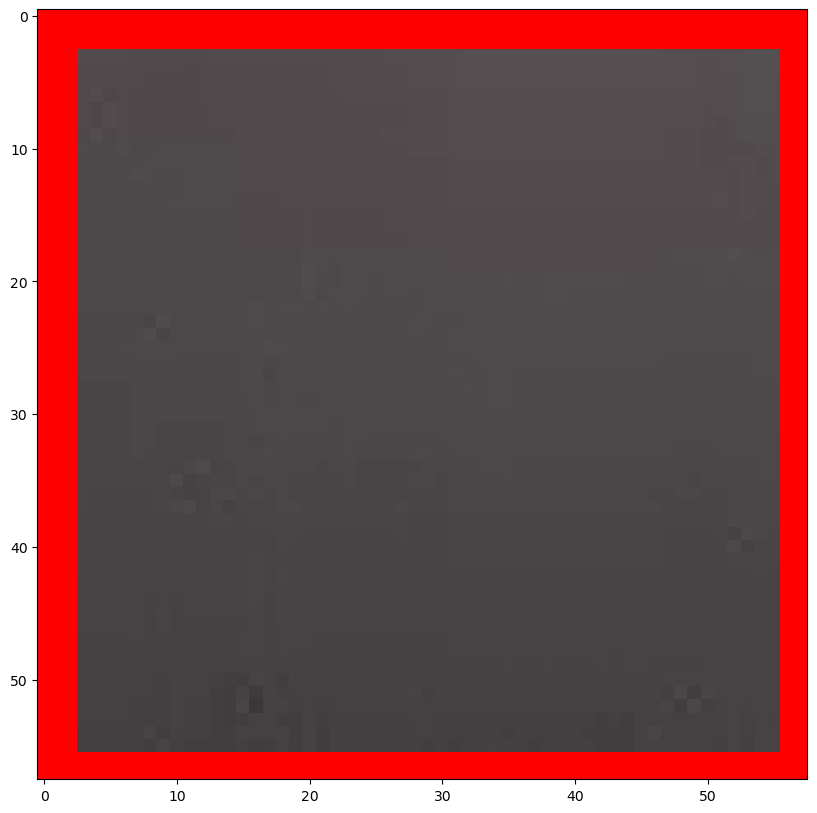




True 1
entered show


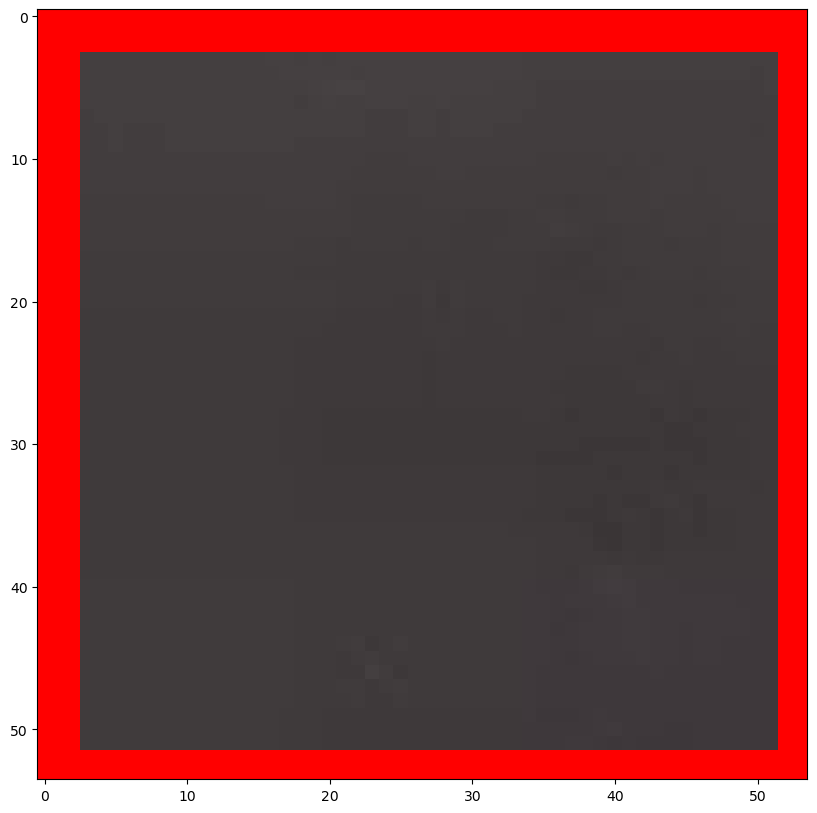




True 1
entered show


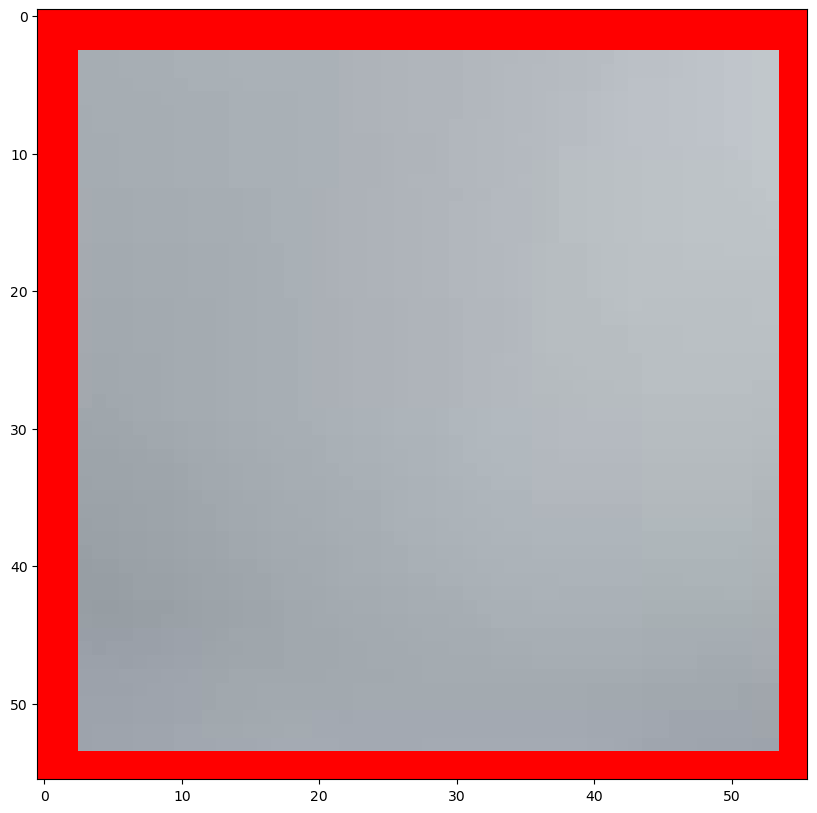




True 1
entered show


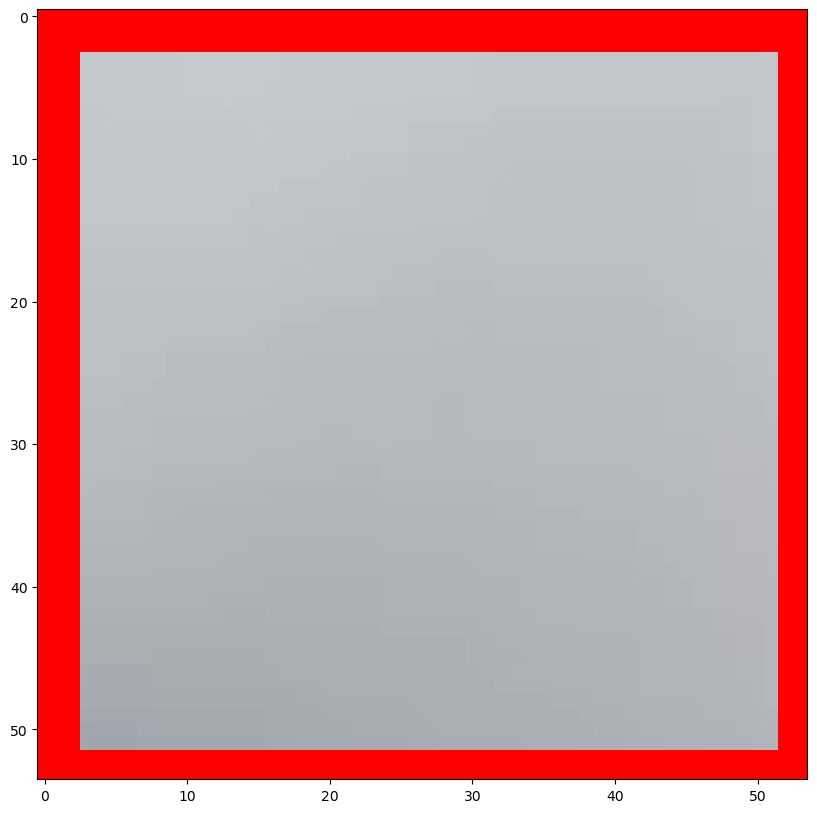




True 1
entered show


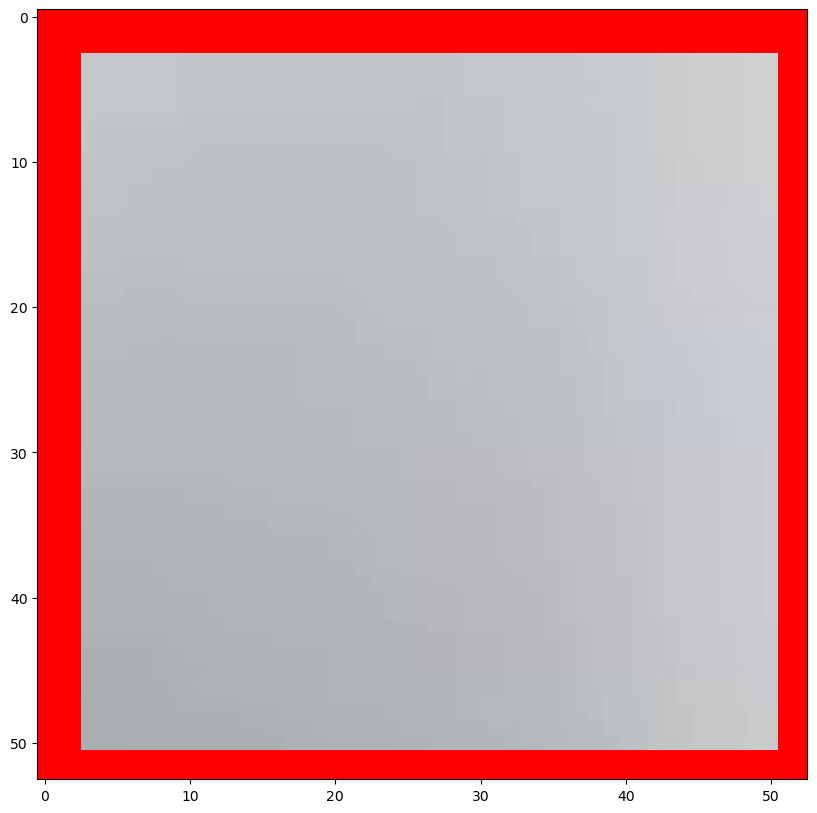




True 1
entered show


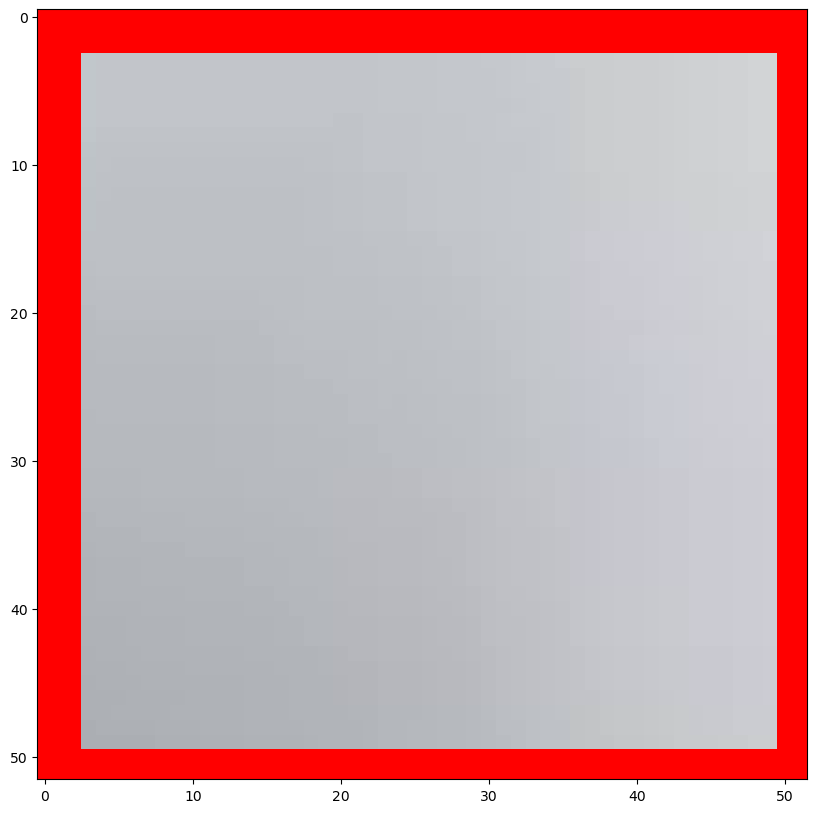




True 1
entered show


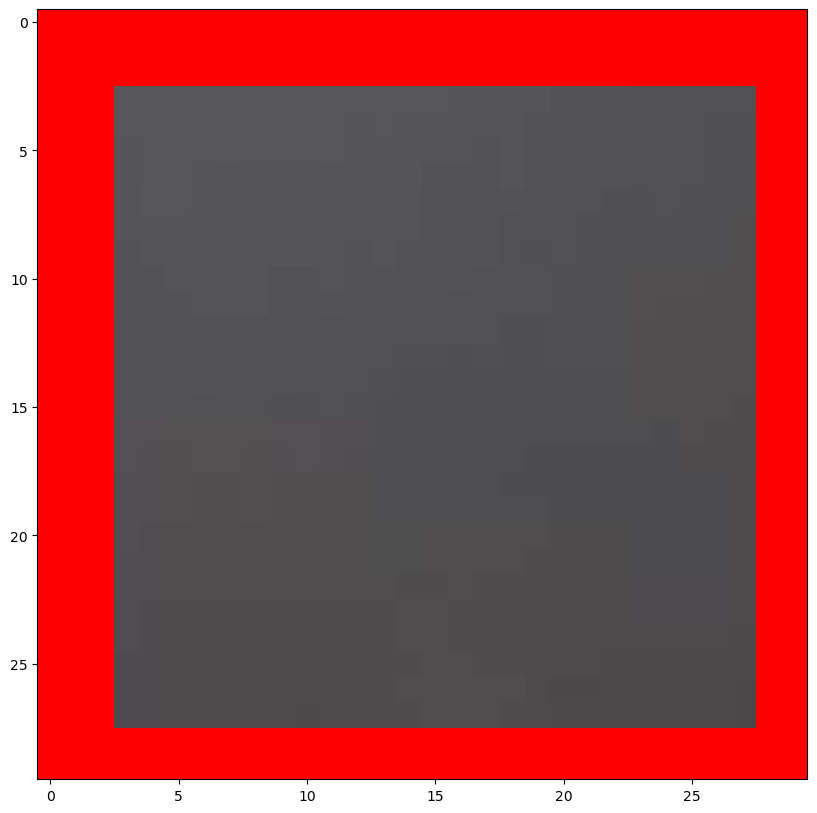

True 2
entered show


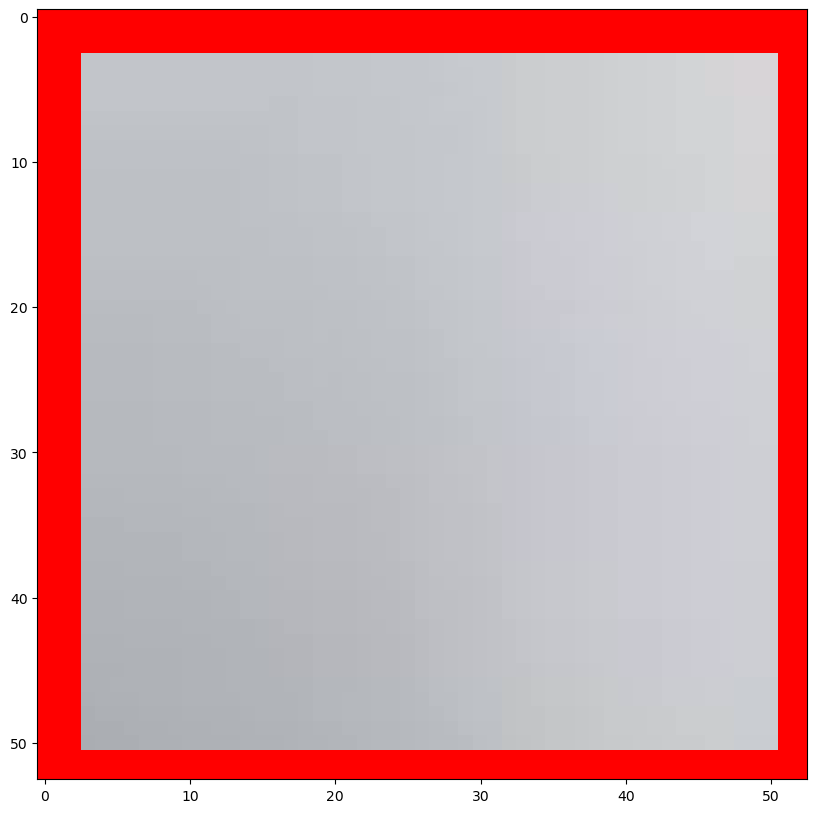




True 1
entered show


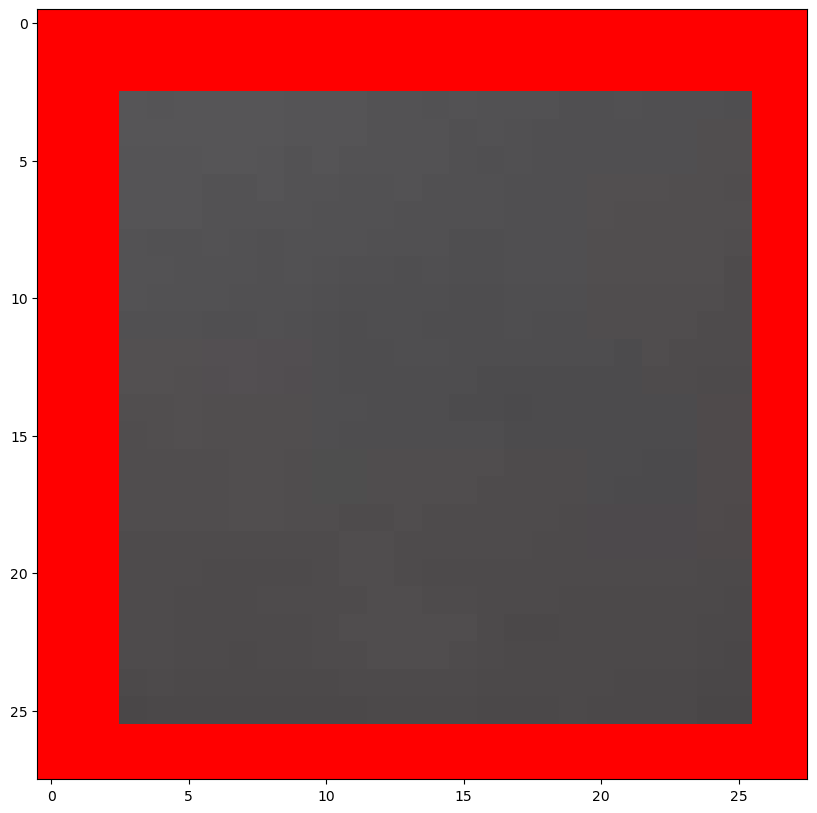

True 2
entered show


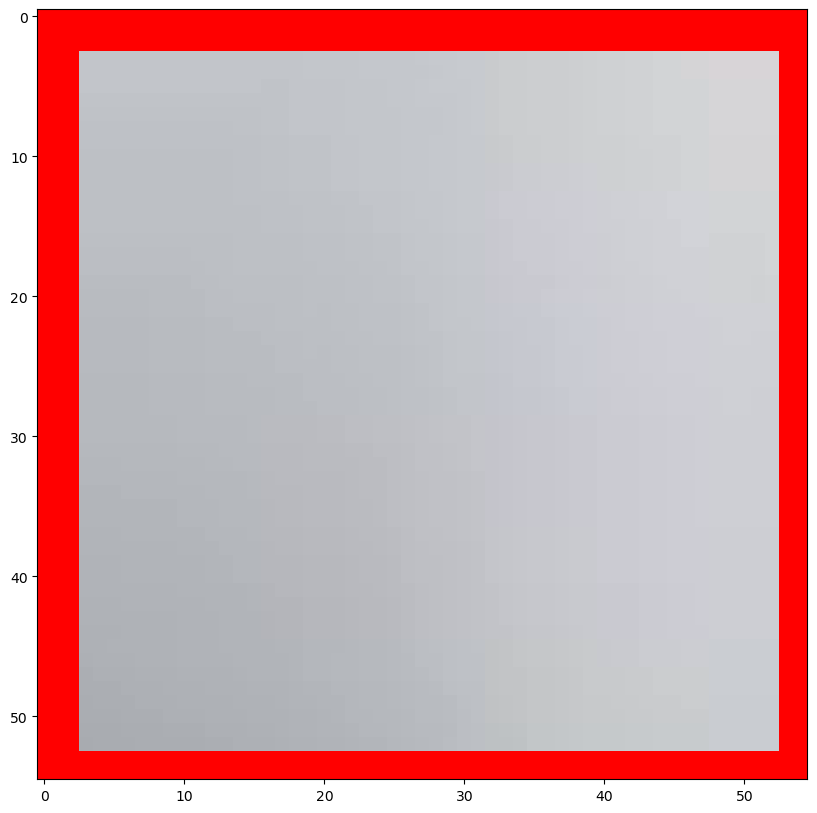




True 1
entered show


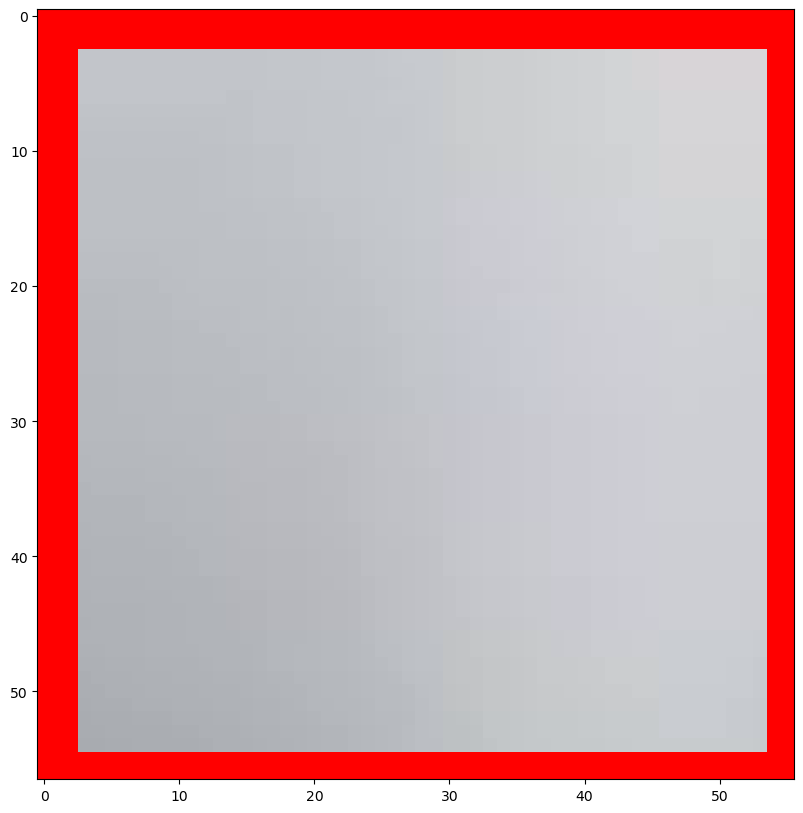




True 1
entered show


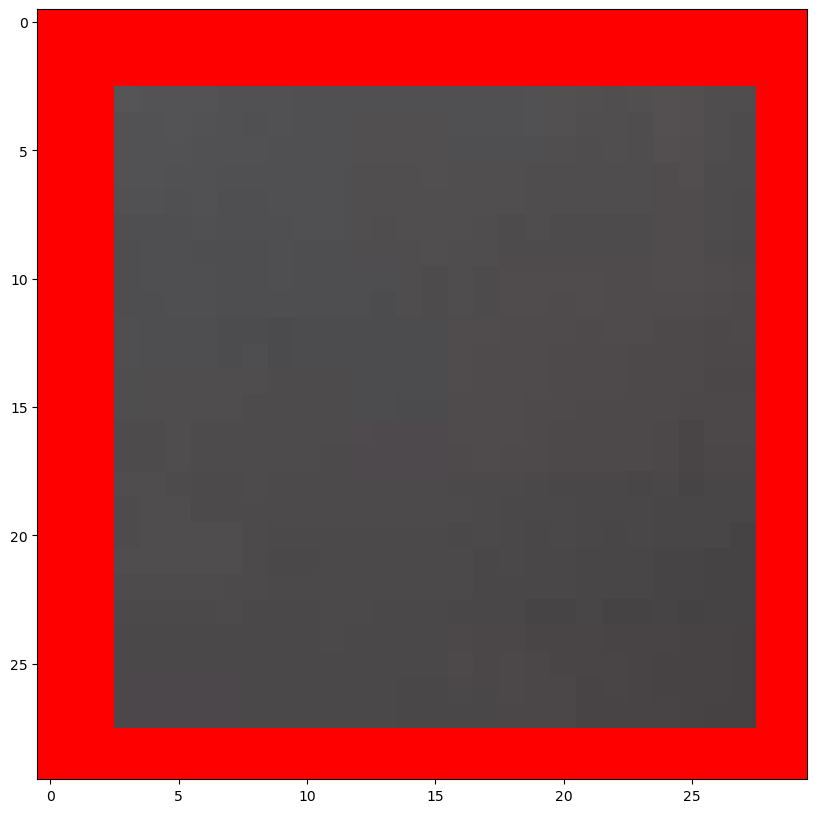




True 1
entered show


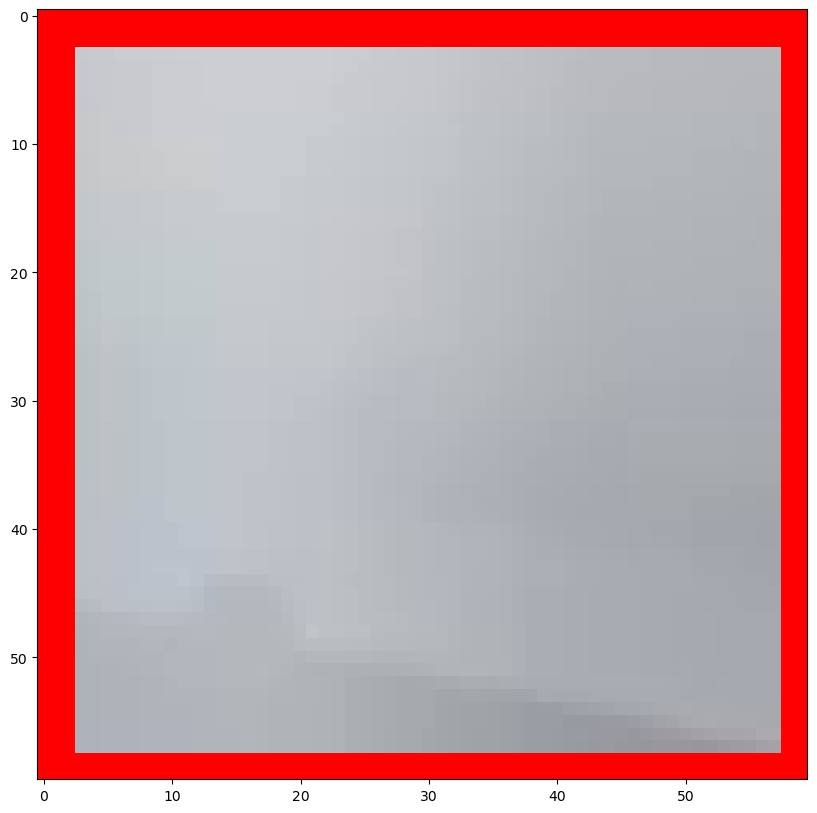




False 1
entered show


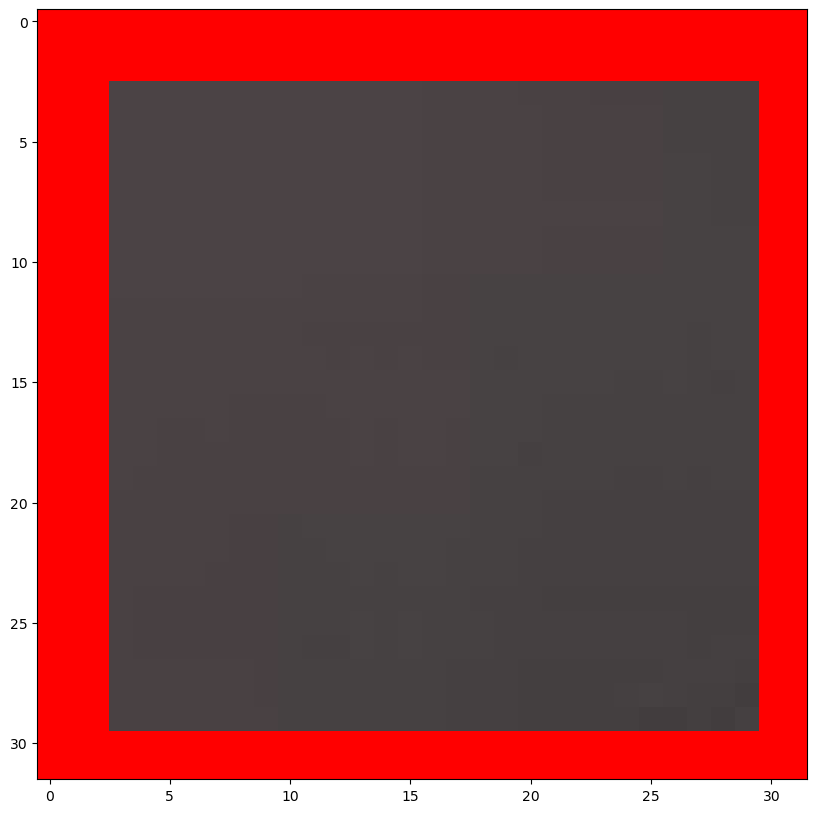

False 2
entered show


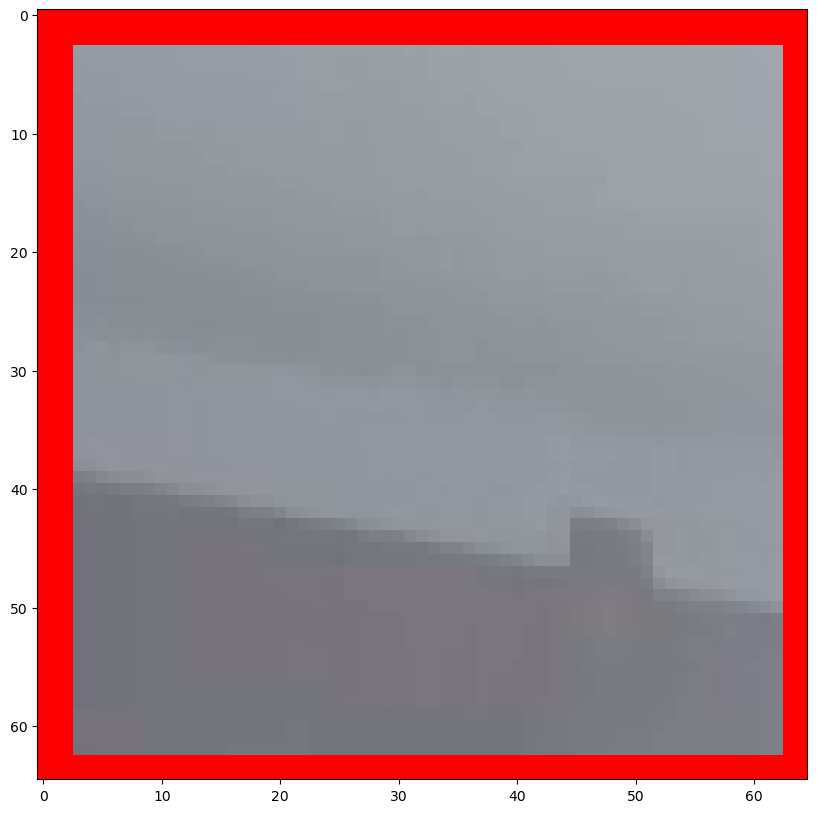




False 1
entered show


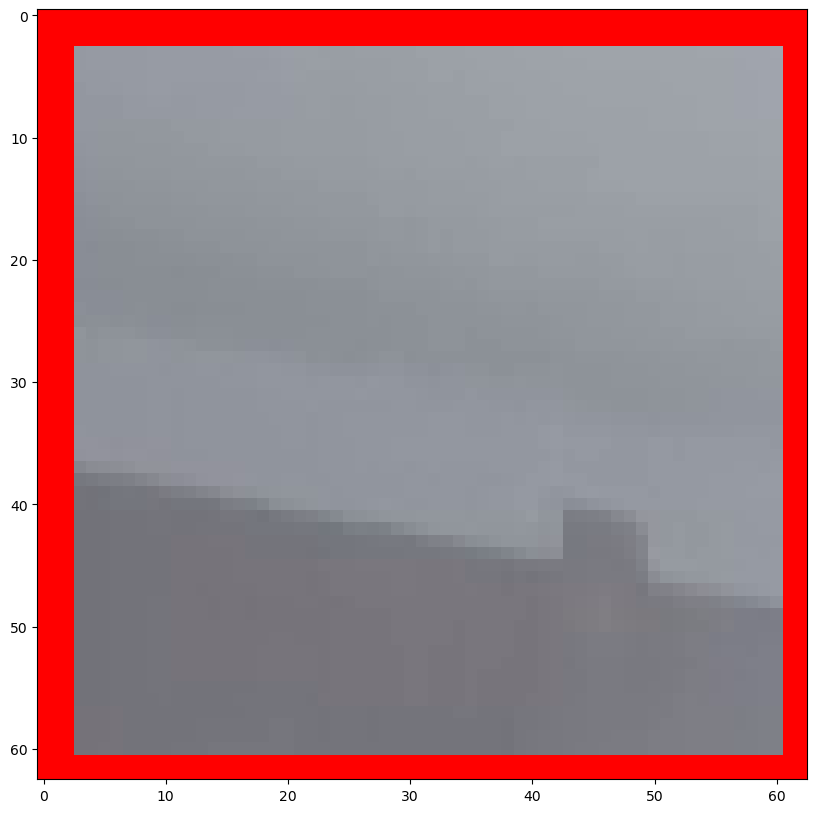

False 2
entered show


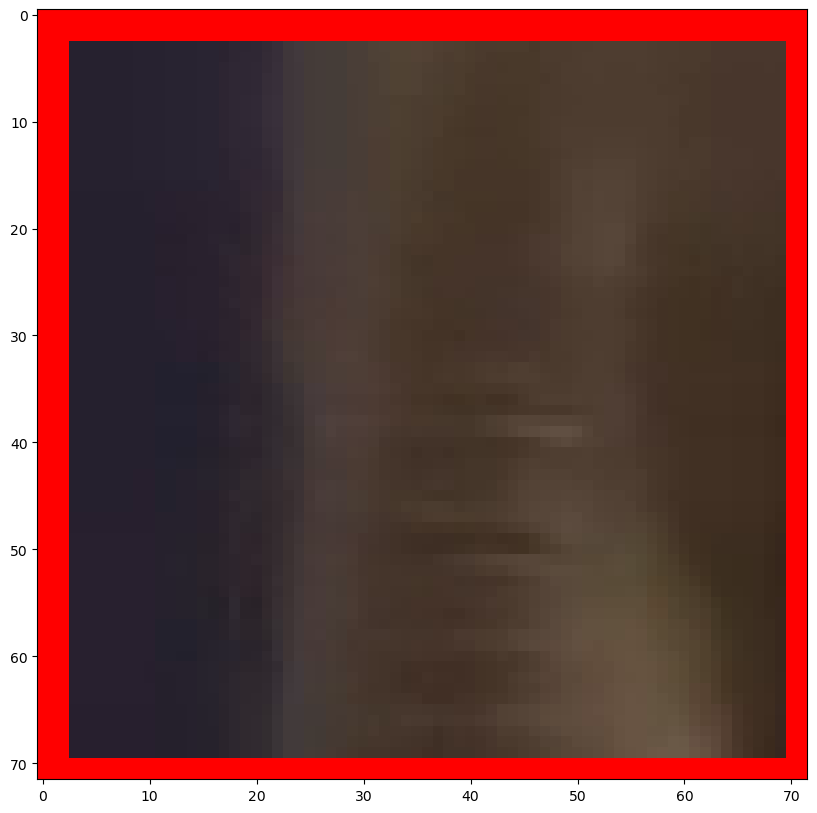




True 1
entered show


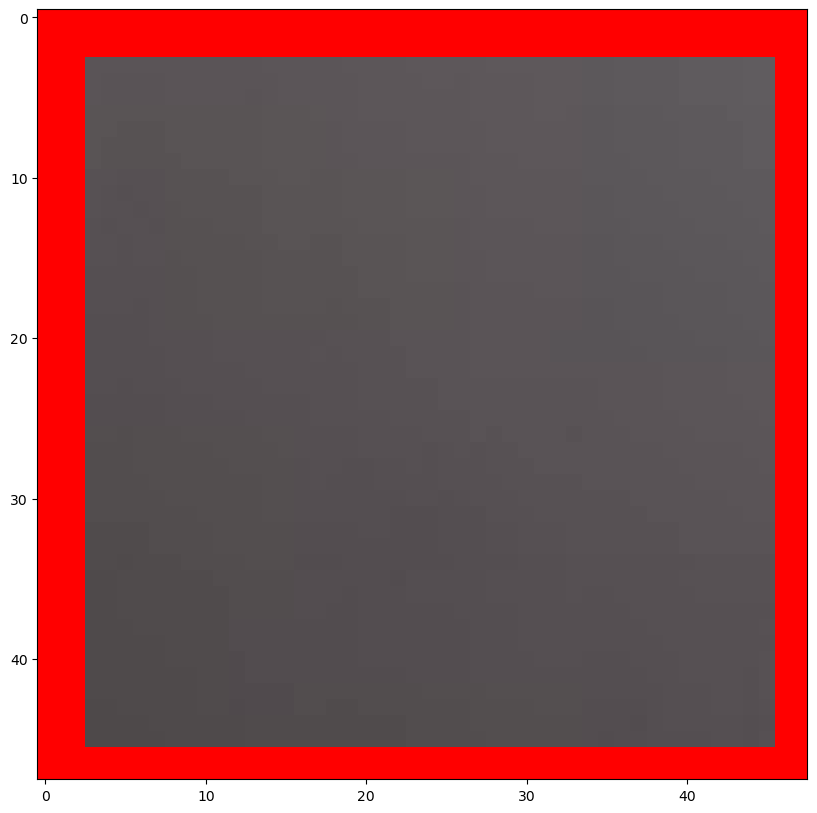




True 1
entered show


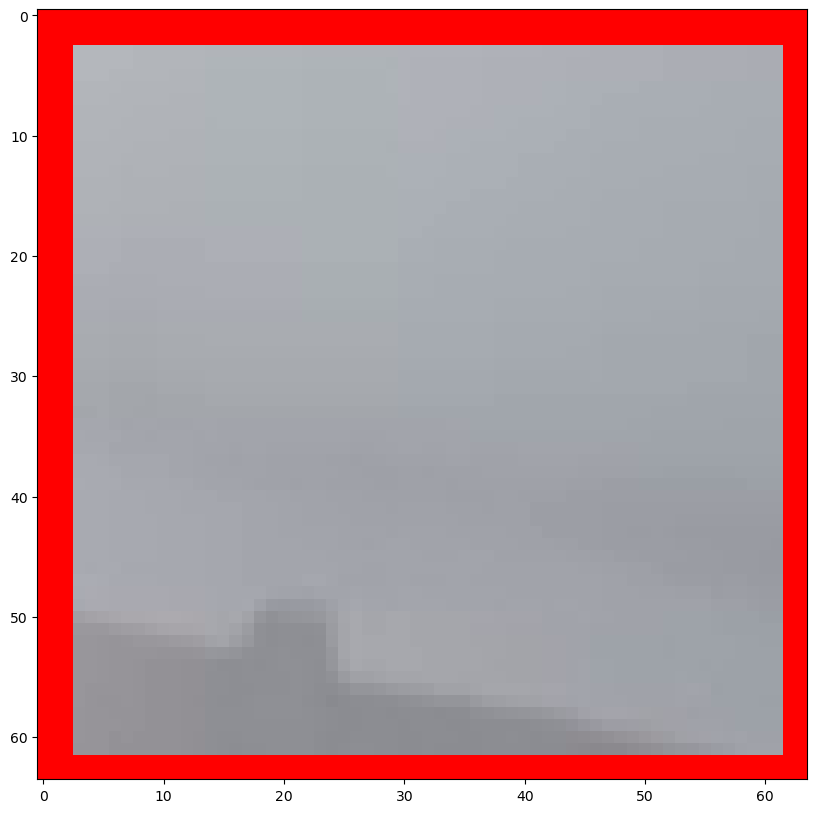




False 1
entered show


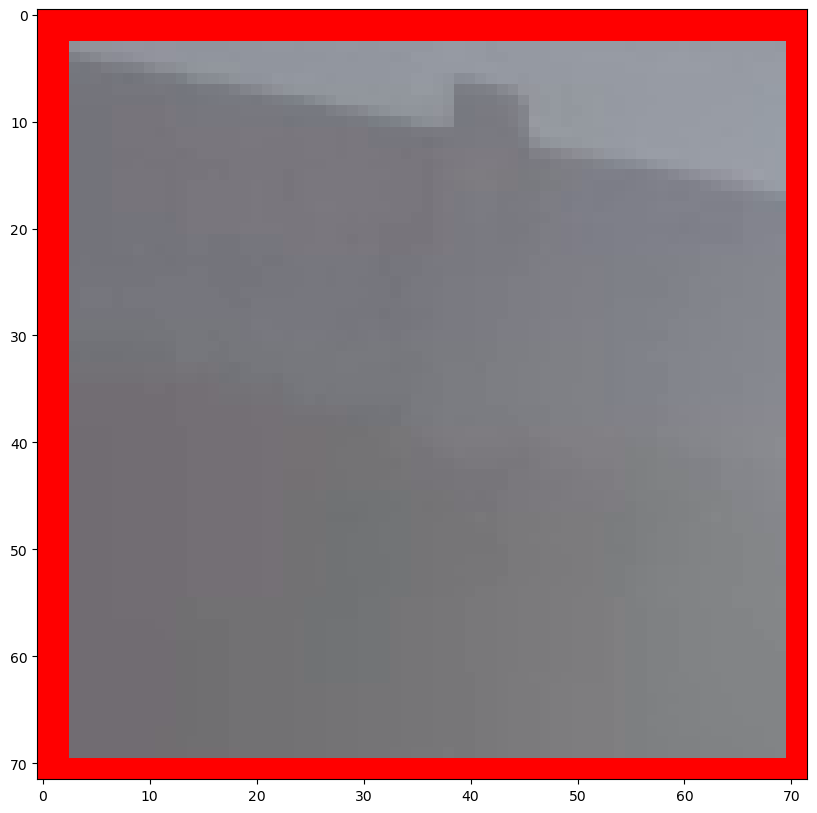




True 1
entered show


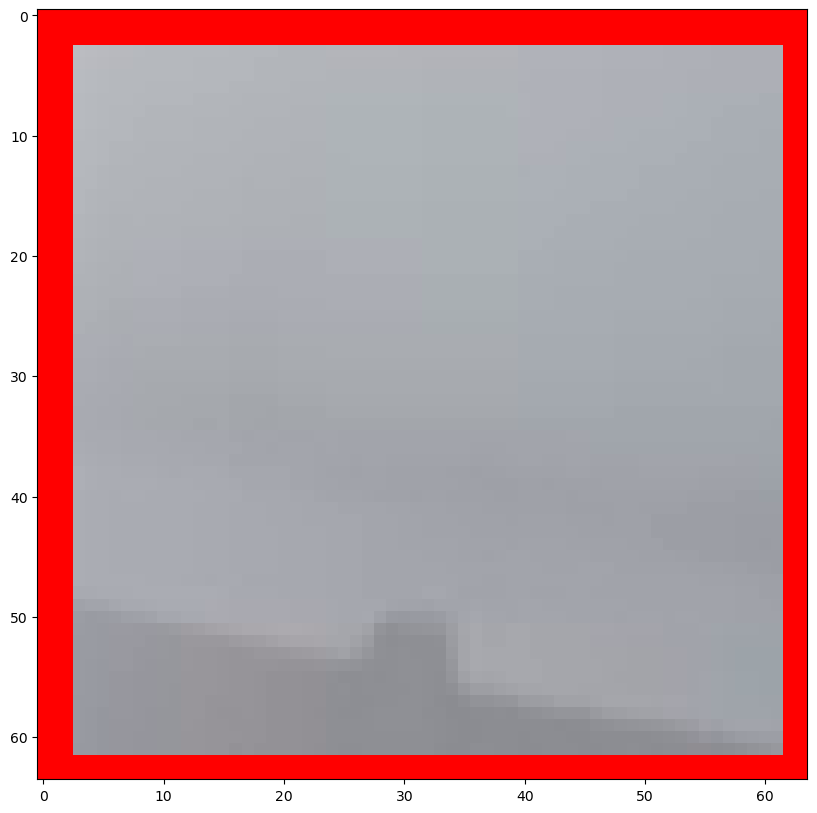

True 2
entered show


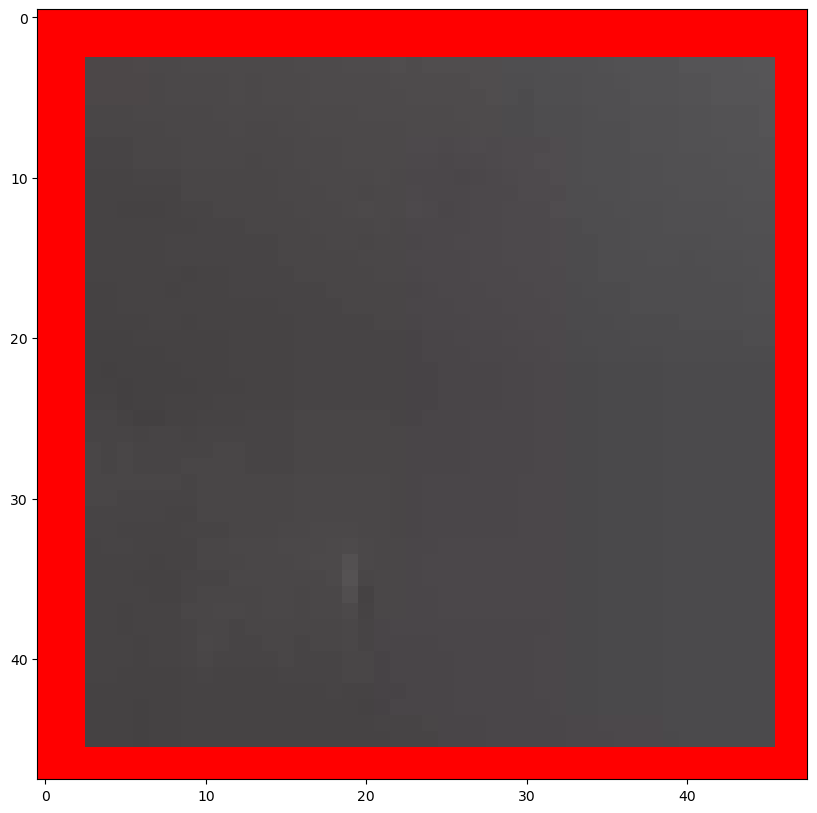




True 1
entered show


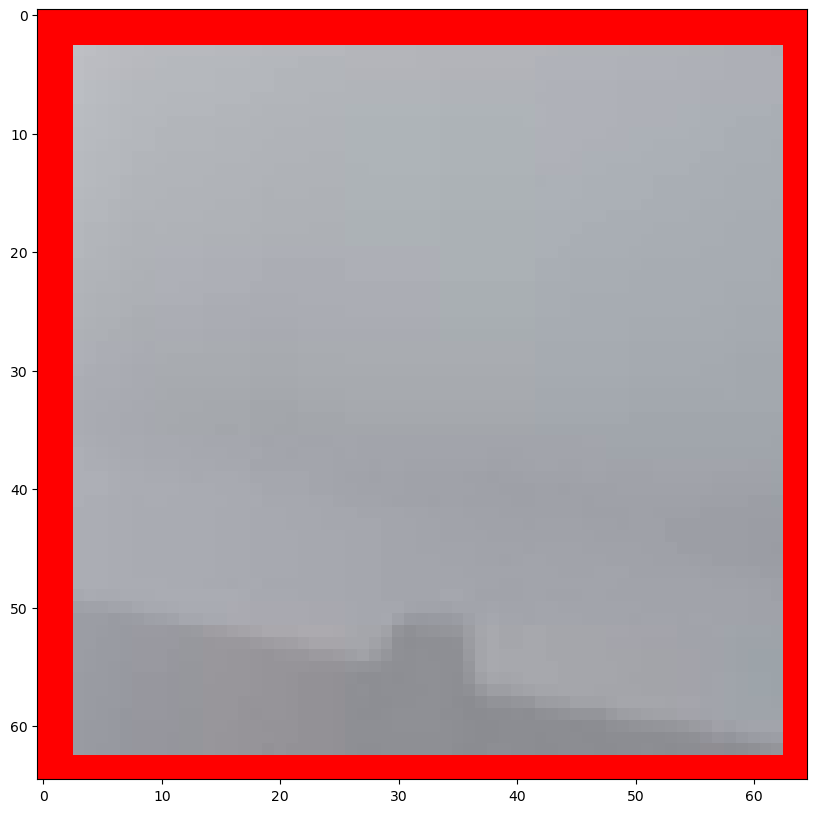




True 1
entered show


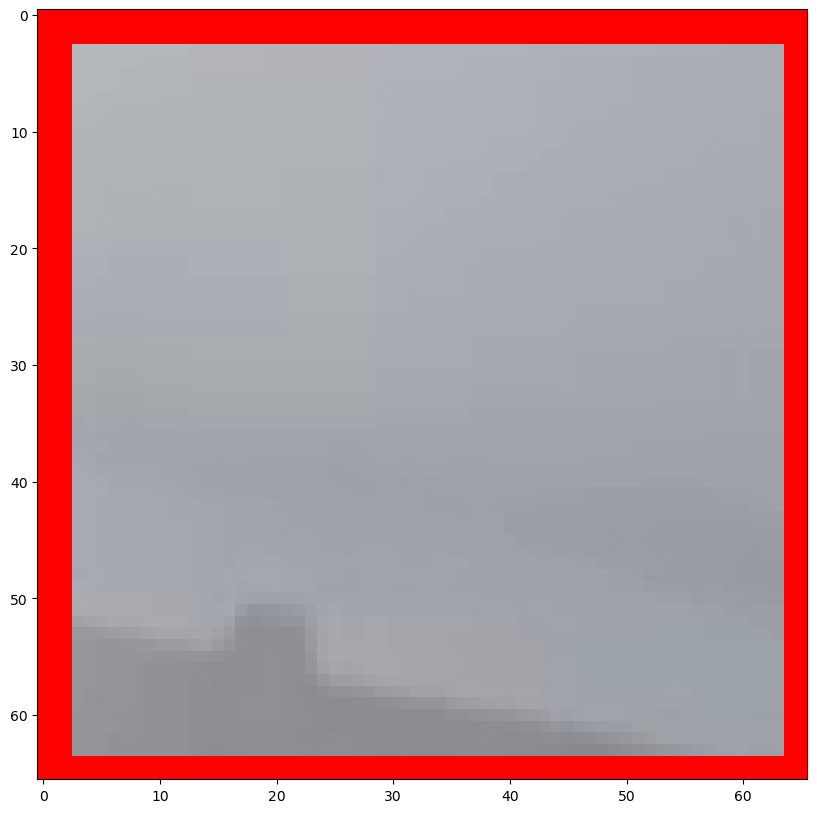

True 2
entered show


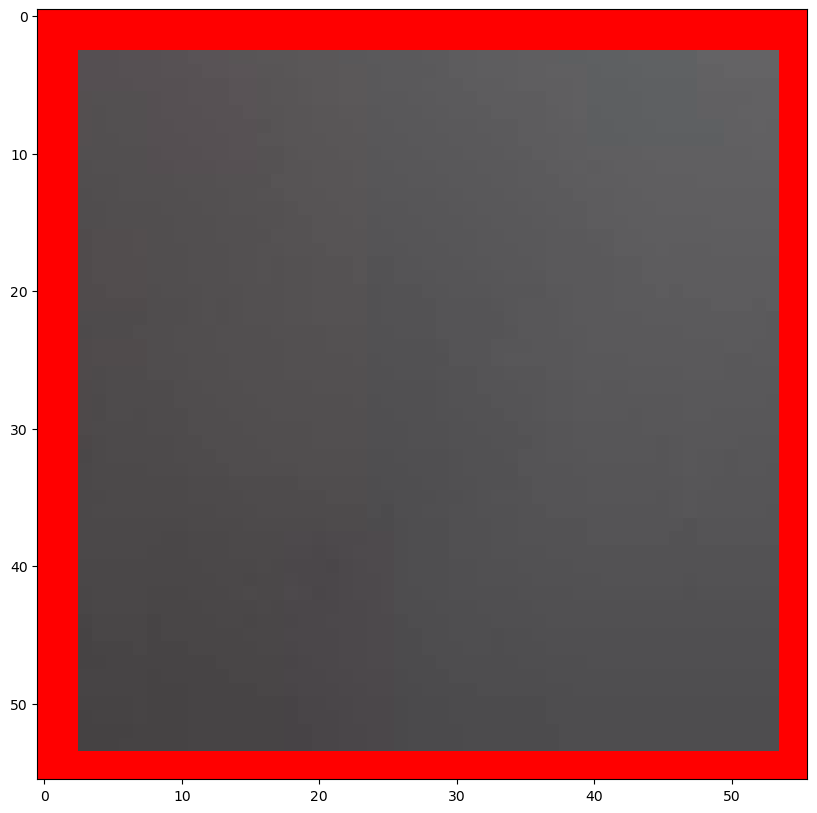




True 1
entered show


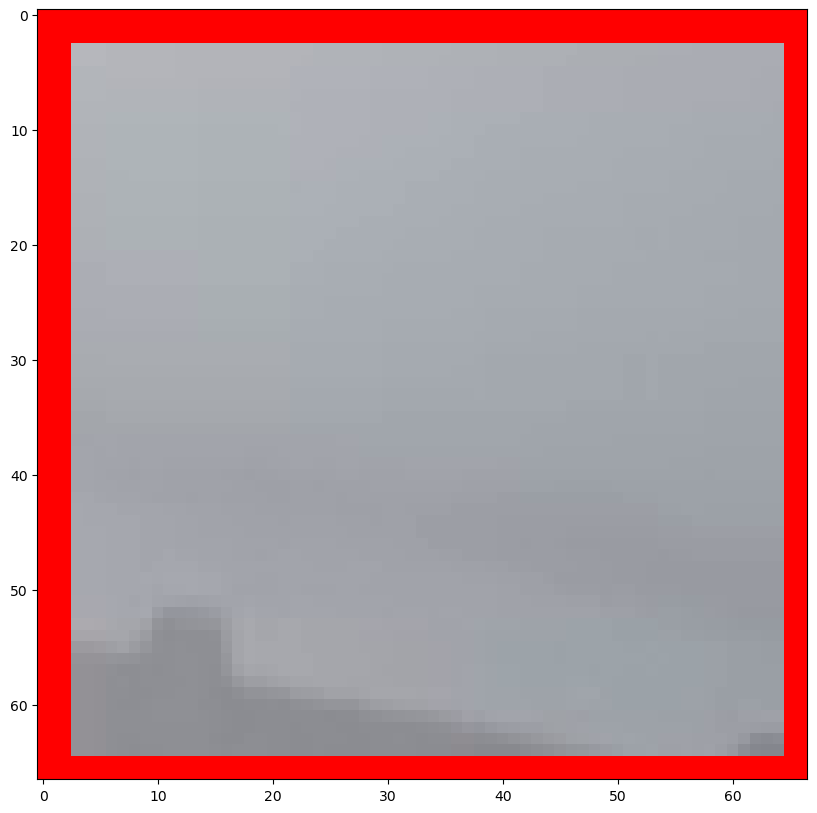

True 2
entered show


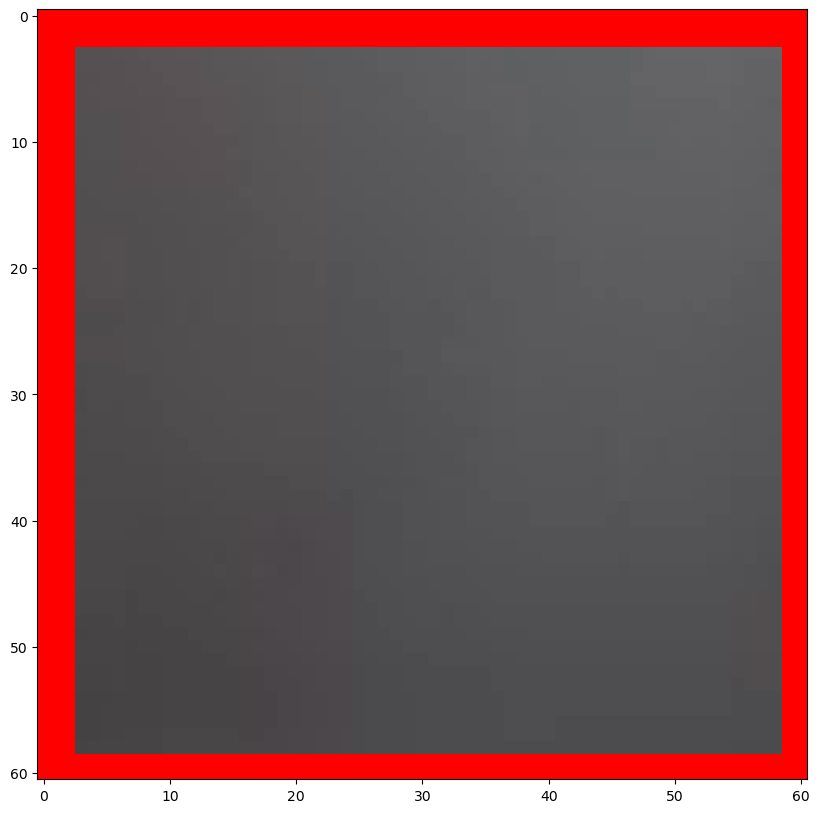




True 1
entered show


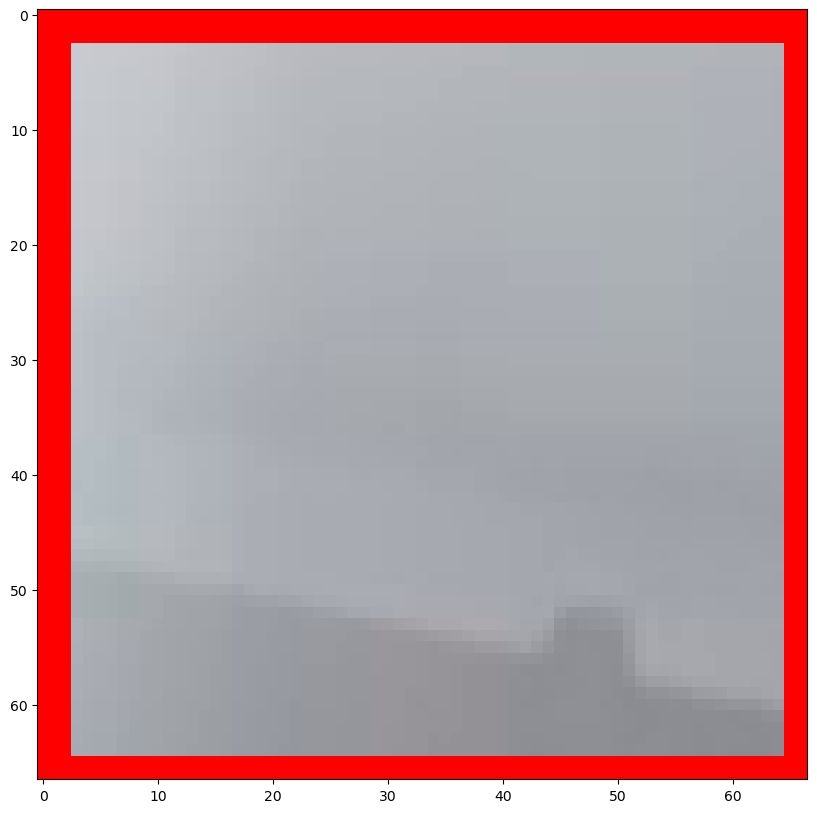




True 1
entered show


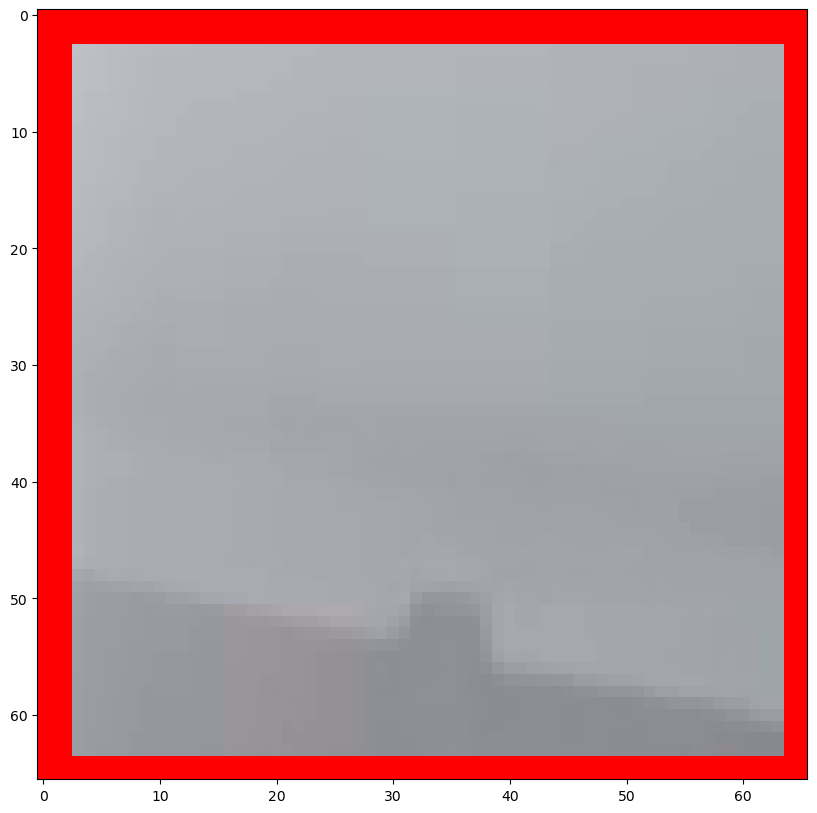




True 1
entered show


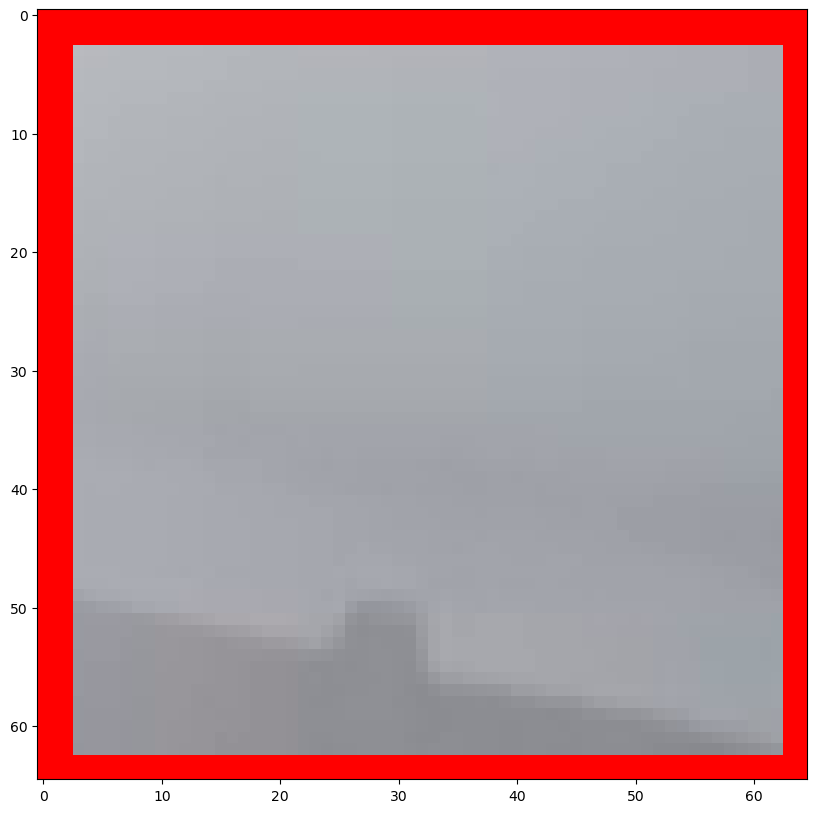




True 1
entered show


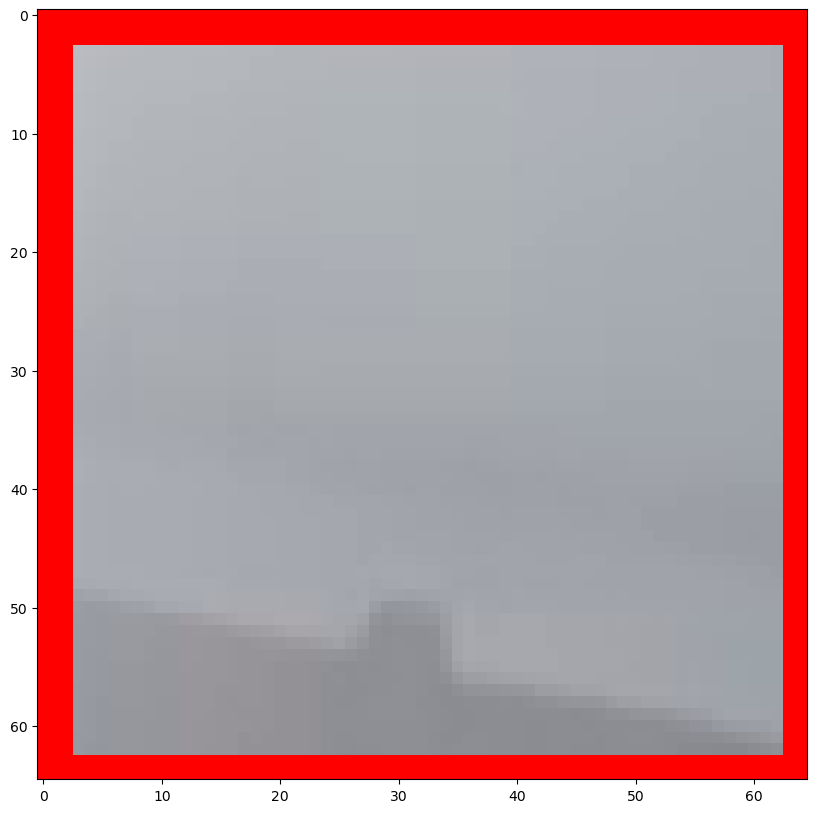




True 1
entered show


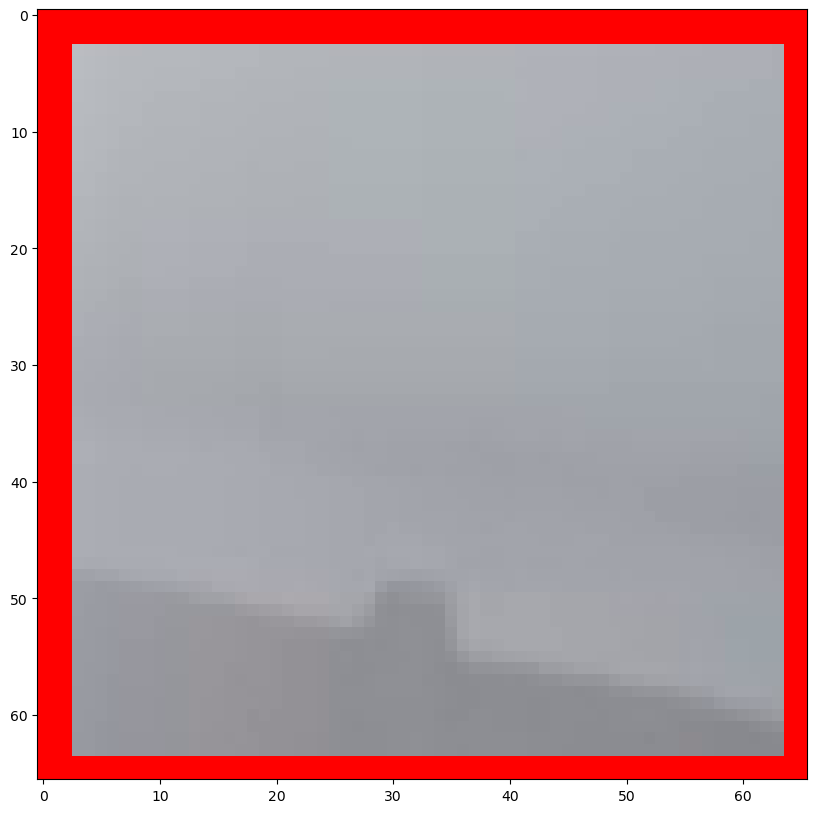




True 1
entered show


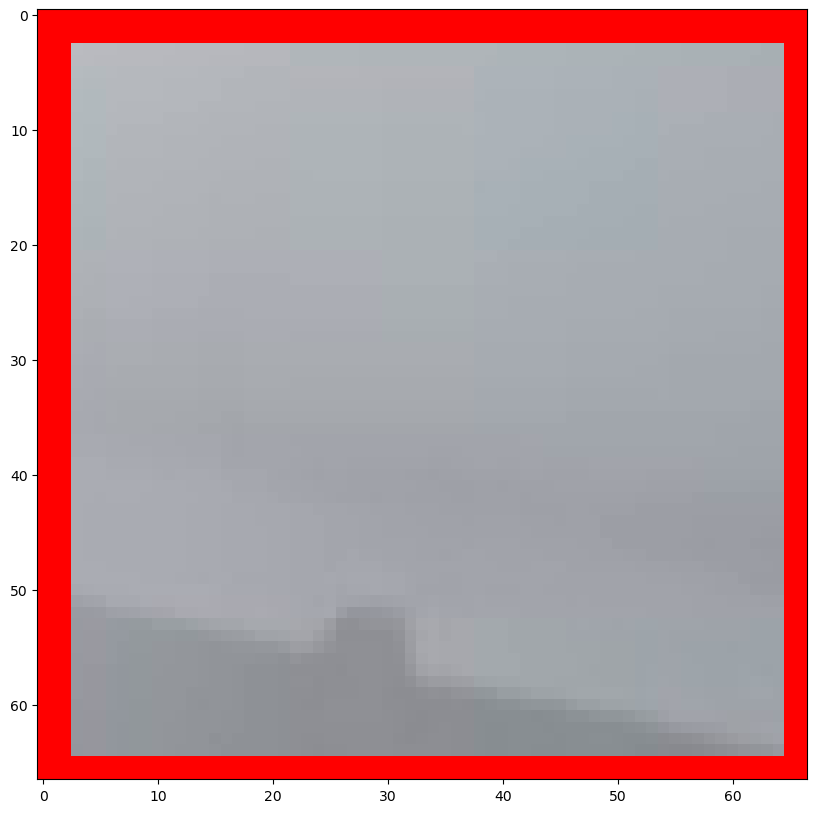




True 1
entered show


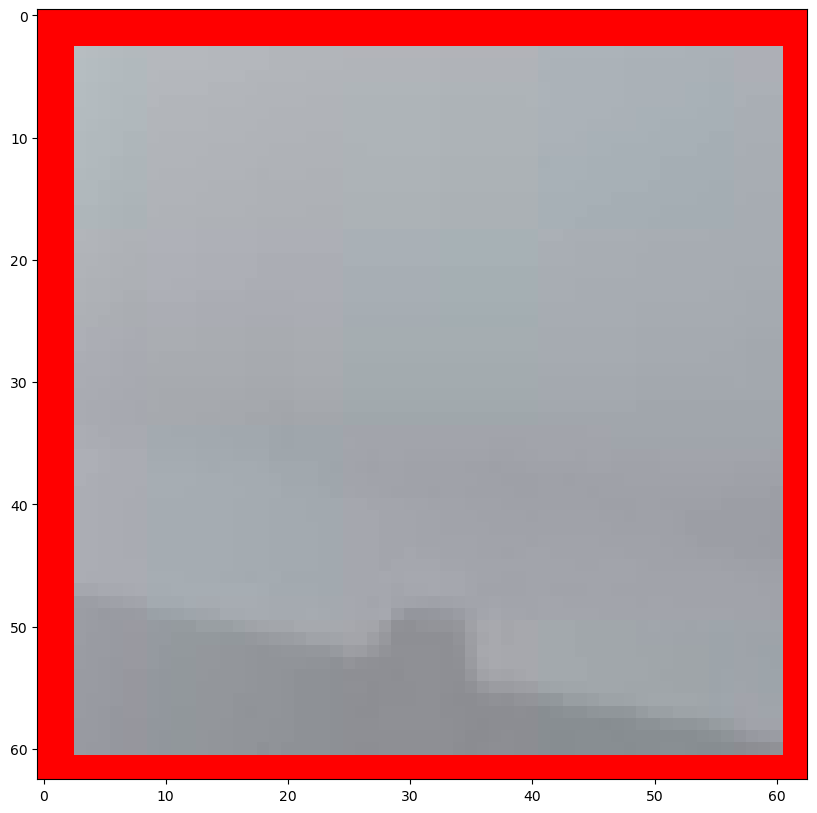




True 1
entered show


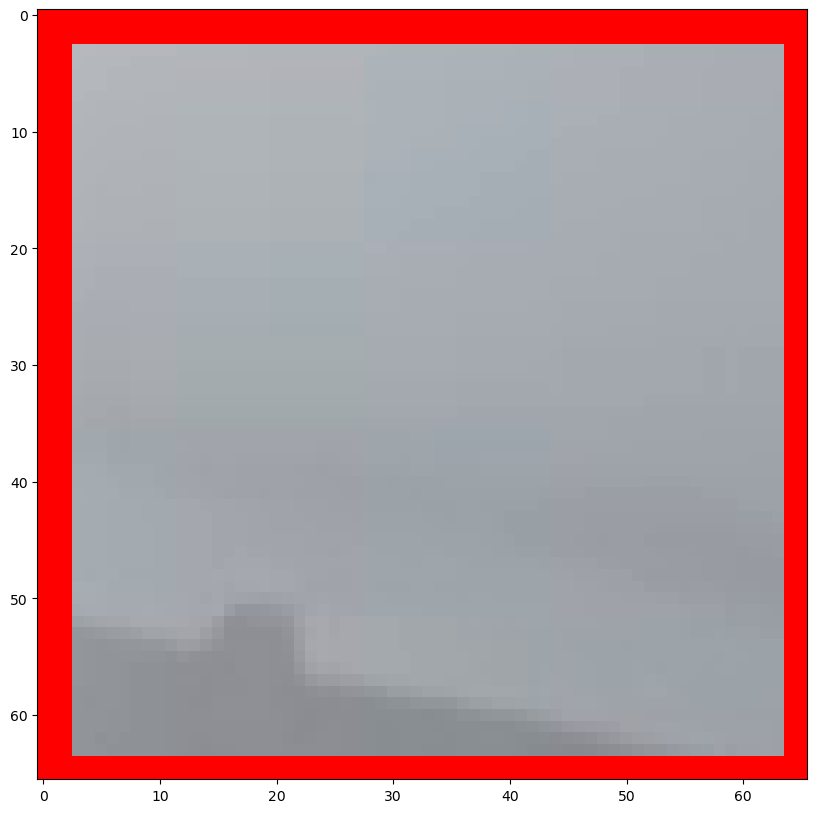




True 1
entered show


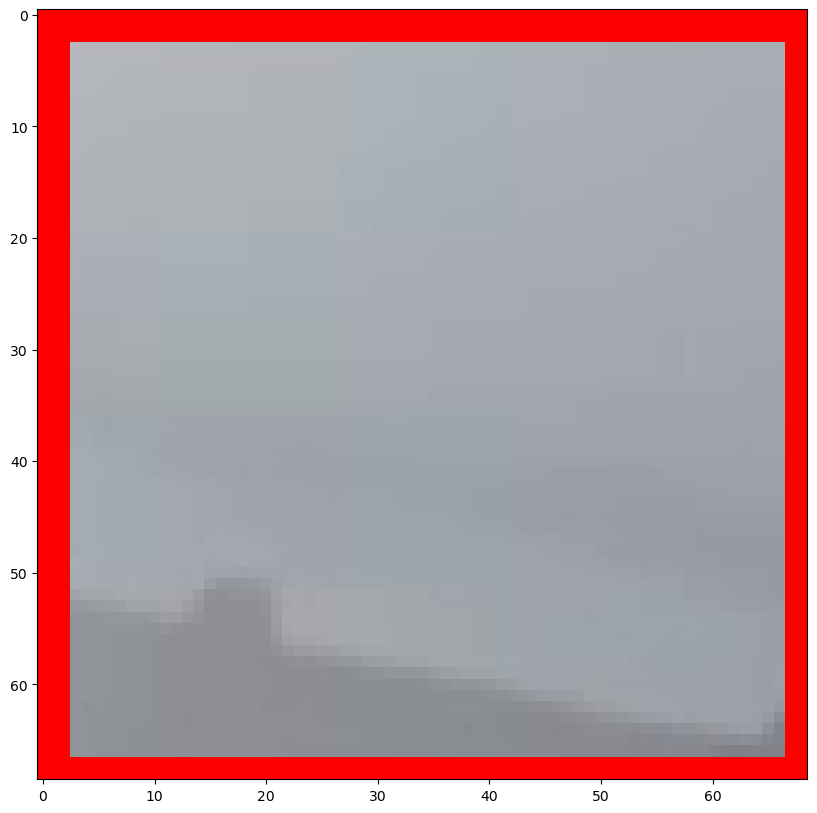

True 2
entered show


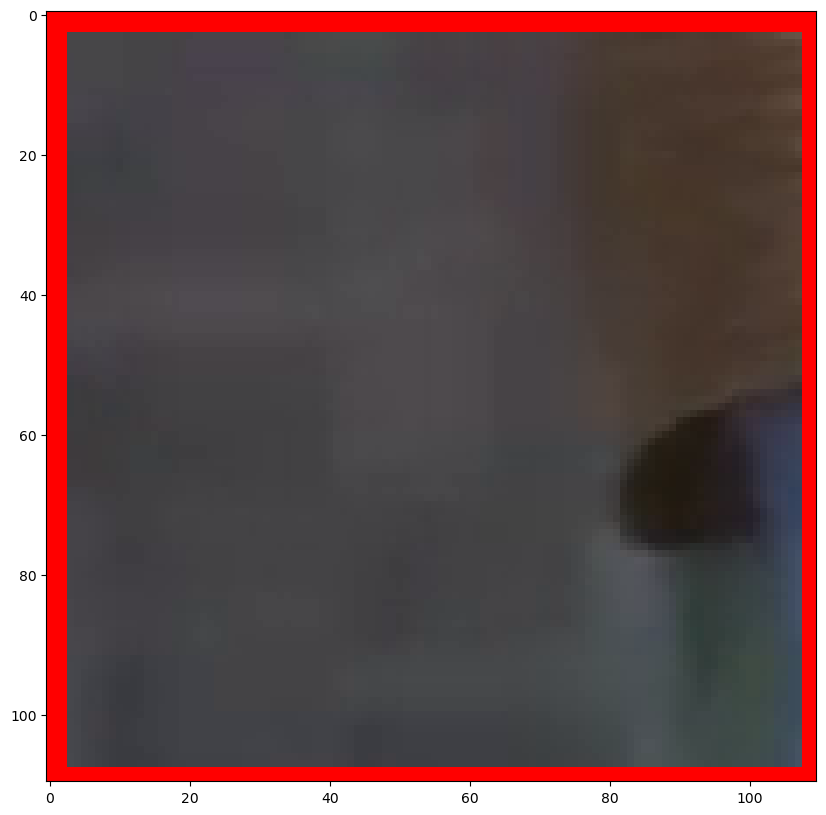




True 1
entered show


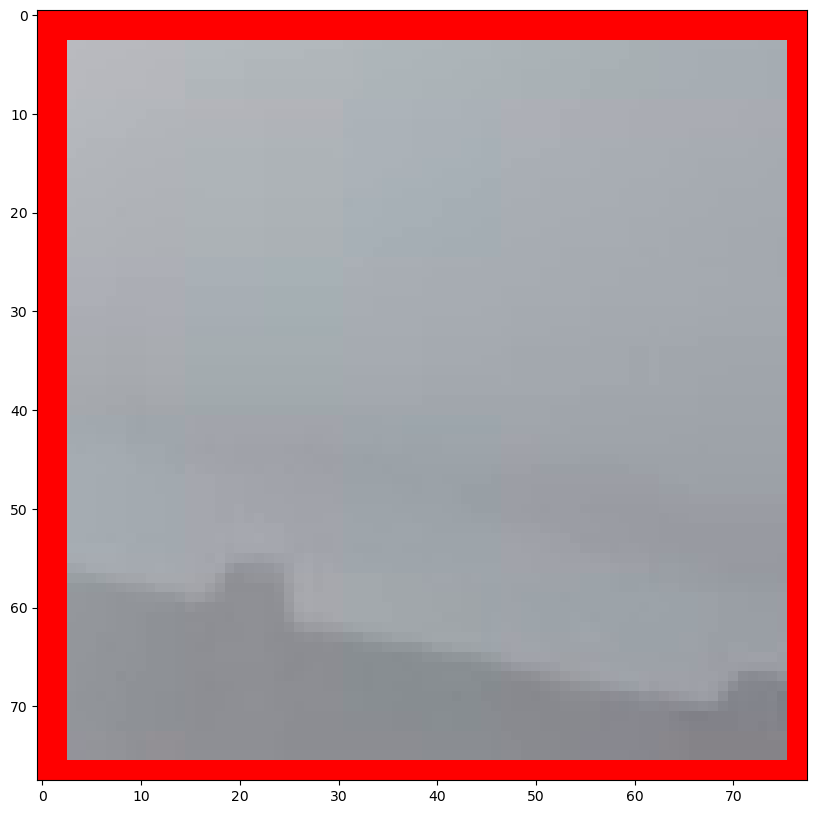

True 2
entered show


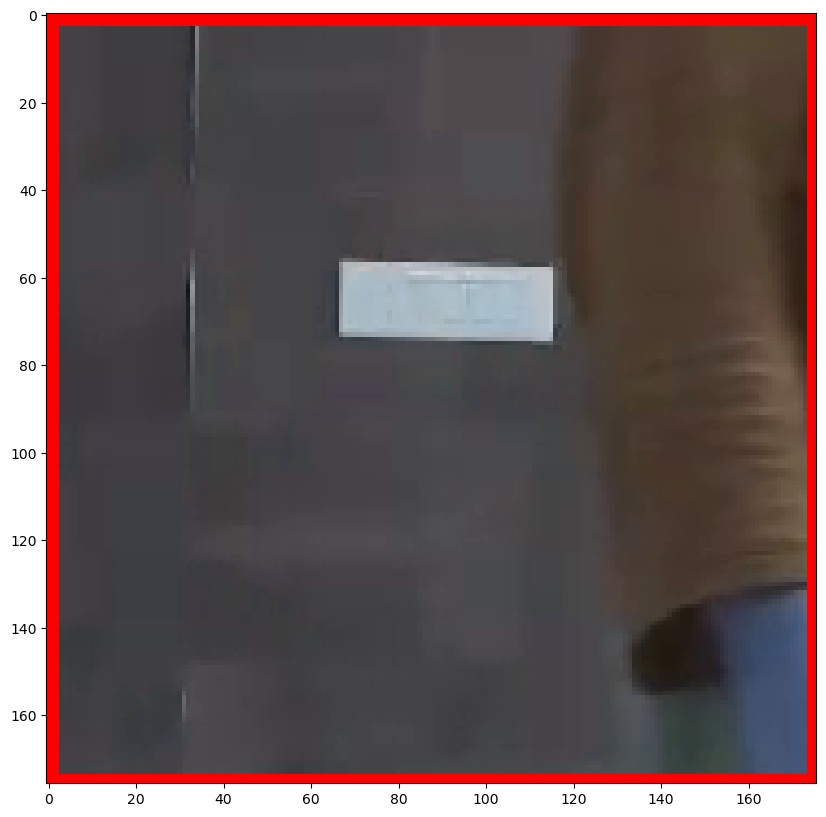




True 1
entered show


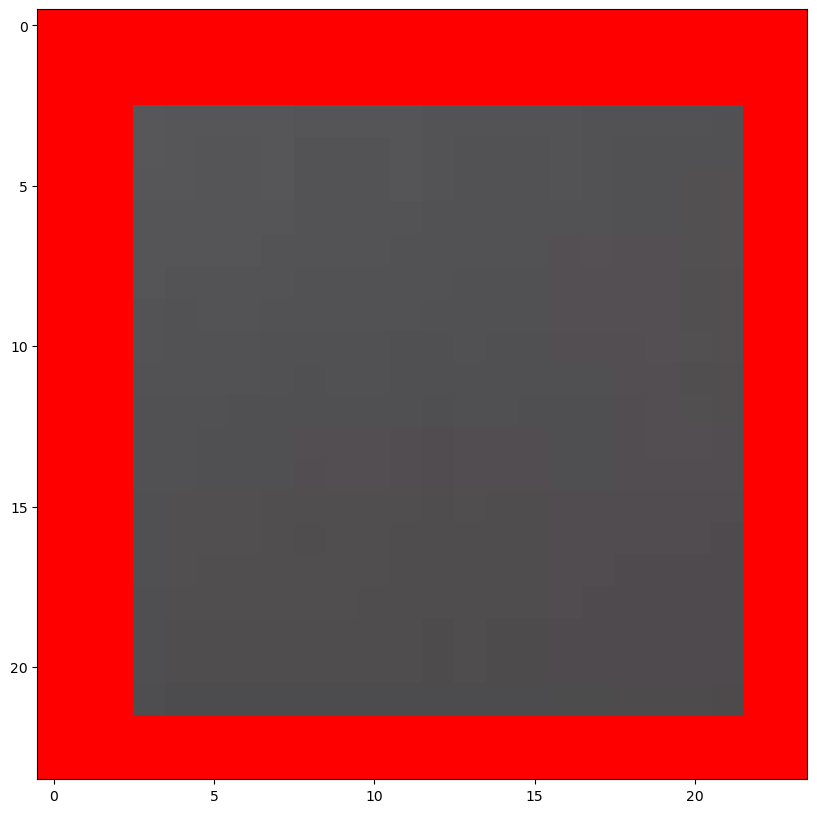

True 2
entered show


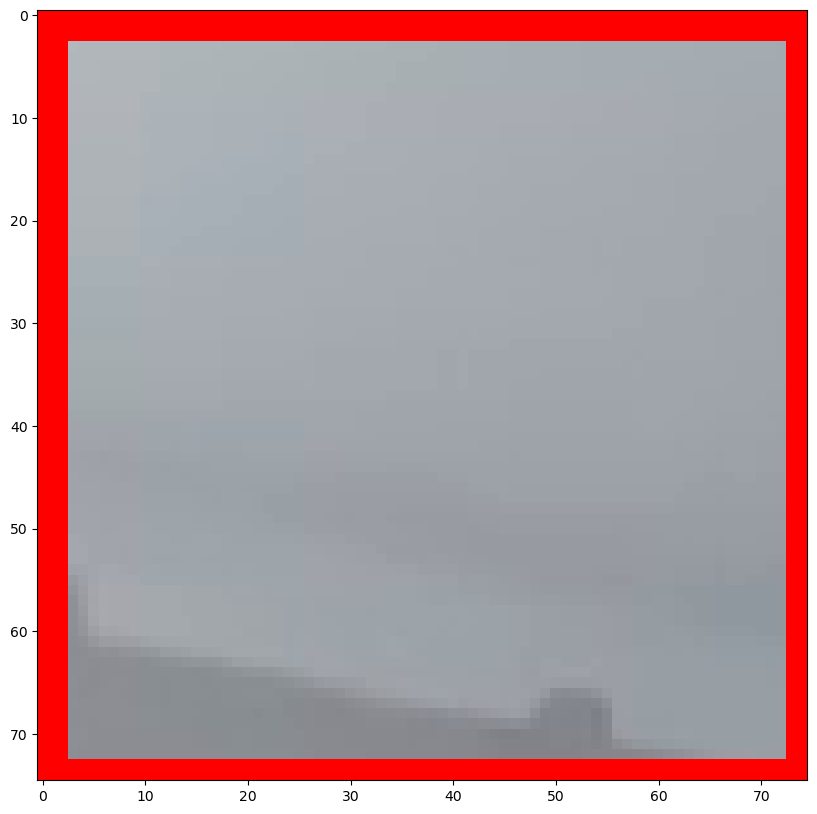

True 3
entered show


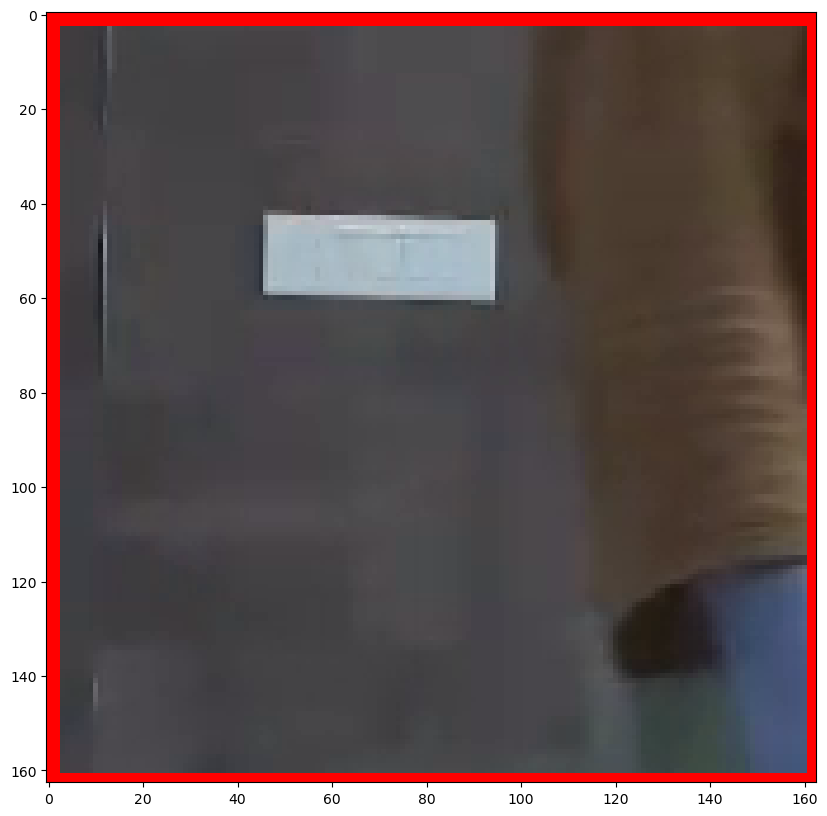




True 1
entered show


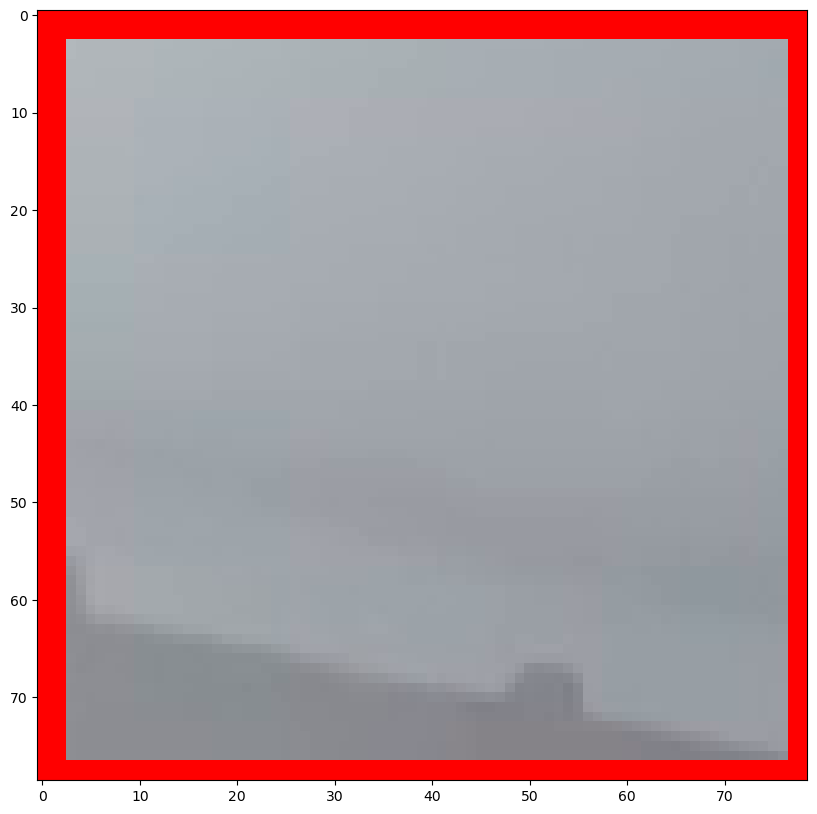




True 1
entered show


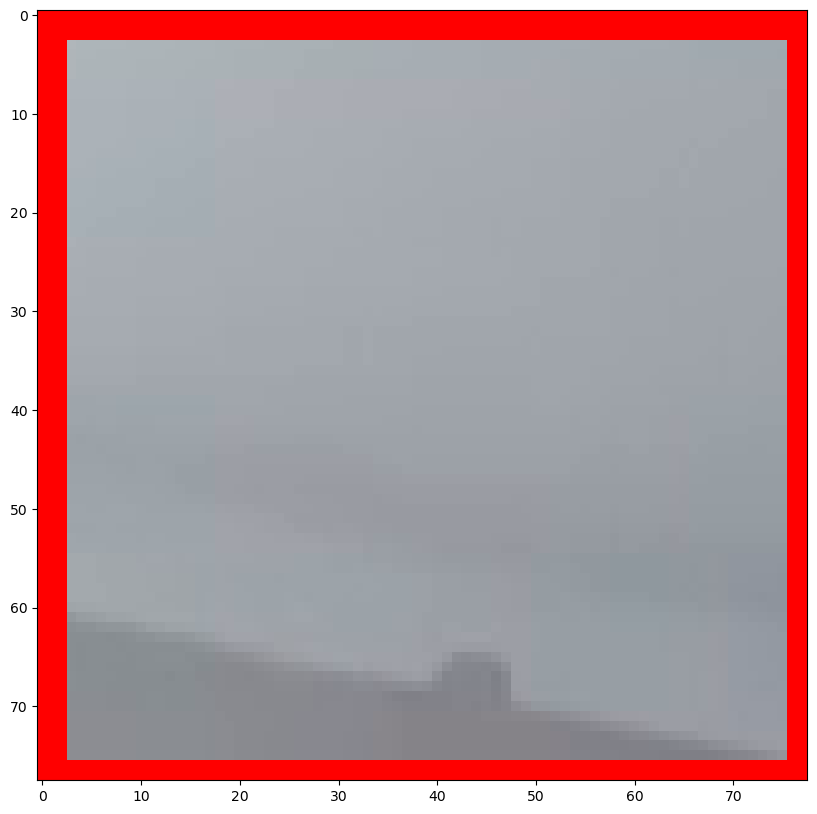




True 1
entered show


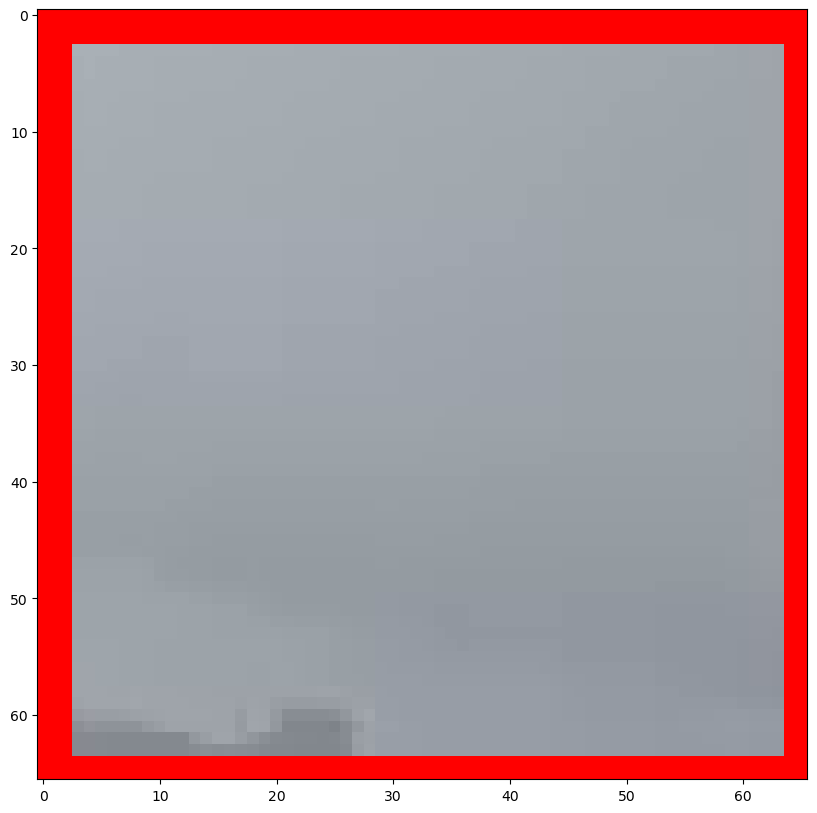




True 1
entered show


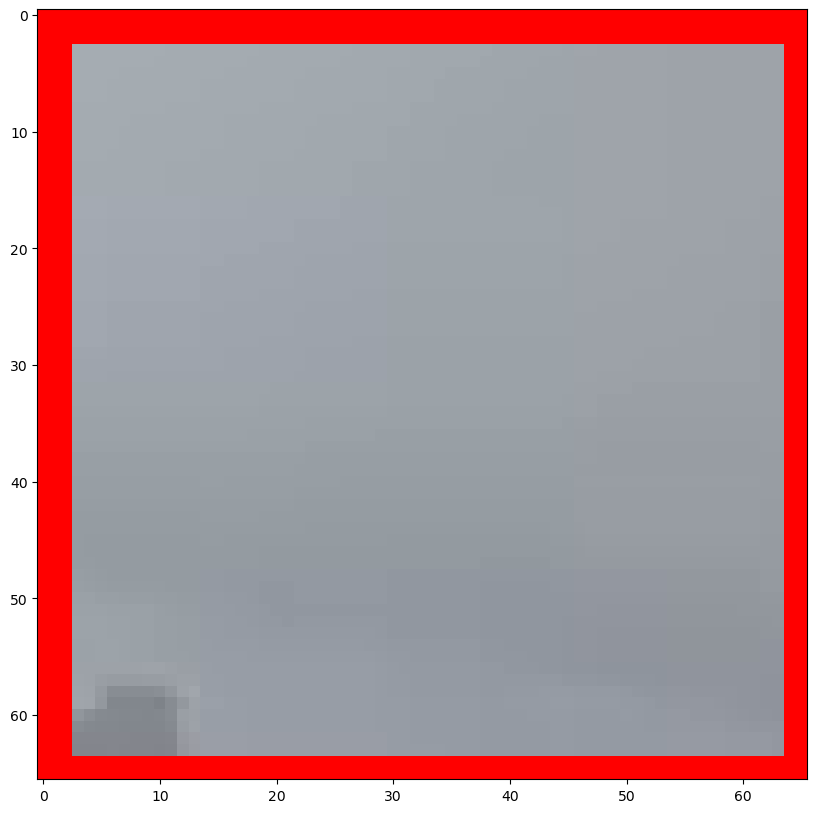




True 1
entered show


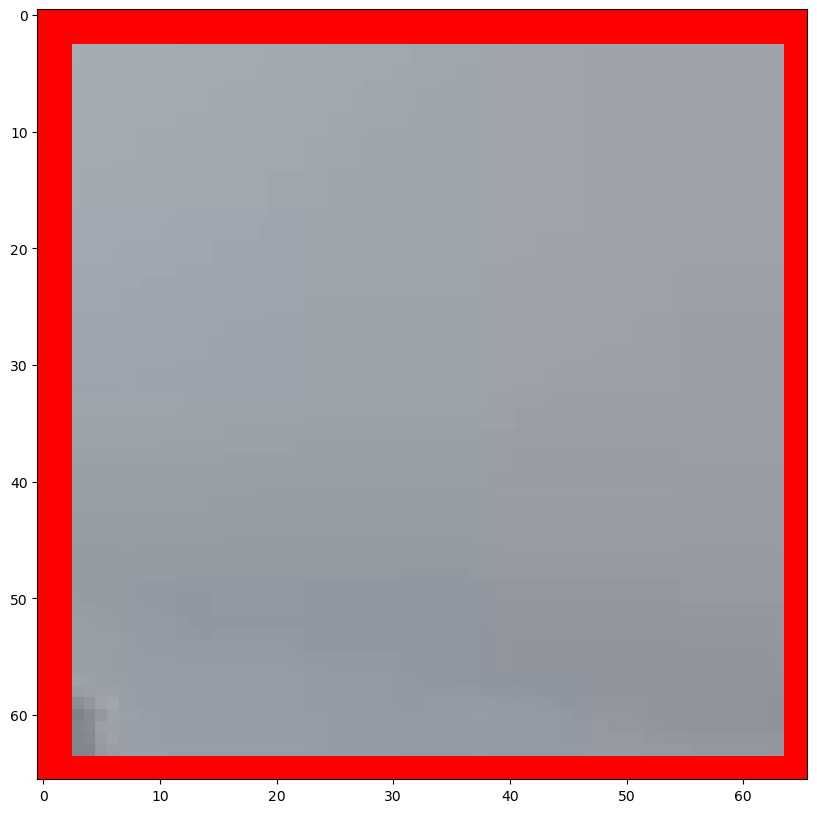




True 1
entered show


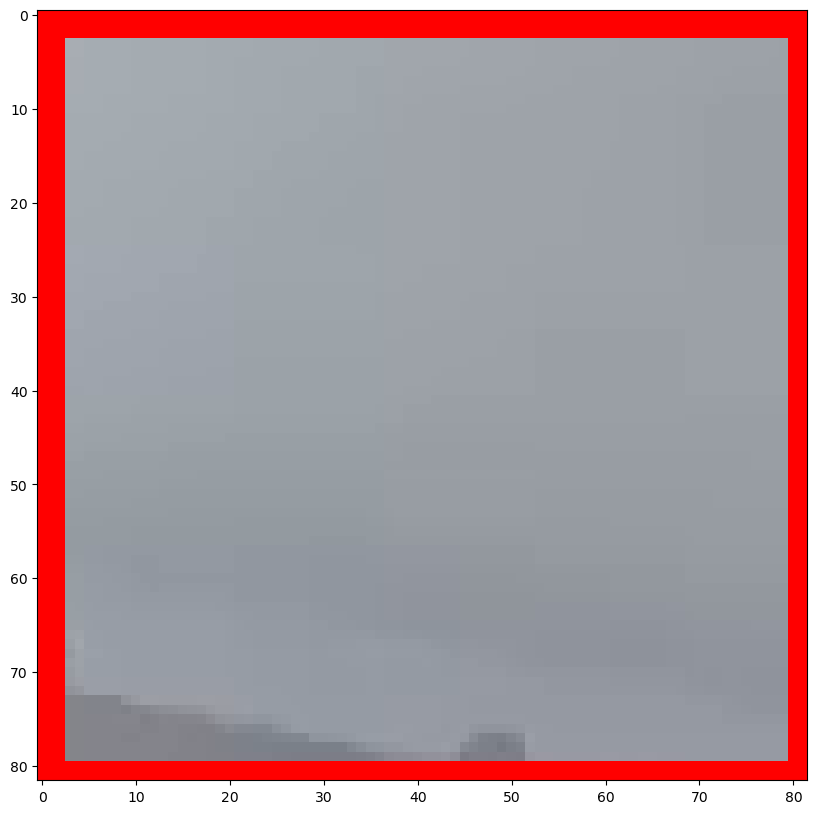




True 1
entered show


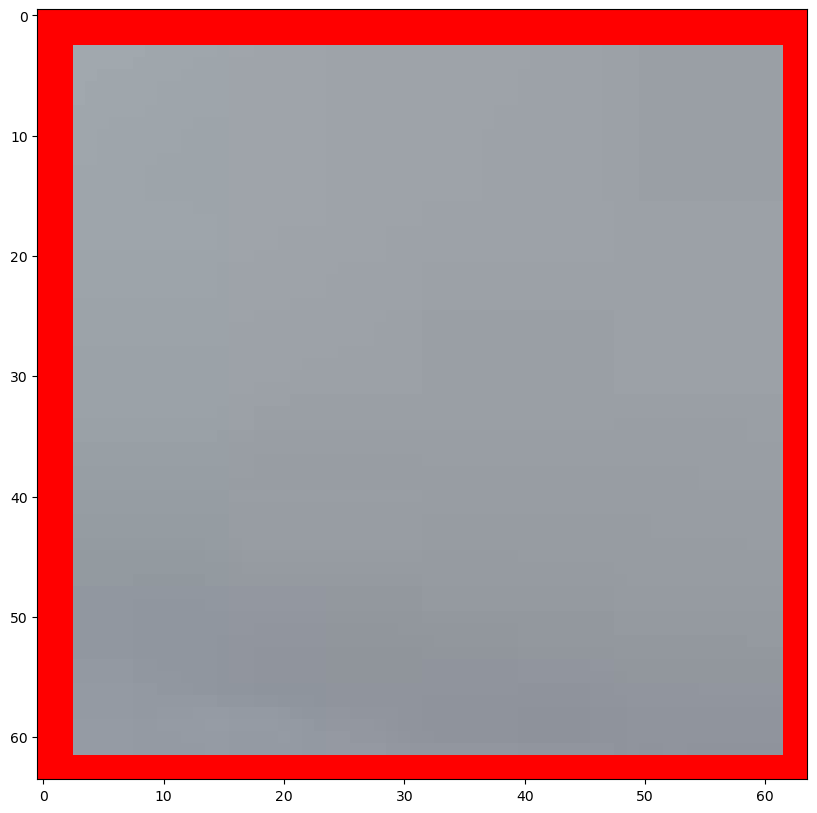




True 1
entered show


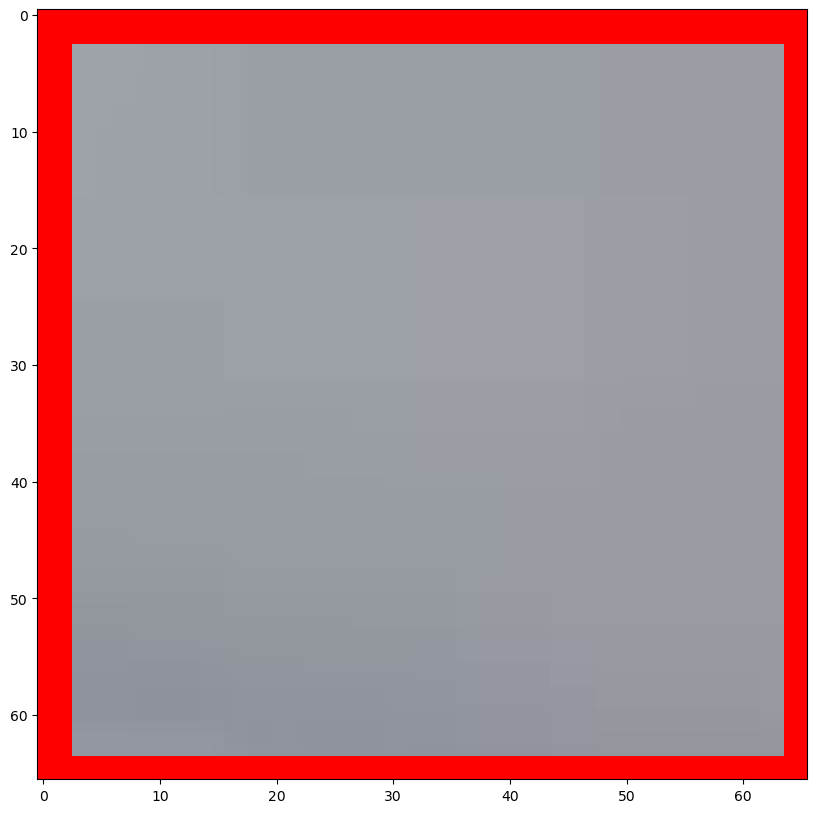




True 1
entered show


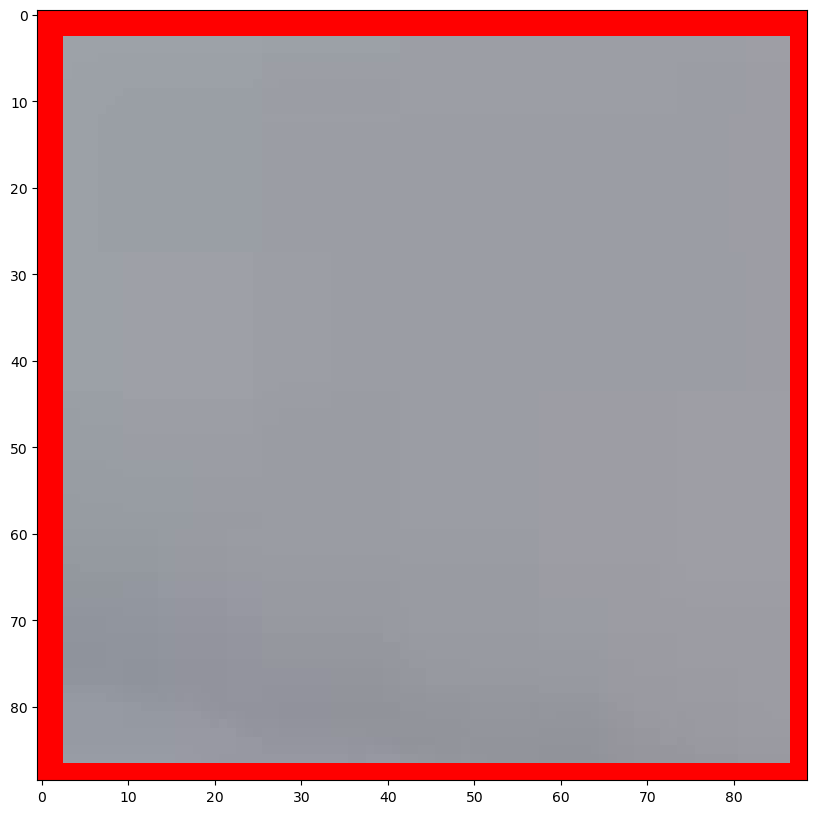

True 2
entered show


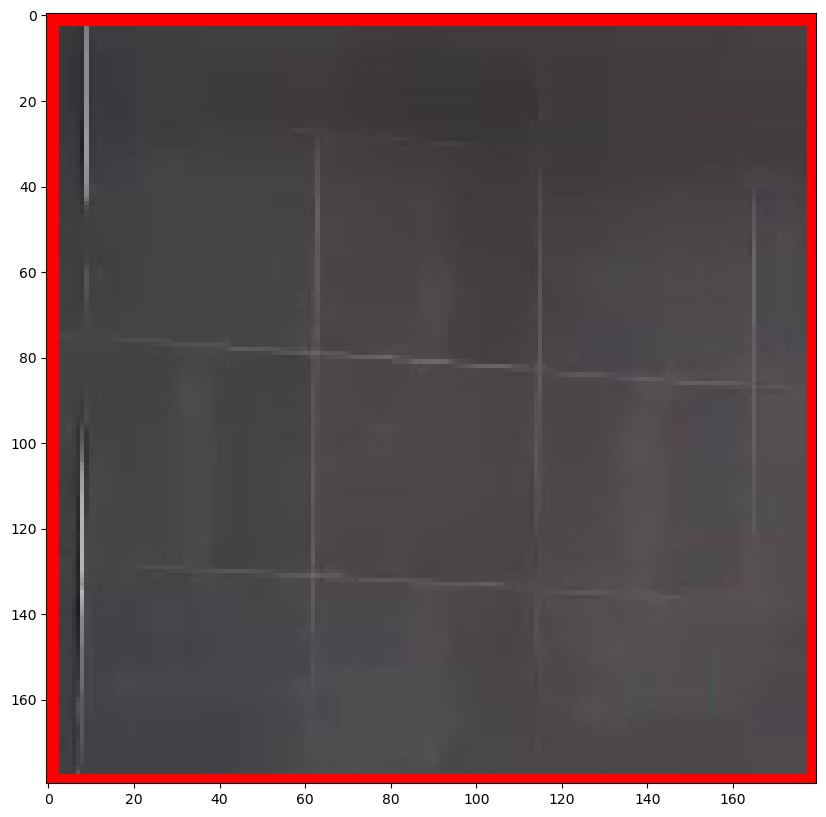




True 1
entered show


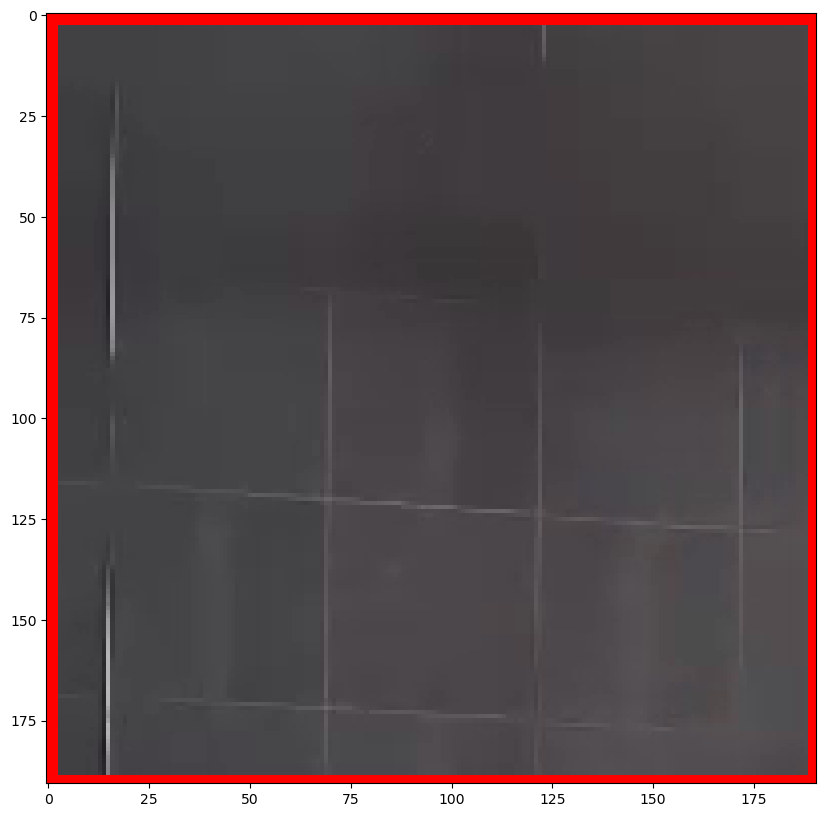




True 1
entered show


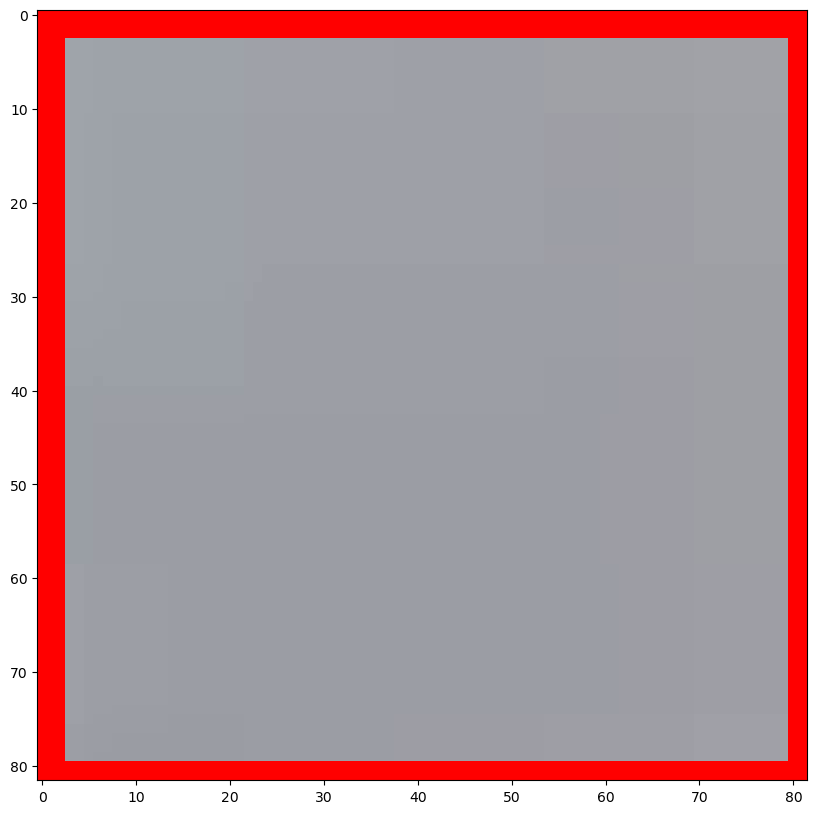




True 1
entered show


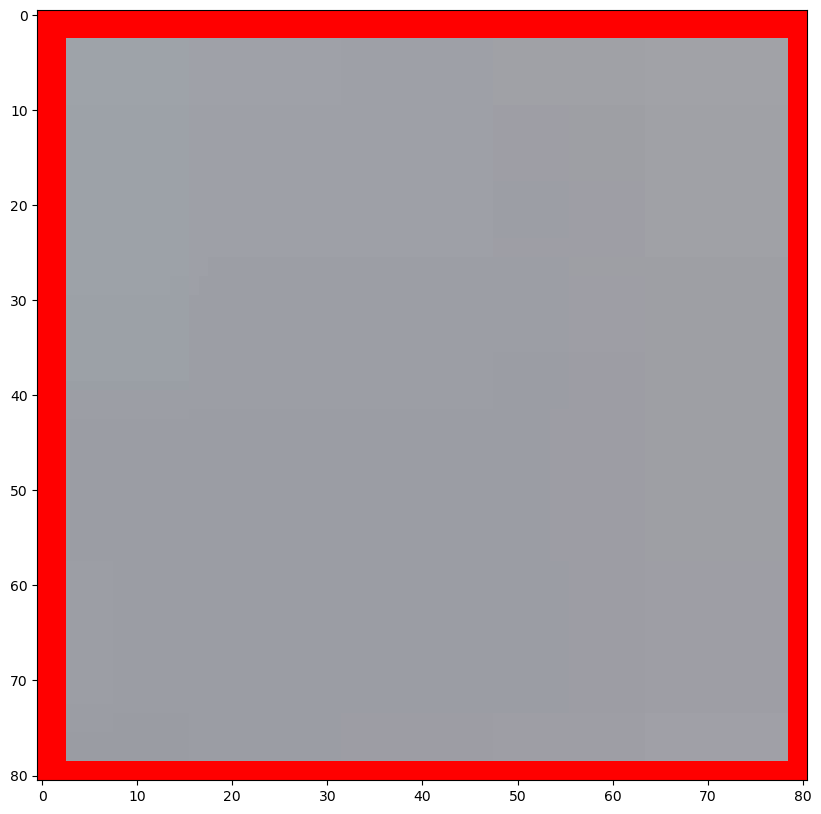




True 1
entered show


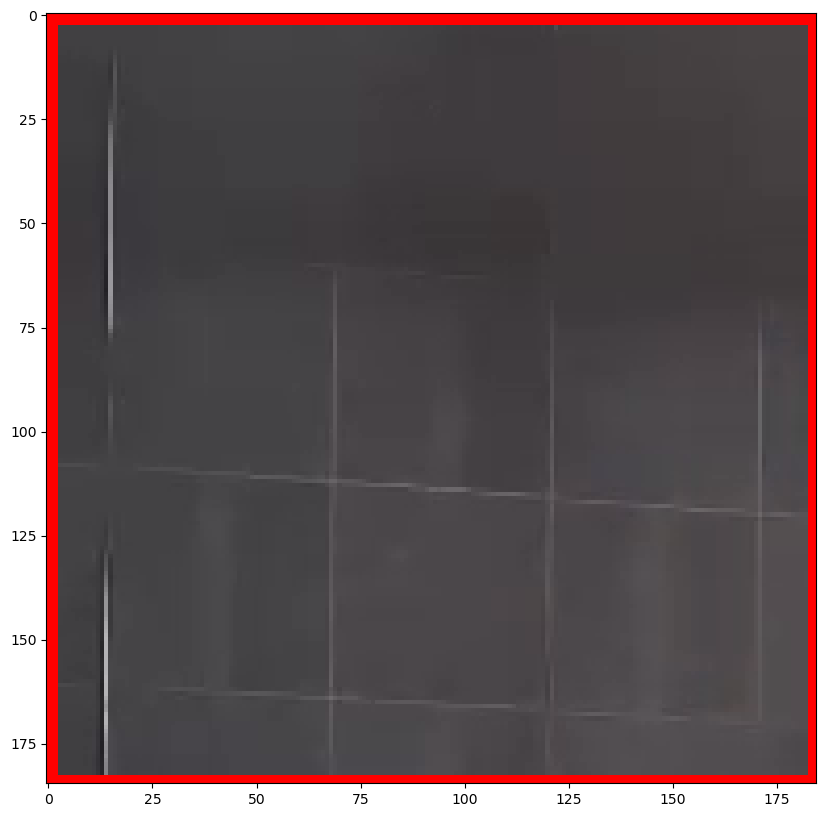




False 1
entered show


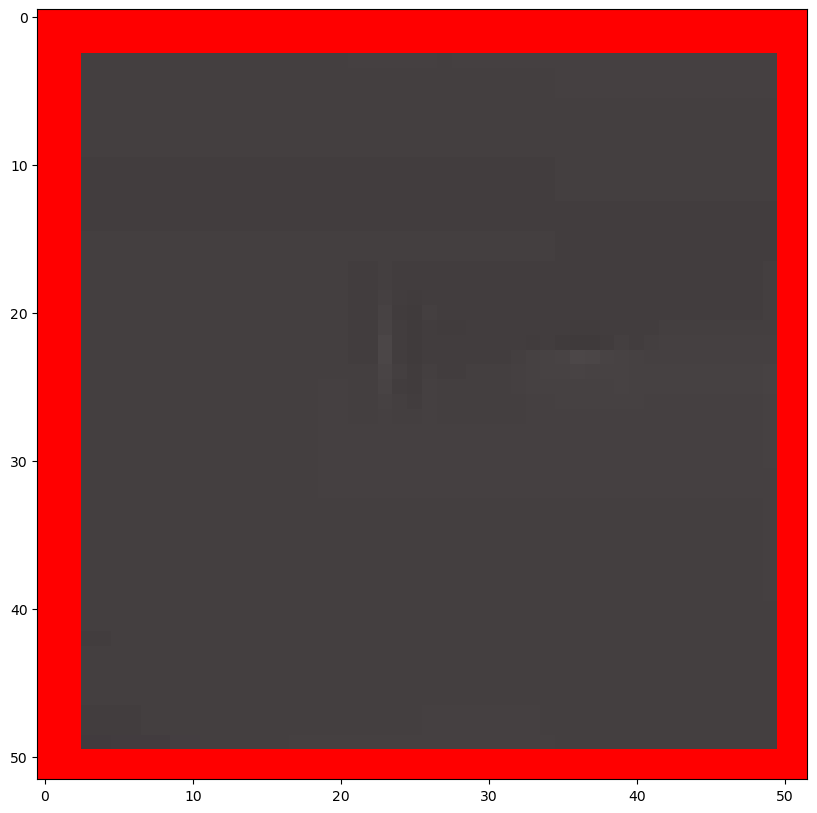




True 1
entered show


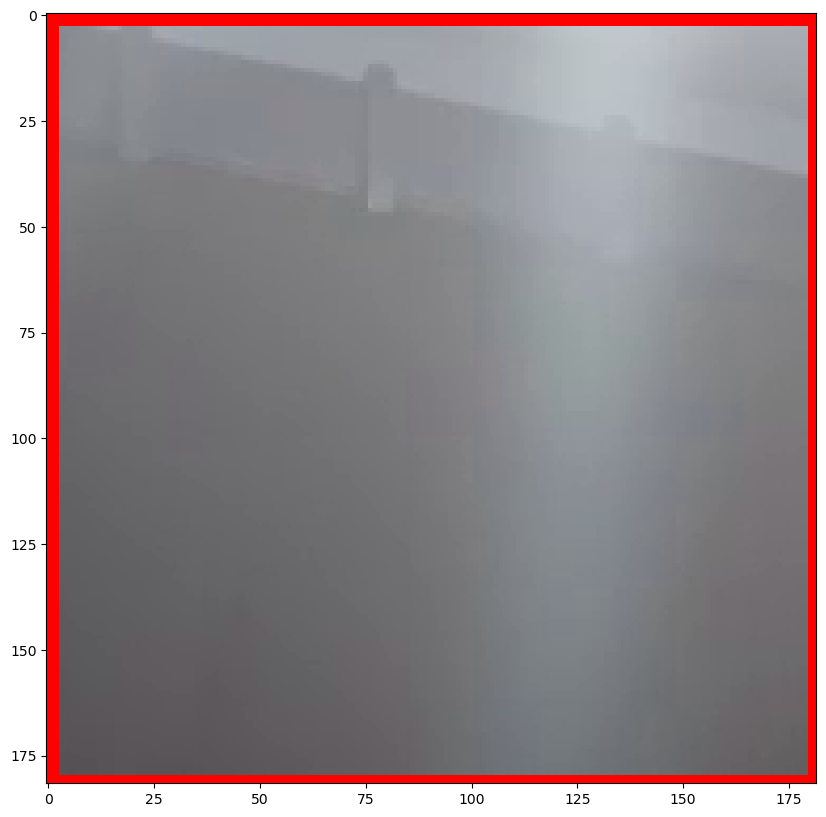




True 1
entered show


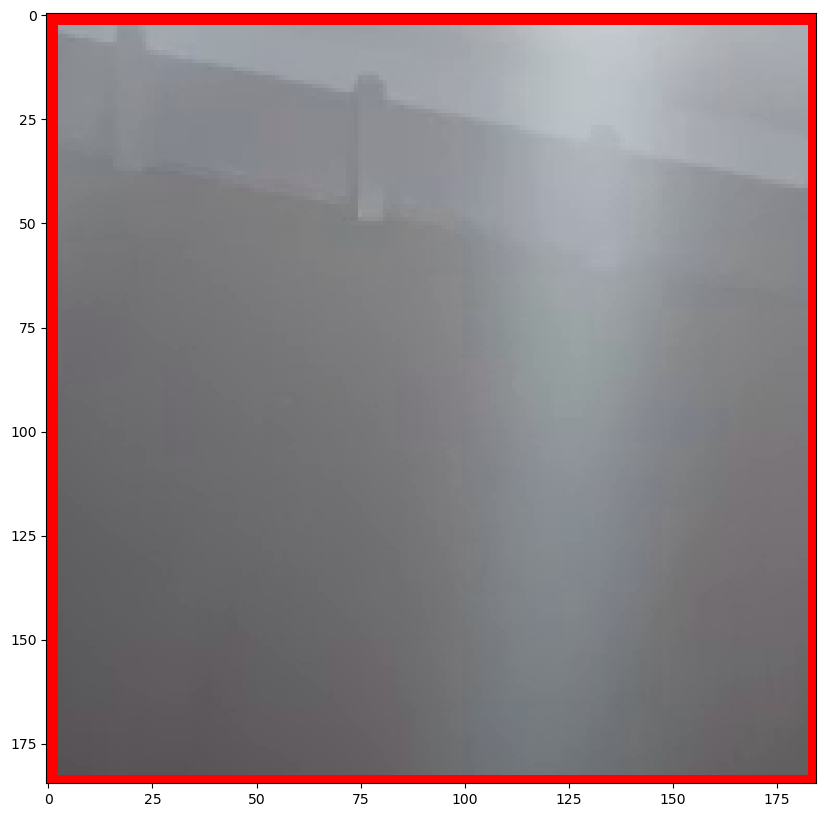




True 1
entered show


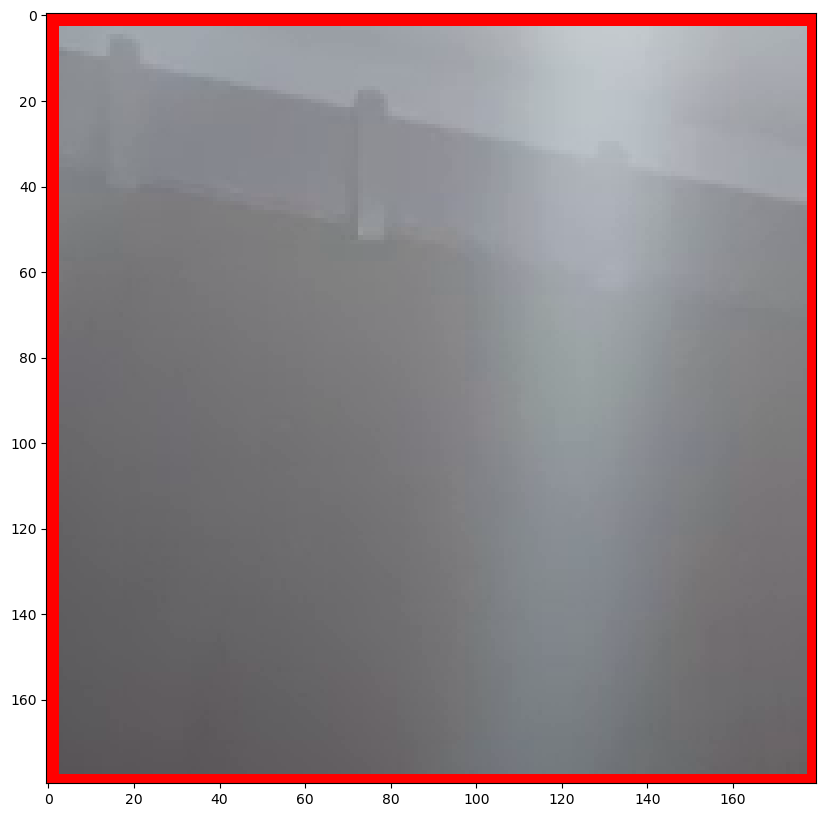




True 1
entered show


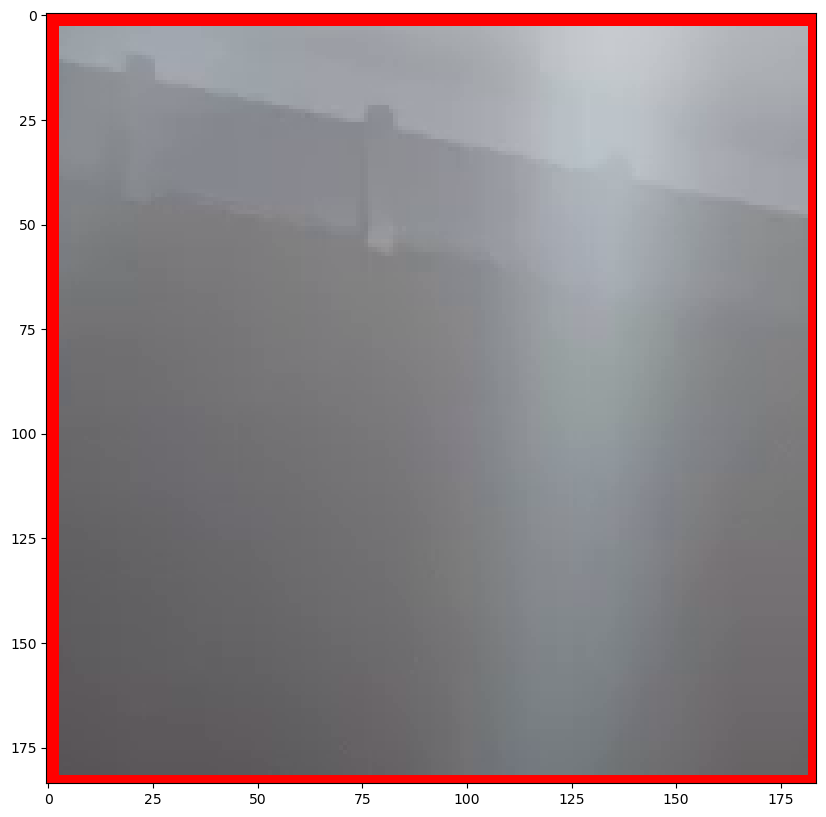




True 1
entered show


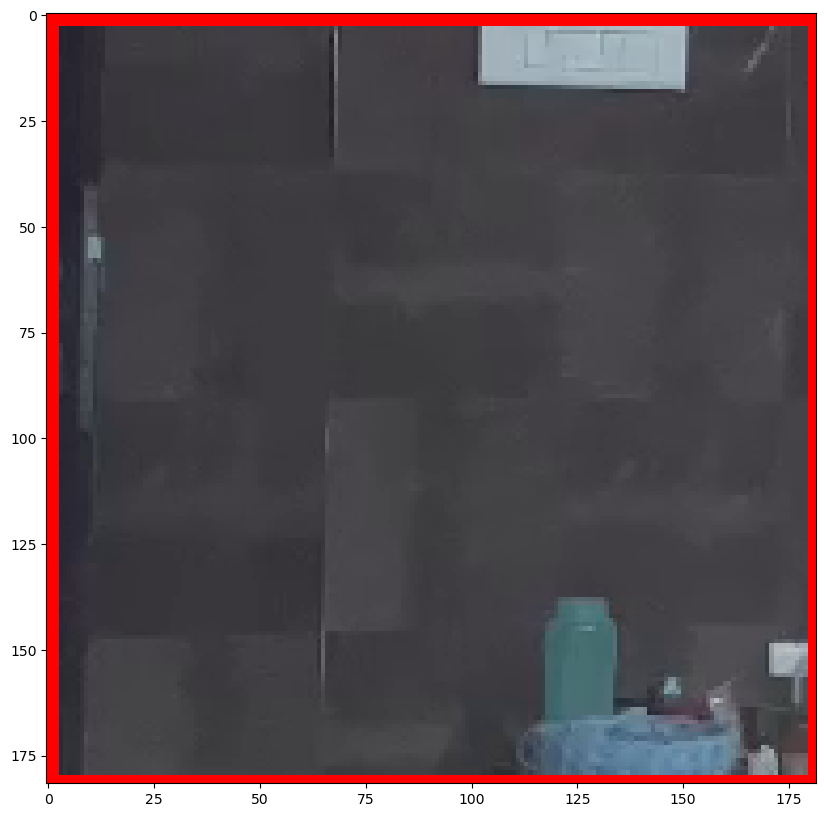




False 1
entered show


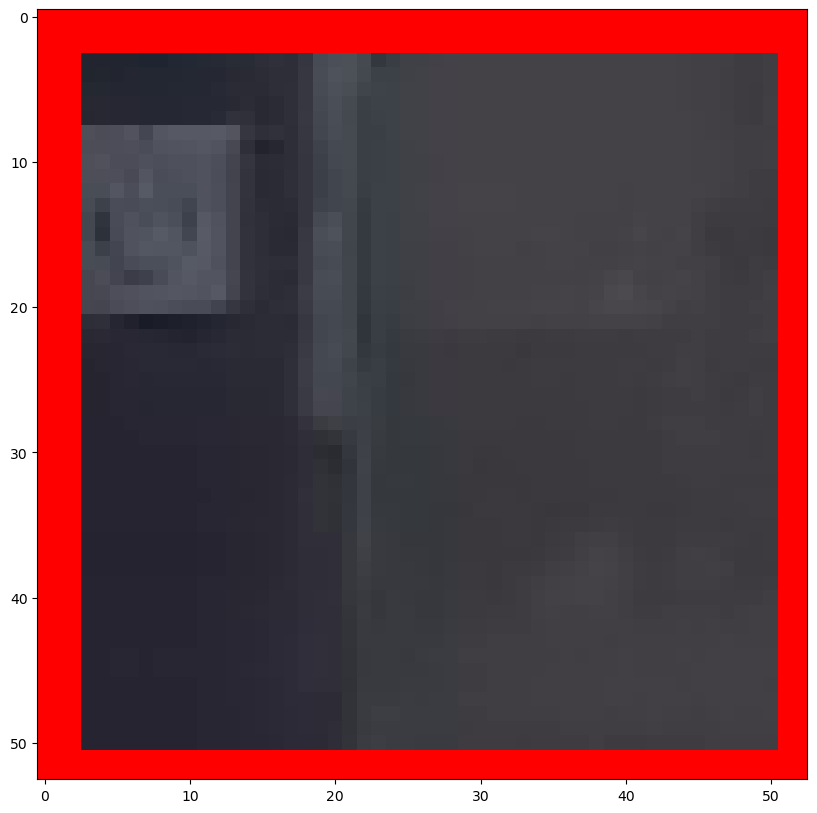




False 1
entered show


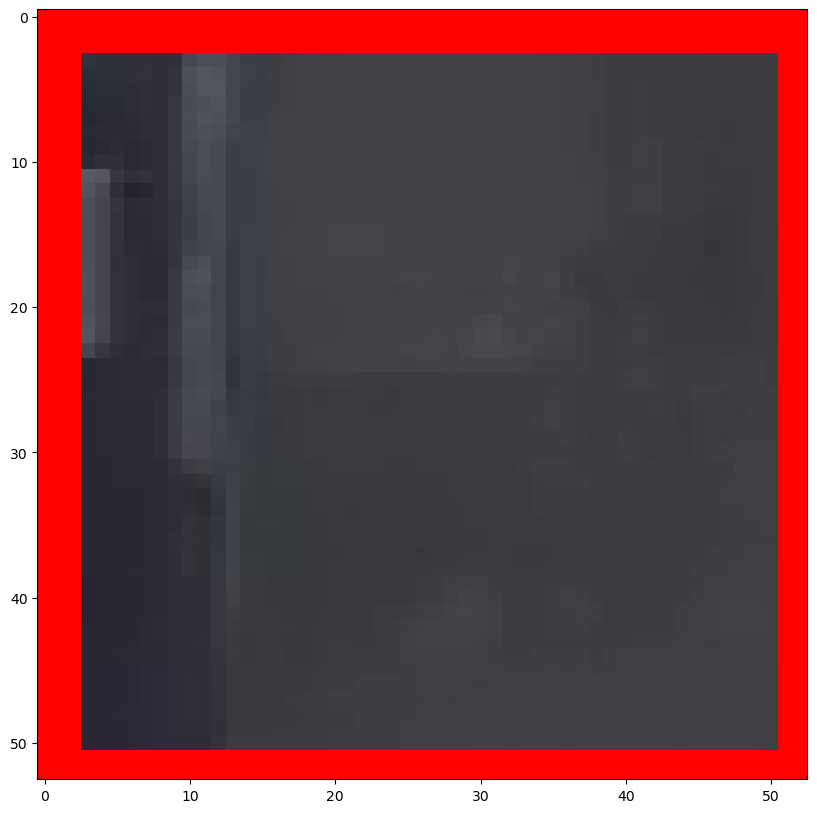




False 1
entered show


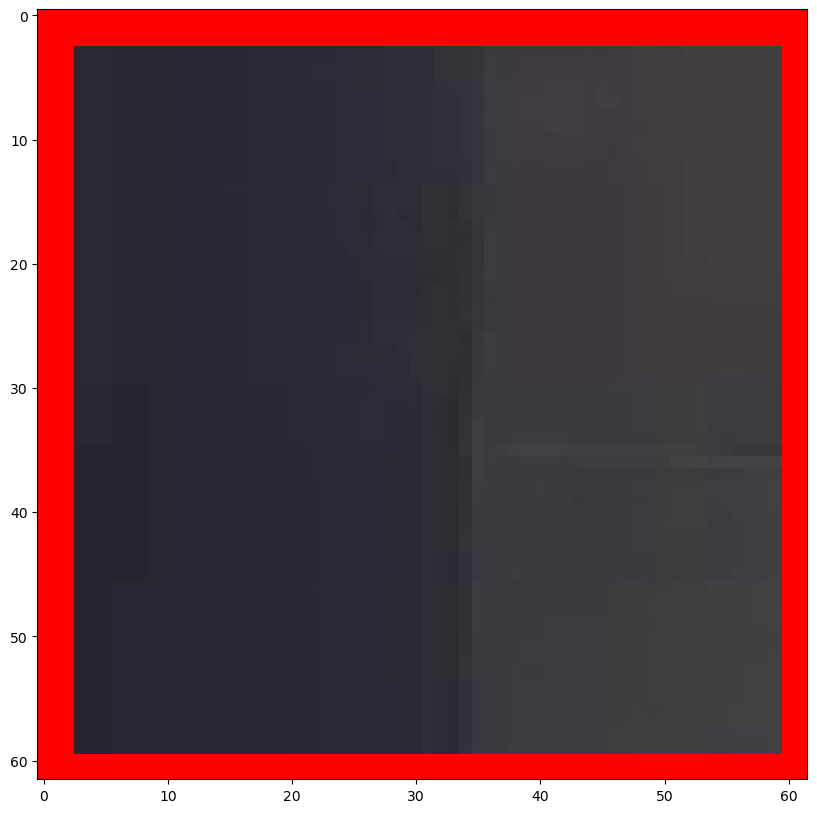




True 1
entered show


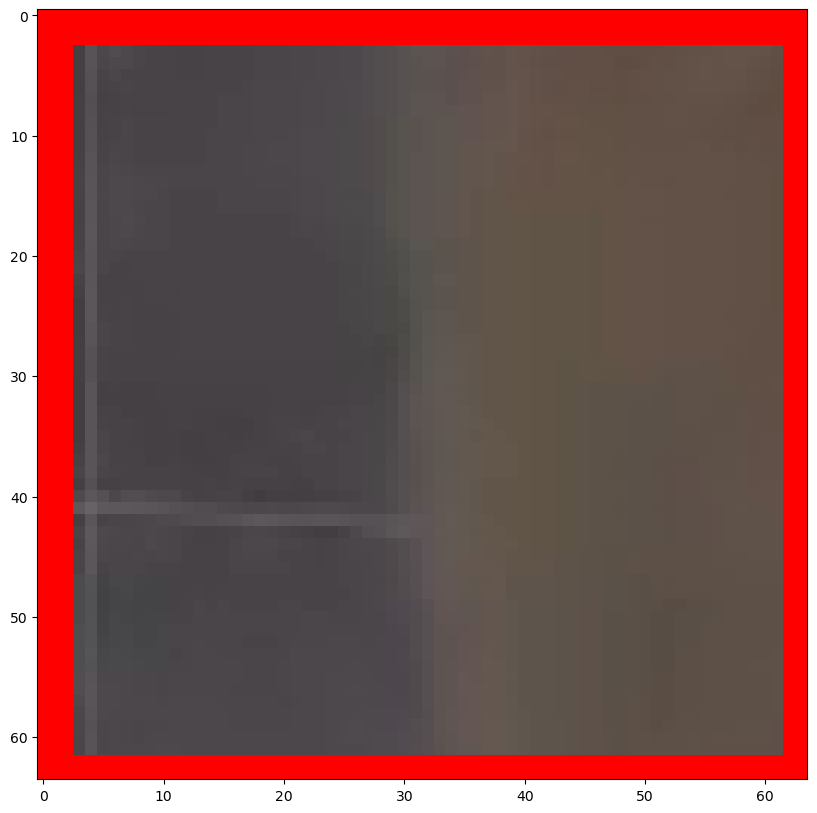

True 2
entered show


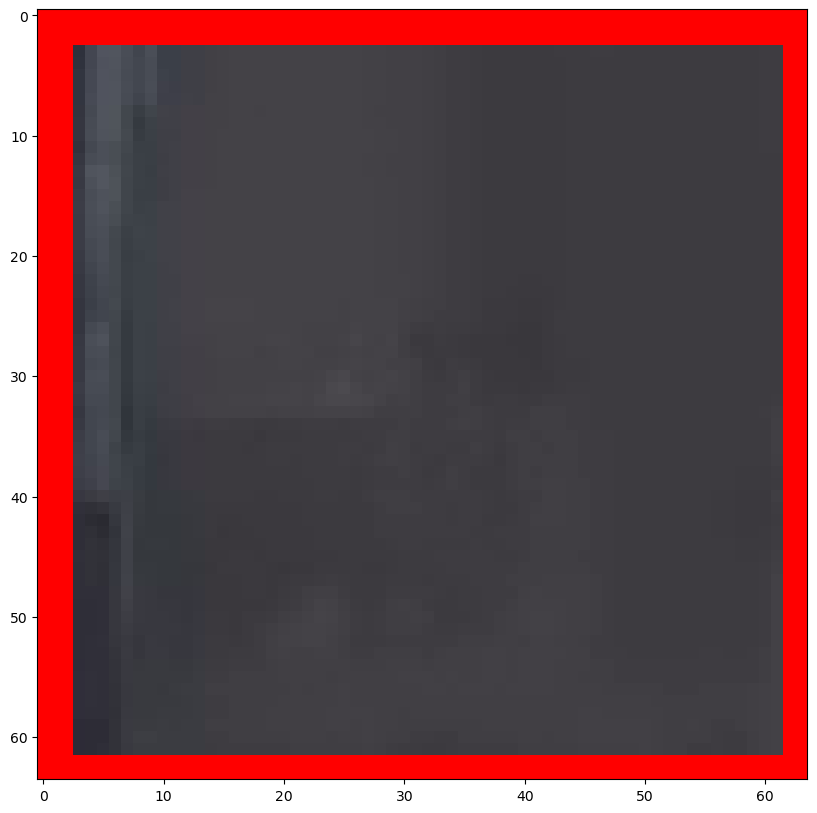




True 1
entered show


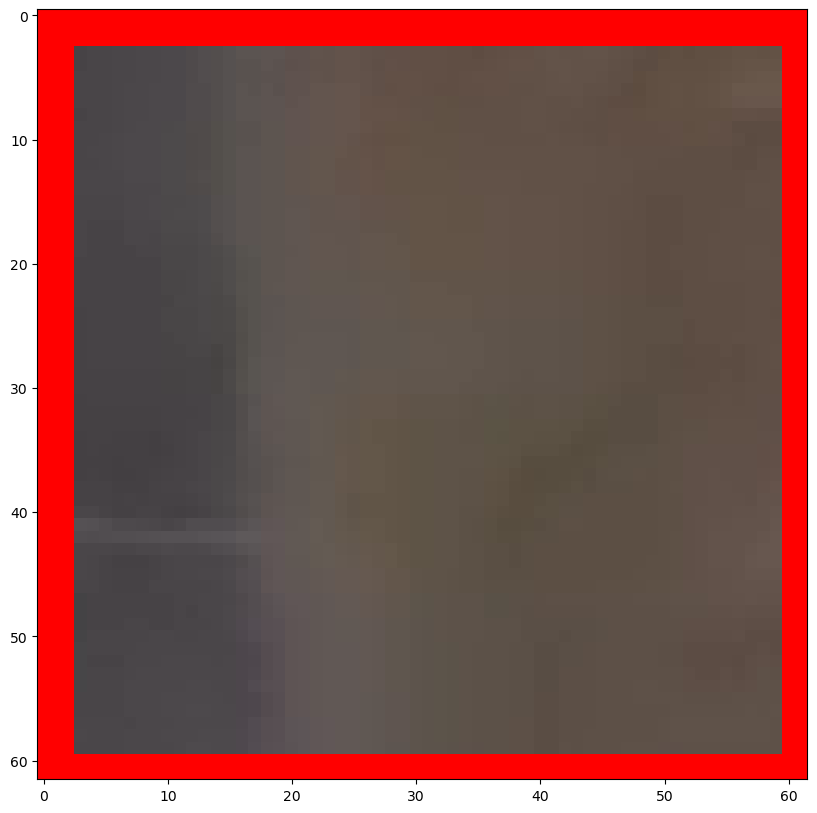

True 2
entered show


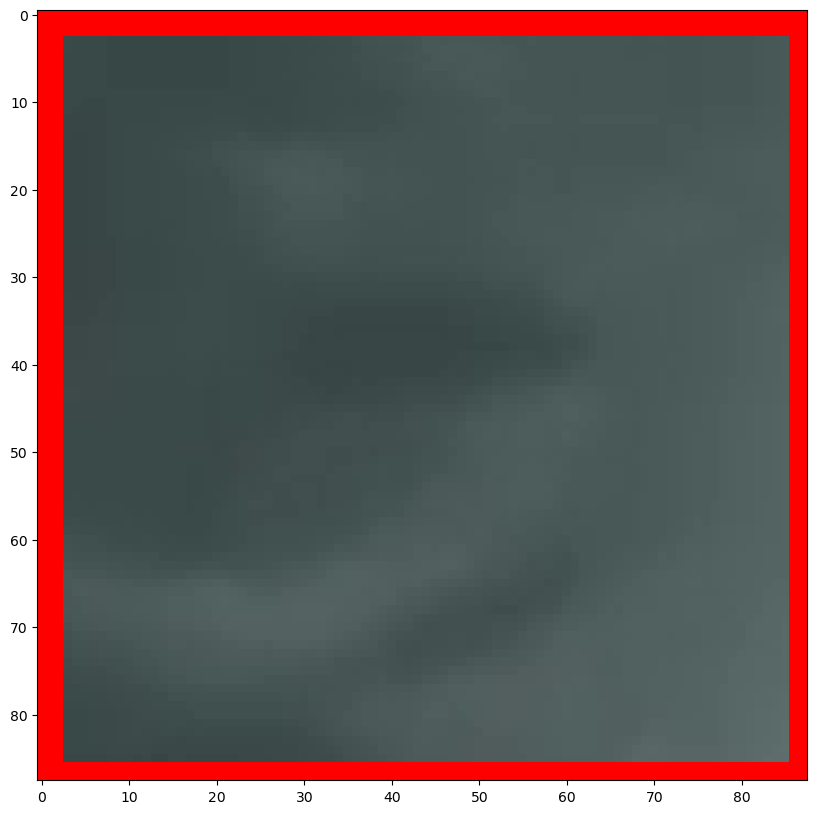




True 1
entered show


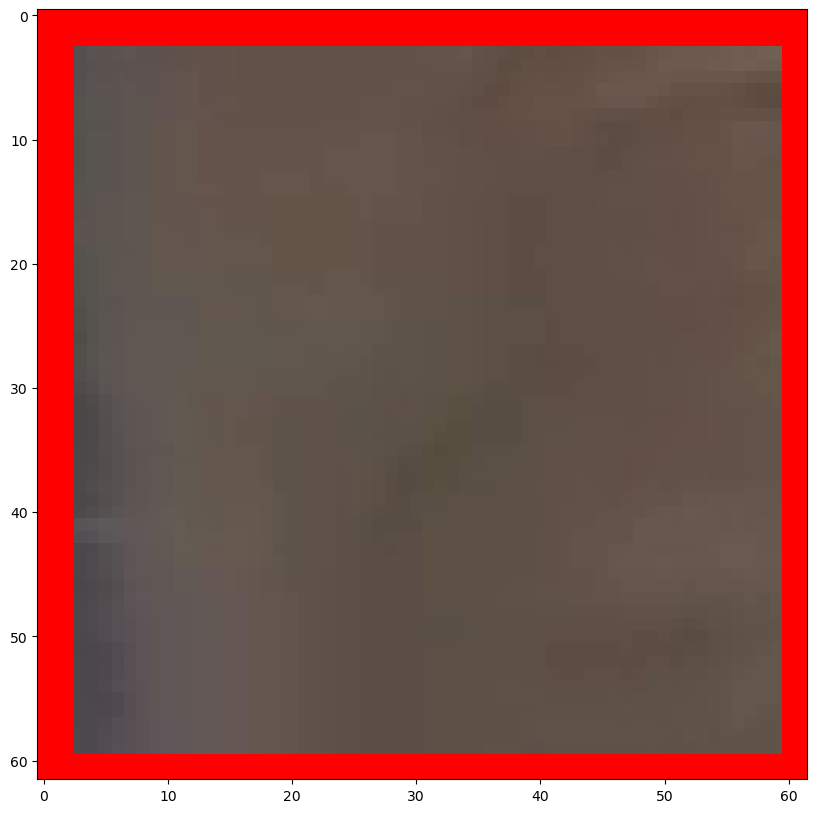

True 2
entered show


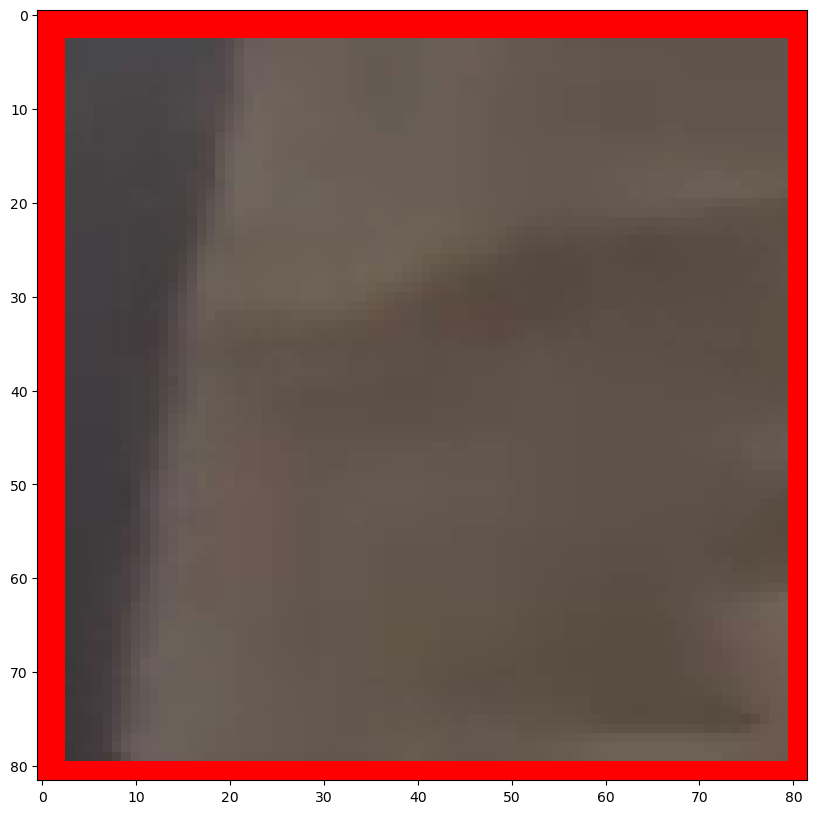




True 1
entered show


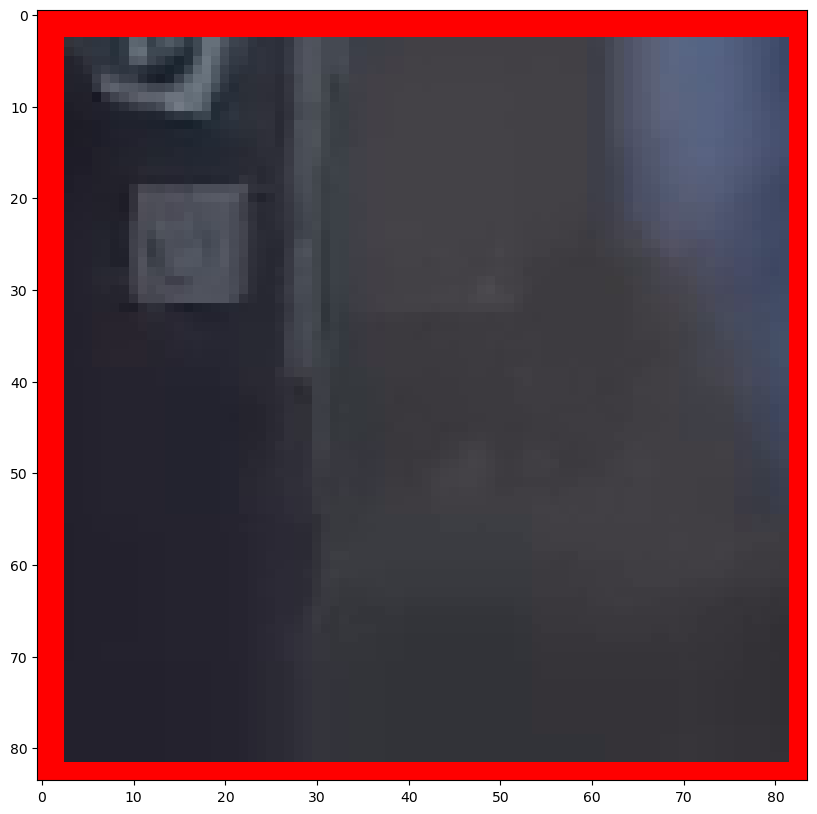




True 1
entered show


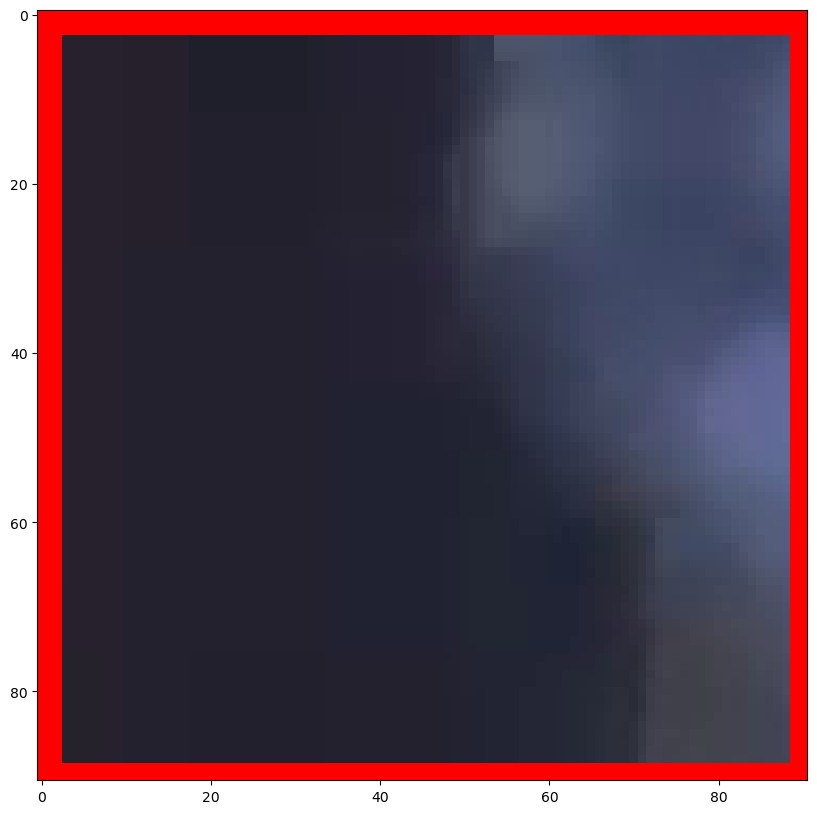




True 1
entered show


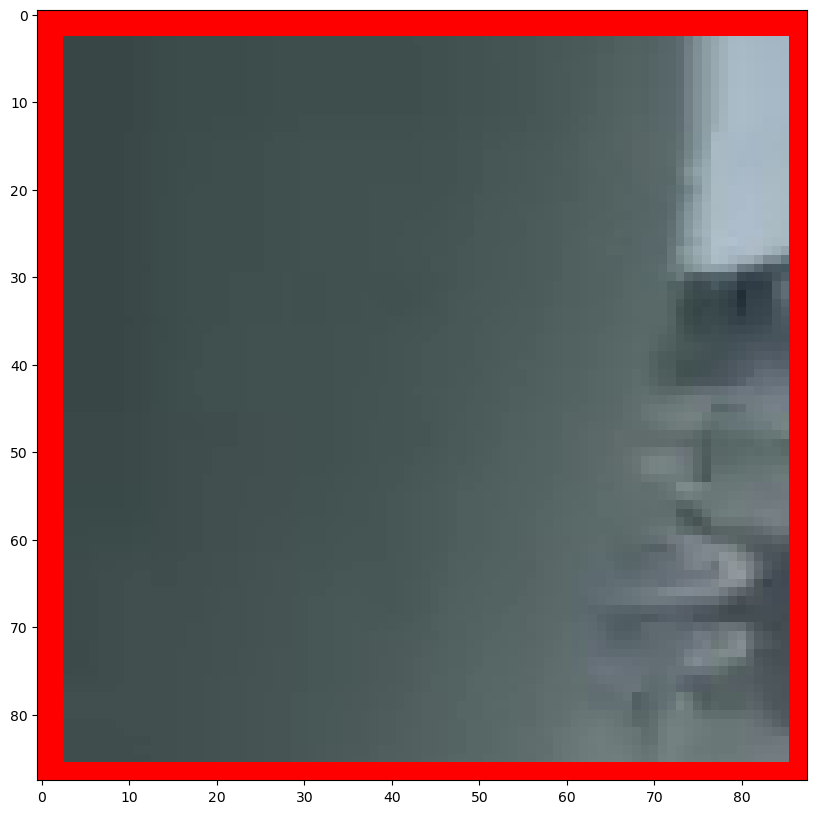

True 2
entered show


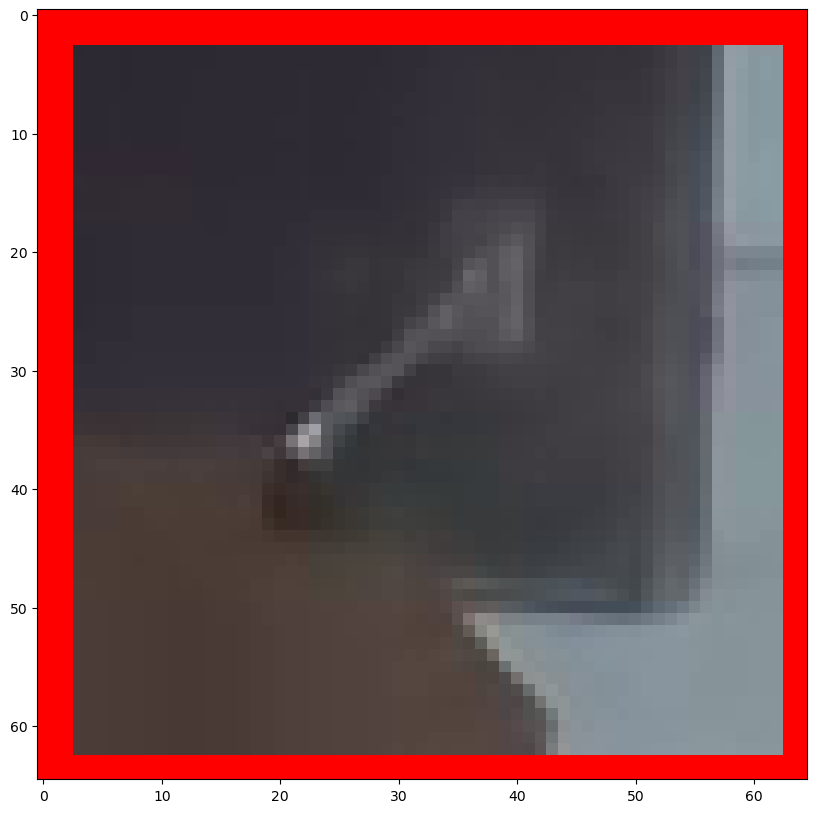




True 1
entered show


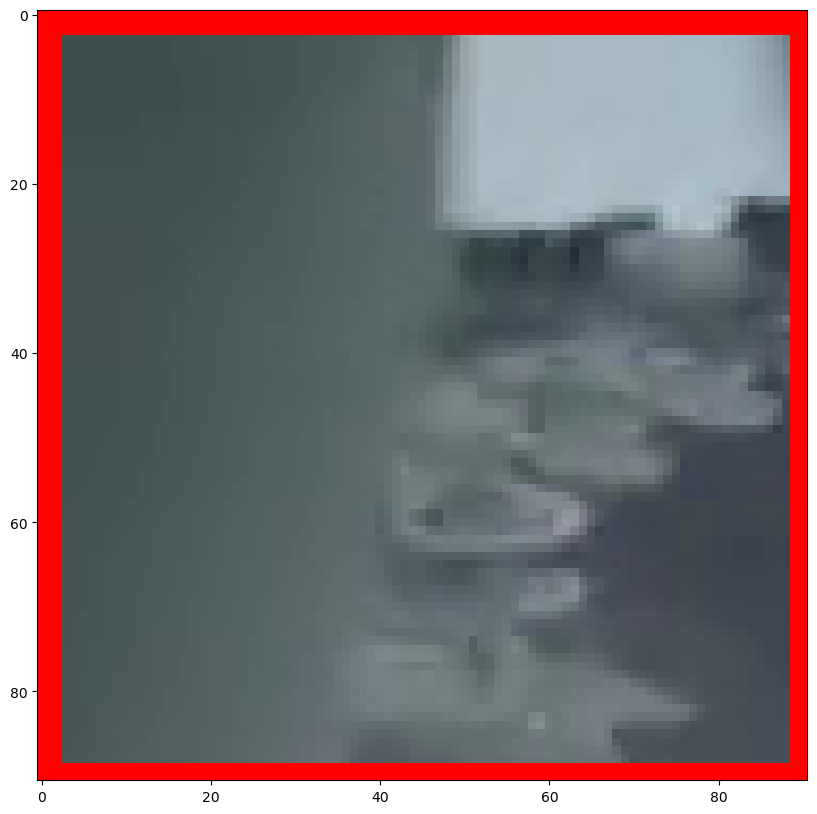




True 1
entered show


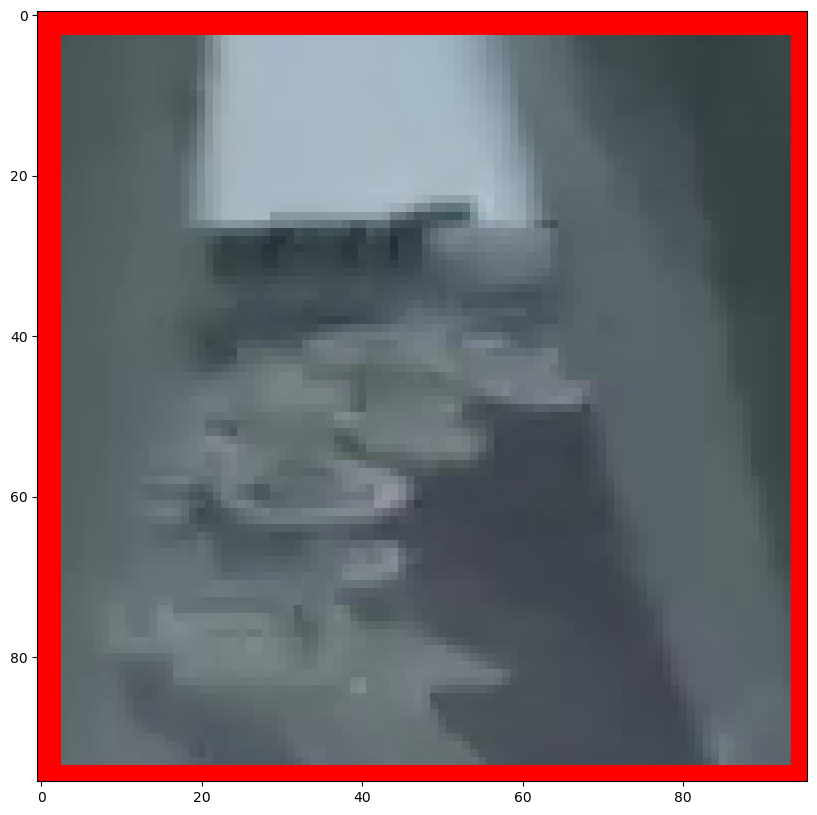




True 1
entered show


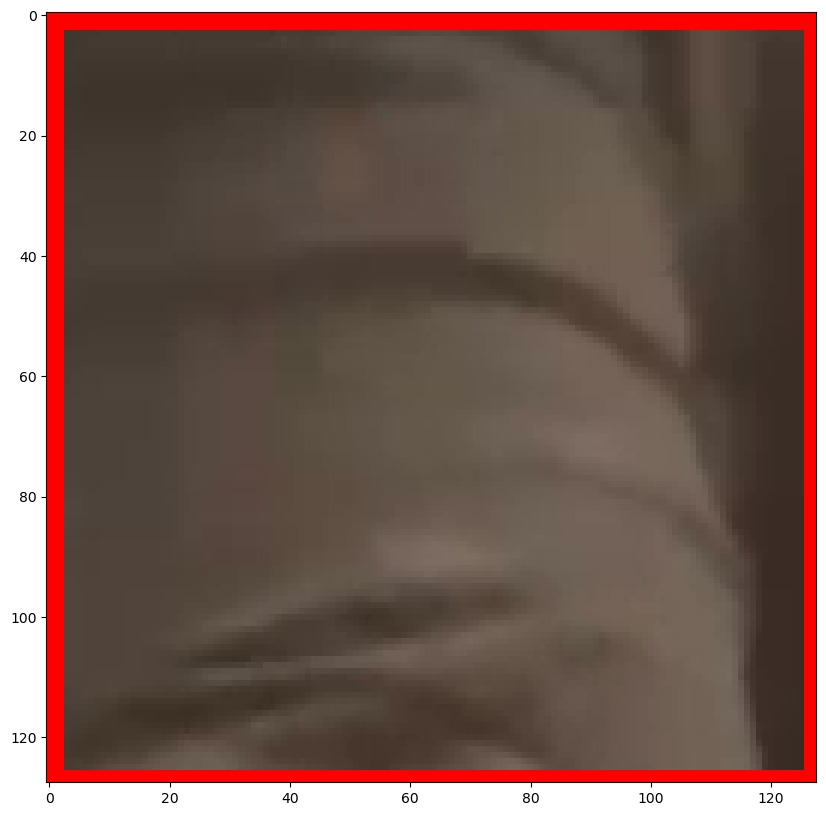

True 2
entered show


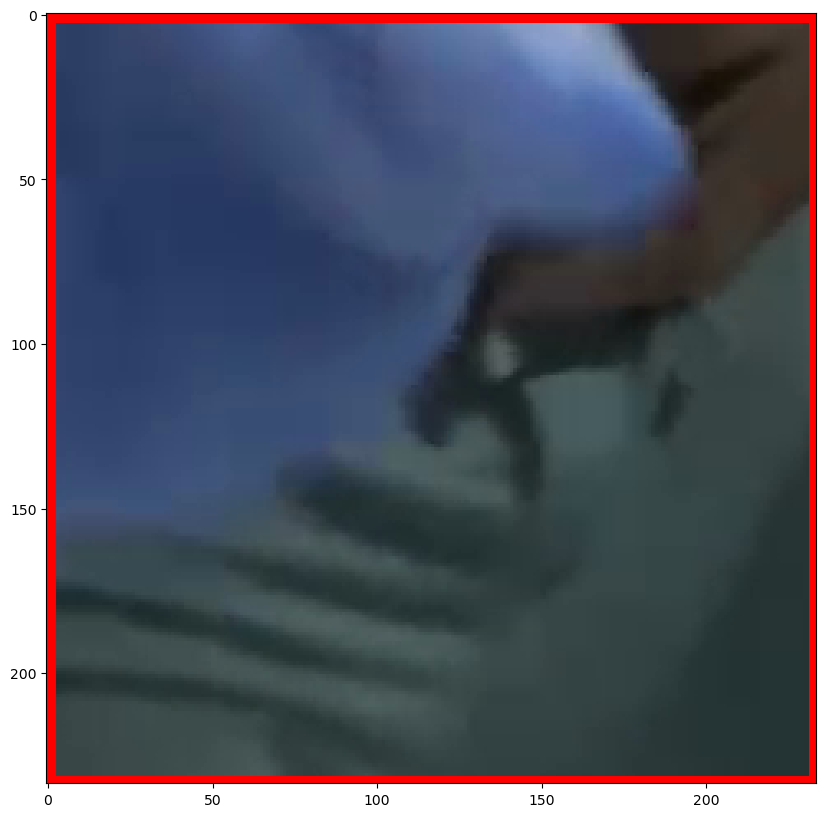

True 3
entered show


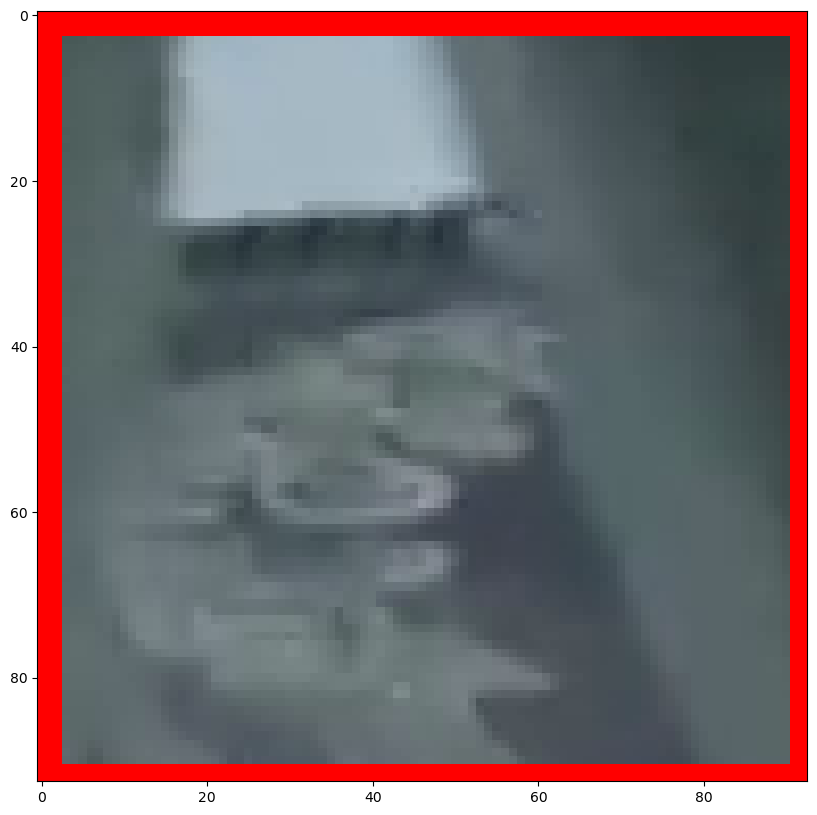




True 1
entered show


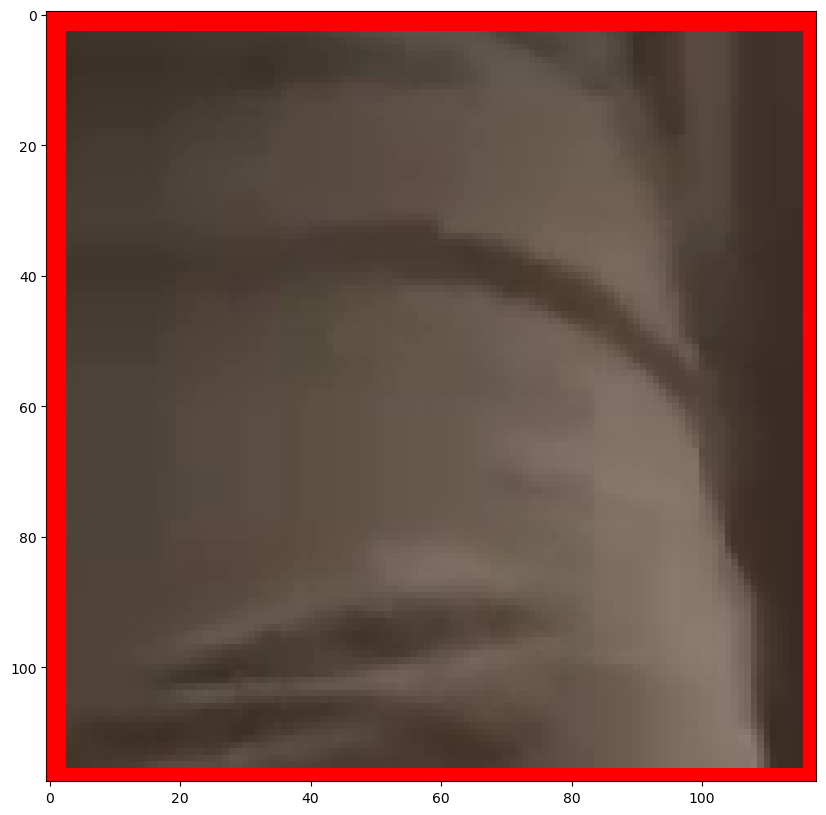

True 2
entered show


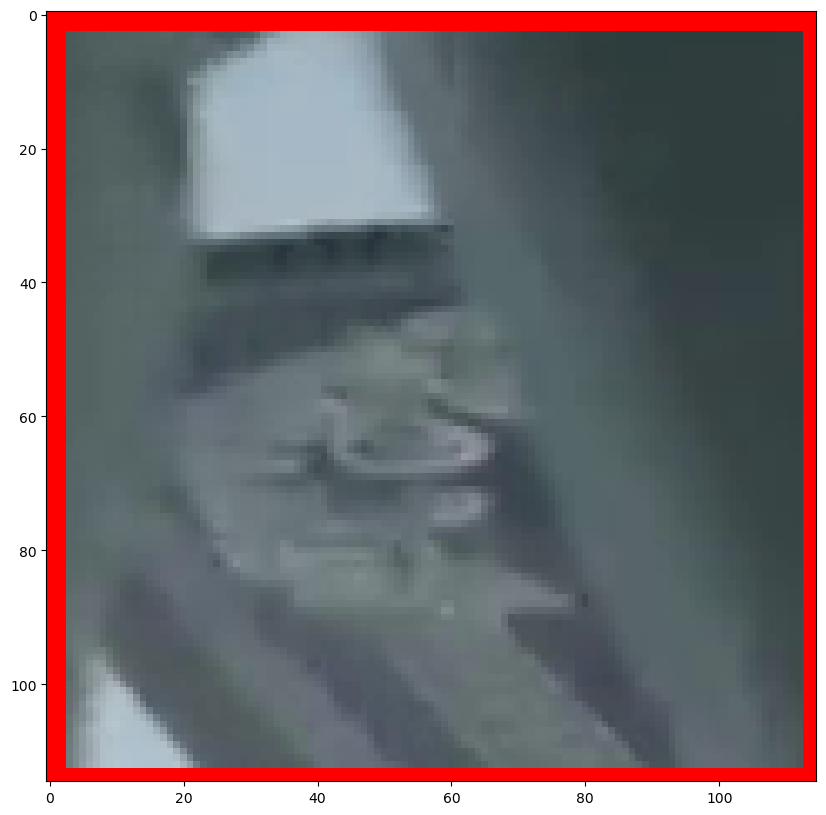




True 1
entered show


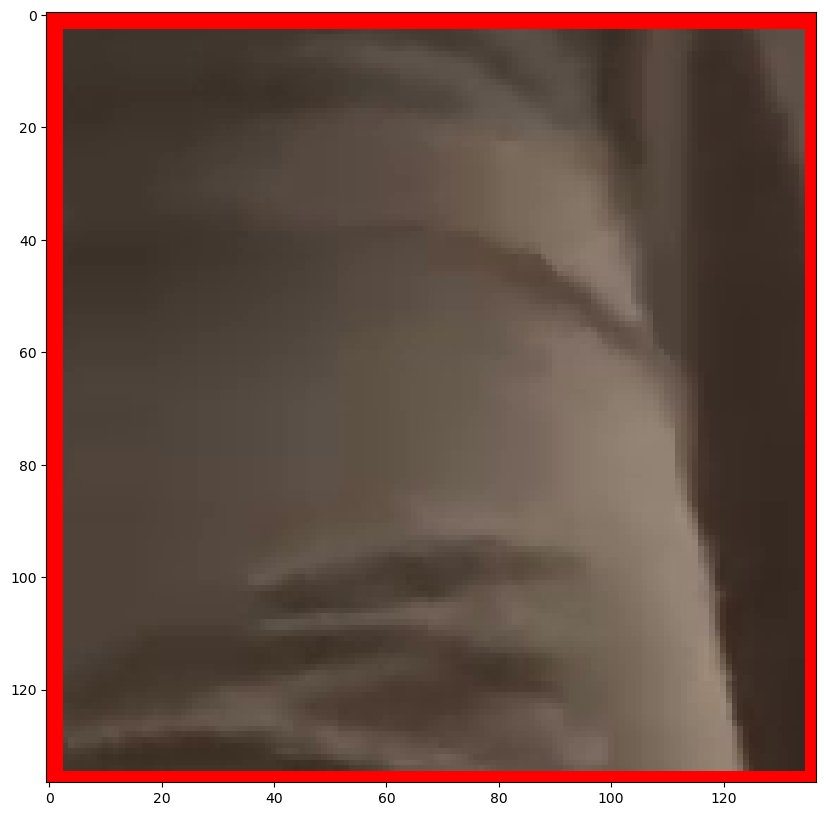




True 1
entered show


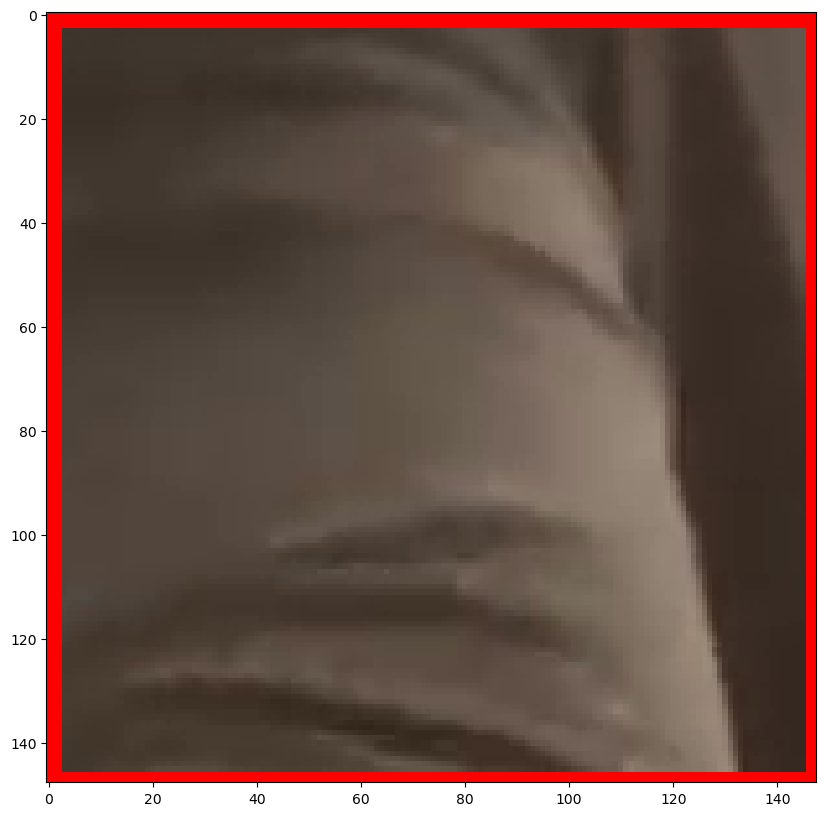




True 1
entered show


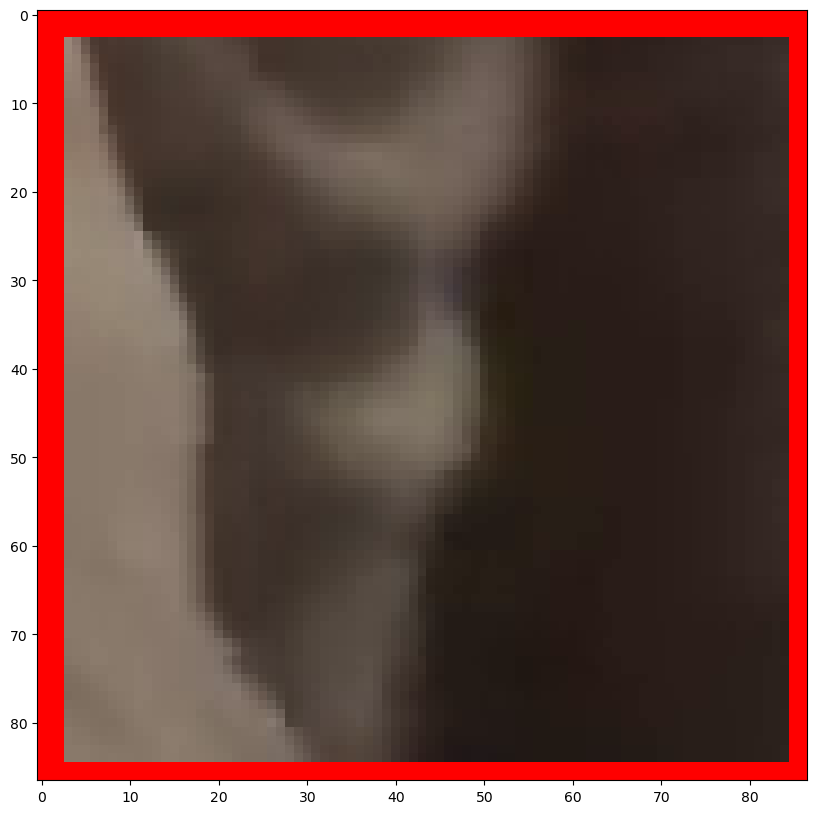




True 1
entered show


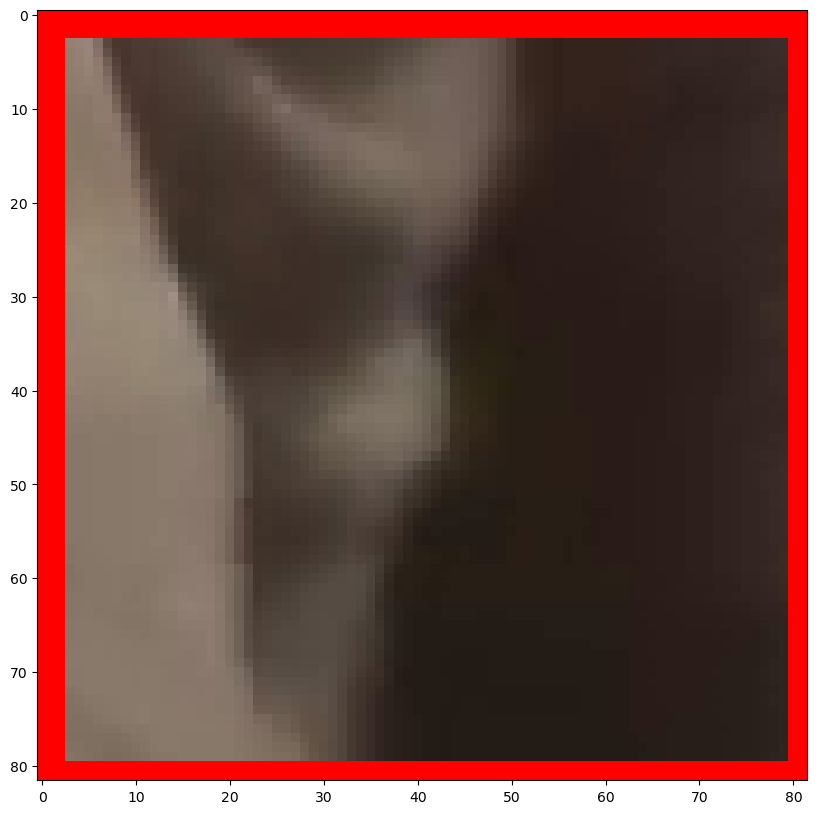




True 1
entered show


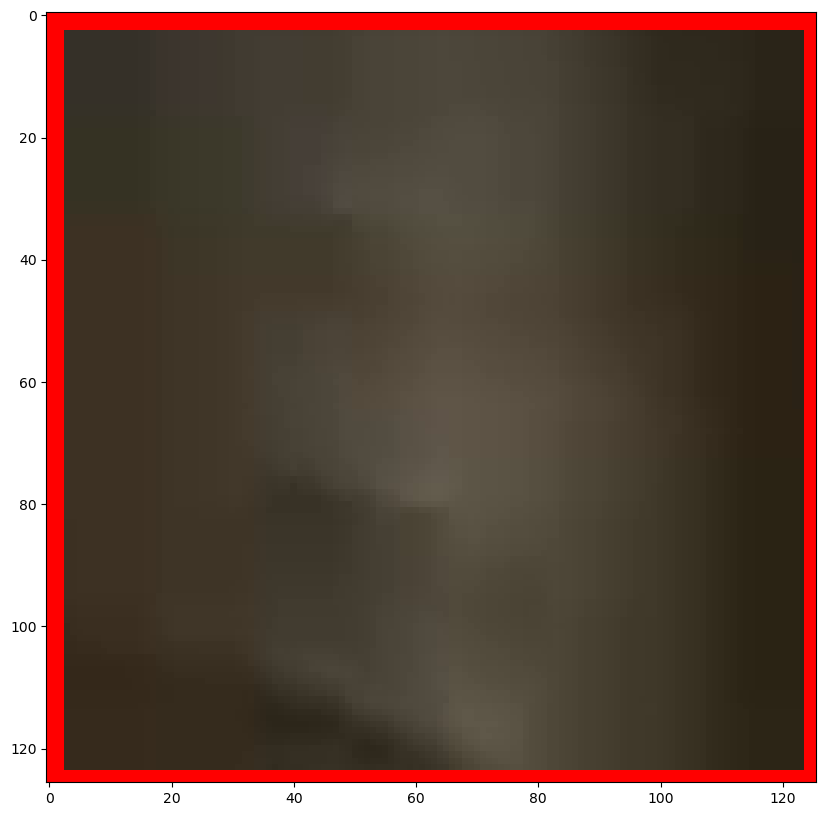




True 1
entered show


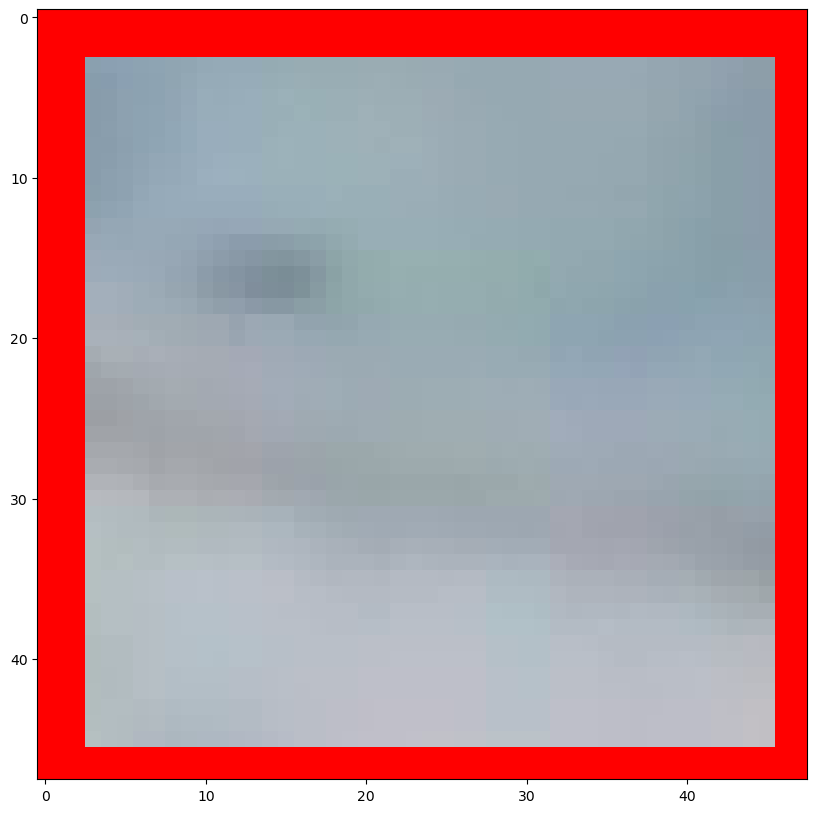

In [ ]:
import cv2
import numpy as np
import face_recognition as FRE
import math
import time
from typing import List,Dict,Sequence
import face_recognition as FR
import pickle
import matplotlib.pyplot  as plt

def show(img,cma='gray'):
    print("entered show")
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cma)

    plt.show()
class Point:
    def __init__(self,x,y):
        self.x=x
        self.y=y
    
    def __str__(self):
        return f"[{self.x},{self.y}]"
    def coords(self):
        return (self.x,self.y)

class Box: 
    def __init__(self,x:int,y:int,w:int,h:int):
        self.TL=Point(x,y)
        self.w=w
        self.h=h
        self.BL=Point(x,y+h)
        self.TR=Point(x+w,y)
        self.BR=Point(x+w,y+h)
        self.centre=Point(x+w//2,y+h//2)
        
    def __str__(self):
        
        return f"{self.TL} {self.TR} {self.BL} {self.BR}"
    

def nameread()->str : 
    return 'name1'



        
def betweenBox(b1,b2,axis=0):
    if ((b1.TL.x<=b2.TL.x and b2.TL.x<=b1.TR.x) or (b1.TL.x<=b2.TR.x and b2.TR.x<=b1.TR.x)):
        
        return True
    else:
        return False
    
def hypolen(s,w,inverse=False):
    if inverse:
        return abs(w/math.cos(((math.pi/2)-math.atan(s))))
        
    return abs(w/math.cos(math.atan(s)))

def dist(p1,p2):
    return math.sqrt(((p1.x-p2.x)**2)+((p1.y-p2.y)**2))

def slope(p1:Point  ,p2:Point) ->float:
    if  (p1.x-p2.x)!=0:
        return (p1.y-p2.y)/(p1.x-p2.x)
    else:
        return (p1.y-p2.y)/(1)
    
def closeproximity(b1,b2,aproxmin,multi):
    s=slope(b1.centre,b2.centre)
    
    if not (betweenBox(b1,b2,0)):
        base1=b1.w
        base2=b2.w
        inverse=False
    else:
        base1=b1.h
        base2=b2.h
        inverse=True
    
    # print("isbetweeb" ,betweenBox(b1,b2,0))
    
    hyp1=hypolen(s,base1,inverse)
    # print(hyp1)
    hyp2=hypolen(s,base2,inverse)
    # print(hyp2)
    hyp=hyp1+hyp2
    
    # print("total dist is",dist(b1.centre,b2.centre))
    if dist(b1.centre,b2.centre) >hyp+ aproxmin*multi:
        return False
    else:
        return True




def combiner(b1:Box,b2:Box,s:float):
    if s<0:
        sortedpo=sorted([b1.TR,b1.BL,b2.TR,b2.BL],key=lambda x: x.x)
        # TR=sortedpo[-2:].sort(key=lambda x: x.y)[-1]  
        # BL=sortedpo[:2].sort(key=lambda x: x.y)[0]  
        TR=min(sortedpo[-2:],   key=lambda x: x.y) 
        BL=max(sortedpo[:2],   key=lambda x: x.y) 
        return Box(BL.x,TR.y,TR.x-BL.x,BL.y-TR.y)
    
    else:
    
        sortedpo=sorted([b1.TL,b1.BR,b2.TL,b2.BR],key=lambda x: x.x)
        # print([i.x for  i in sortedpo])
        TL=min(sortedpo[:2],   key=lambda x: x.y) 
        BR=max(sortedpo[-2:],   key=lambda x: x.y) 
        # TL=sortedpo[:2].sort(key=lambda x: x.y)[-1] 
        # BR=sortedpo[-2:].sort(key=lambda x: x.y)[0]  
        return Box(TL.x,TL.y,BR.x-TL.x,BR.y-TL.y)
        
        



def coordsToBoxes(coordslist):
    return  [Box(*i) for i in coordslist]

def BoxesToCoords(boxlist:list[Box])->list[tuple[int,int,int,int]]:
            return [ (b.TL.x,b.TL.y,b.w,b.h) for b in boxlist ] 

def lessen_boxes(boxarray:list[Box],resolution=(1080,720)):
    for i in range(len(boxarray)):
        for j in range(i+1,len(boxarray)):
            while closeproximity(boxarray[i],boxarray[j],resolution[1],0.7):
                # print("i and j are ",i,j)   
                # print("while iteration")
                # print("pre change ",[ str(i) for i in boxarray])
                
                boxarray[i]=combiner(boxarray[i],boxarray[j],slope(boxarray[i].centre,boxarray[j].centre))
                
                boxarray.remove(boxarray[j])
                # print("post change",[ str(i) for i in boxarray])
                if j>len(boxarray)-1:
                    break
            if j>len(boxarray)-1:
                break
    # print("\n")
    return boxarray




def frame_large_countours(knnmask,minarea=5000,give_contours=False)->np.ndarray|tuple[np.ndarray, tuple[tuple, list[int]]]:
    cnt_indexes=[]
    rectangles=[]
    kernal=np.ones((2,2))
    fg=cv2.erode(knnmask.copy(),kernal,iterations=1)
    fg=cv2.dilate(fg           ,kernal,iterations=1)
    cnts,hierarchy=cv2.findContours(knnmask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for i in range(len(cnts)):
            if hierarchy[0][i][3]==-1:
                if cv2.contourArea(cnts[i])>minarea:
                    rectangles.append(np.array(cv2.boundingRect(cnts[i])))
                    if give_contours:
                        cnt_indexes.append(i)
    if give_contours:
        return (np.array(rectangles),(cnts,cnt_indexes))
    return np.array(rectangles)
    

            
def detect_faces(rectangles:list[tuple[int, int, int, int]],frame,CasType=2,minstandard=25):
    # cascades = {
    # 1: cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml",
    # "alt": cv2.data.haarcascades + "haarcascade_frontalface_alt.xml",
    # 2: cv2.data.haarcascades + "haarcascade_frontalface_alt.xml",
    # "alt2": cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml",
    # 0: cv2.data.haarcascades + "haarcascade_frontalface_default.xml",
    # "default": cv2.data.haarcascades + "haarcascade_frontalface_default.xml",
    # 3: cv2.data.haarcascades + "haarcascade_frontalface_alt_tree.xml",
    # "alt_tree": cv2.data.haarcascades + "haarcascade_frontalface_alt_tree.xml",
    # }
    
    
    cascades = {
             2:  r"D:\zaynu\Documents\projects\home_camera_proj\dat\haarcascades\haarcascade_frontalface_alt2.xml",
        "alt2":  r"D:\zaynu\Documents\projects\home_camera_proj\dat\haarcascades\haarcascade_frontalface_alt2.xml",
         "alt":  r"dat\haarcascades\haarcascade_frontalface_alt.xml",
             1:  r"dat\haarcascades\haarcascade_frontalface_alt.xml",
             0:  r"dat\haarcascades\haarcascade_frontalface_default.xml",
     "default":  r"dat\haarcascades\haarcascade_frontalface_default.xml",
             3:  r"dat\haarcascades\haarcascade_frontalface_alt_tree.xml",
    "alt_tree":  r"dat\haarcascades\haarcascade_frontalface_alt_tree.xml",
    }
    alldetectedfaces=[]
    cascade_path=cascades[CasType]
    detector = cv2.CascadeClassifier(cascade_path)
    
    for x,y,w,h in rectangles:
        # show(frame[y:y+h,x:x+w])
        facesqr=detector.detectMultiScale3(
            frame[y:y+h,x:x+w],    
            scaleFactor=1.05,
            outputRejectLevels=True
        )
        if len(facesqr[0]):
            # print(facesqr)
            alldetectedfaces.extend(facesqr[0][facesqr[2][0]>minstandard])
        
    if len(alldetectedfaces):
        return np.array(alldetectedfaces)[0]
    return np.array(alldetectedfaces)
 
    
def give_embed_file(cam_name)->Dict:
    if w_or_b[cam_name]==1:
        with open(r"D:\zaynu\Documents\projects\home_camera_proj\dat\known_embeds\whitelist.pkl","rb") as f:
            return pickle.load(f)
    else:
        with open(r"dat\known_embeds\blacklist.pkl","rb") as f:
            return pickle.load(f)
embedtimes=[]
def person_identifiction(alldetectedfaces:np.ndarray,     frame:np.ndarray  ,W_B_list:np.ndarray ,known_face_names:np.ndarray)->List[str]:   
    global embedtimes
    # print("entered person identification")
    s=time.time()
    embeds=FR.face_encodings(frame,alldetectedfaces,model="Large")
    embedtimes.append(time.time()-s)
    indentified_names=[]
    for  face_encoding in  embeds:
        # Compare with known faces
        # matches = FR.compare_faces(W_B_list, face_encoding, tolerance=0.6)
        # name = known_face_names[matches]

        # Find best match (minimum distance)
        face_distances = FR.face_distance(W_B_list, face_encoding)
        
        if face_distances.min()<0.7:
            best_match_index = face_distances.argmin()
            name=known_face_names[best_match_index]
            indentified_names.append( name)
        else:
            indentified_names.append("Unknown")
            
            
    # people=["name1"]
    return indentified_names





def coords_to_TRBL(coords:np.ndarray):
    res=[]
    for x,y,w,h in coords:
        res.append([y,x+w,y+h,x])
    return np.array(res)


w_or_b={'name1':1,'name2':0,'name3':1,'name4':1,}
name=nameread()
if w_or_b[name]:
    t=give_embed_file(name)
    checklist=t["encodings"]
    namelist=t["names"]
    
else:
    t=give_embed_file(name)
    checklist=t["encodings"]
    namelist=t["names"]
    
####################################################################################################################
####################################################################################################################
####################################################################################################################
# cap=cv2.VideoCapture(0) 
# cap=cv2.VideoCapture(r"dat\testdat\anirudhmoving.mp4")
# cap=cv2.VideoCapture(r"dat\testdat\camerafootage.mp4")
cap=cv2.VideoCapture(r"D:\zaynu\Documents\projects\home_camera_proj\dat\testdat\roomwalk.mp4")



####################################################################################################################
####################################################################################################################
####################################################################################################################

knnsubstractor=cv2.createBackgroundSubtractorKNN(detectShadows=False)
ret,frame=cap.read()

if ret:
    fgcnted=np.zeros((frame.shape[0],frame.shape[1],3))
    minarea=int(frame.shape[1]*3)
    print(minarea)
    # print(minarea/7.5)
else:
    fgcnted=np.zeros((1280,720,3))
    minarea=int(720*9.5)
    print("no ret")

frameno=0
s=time.time()
namesfoundcnt={"Zaynul":0,"Unknown":0}
detected_at=-15
while True:
    
    # print("hello")
    if cv2.waitKey(1)==ord('q'):
        break
    # if cv2.waitKey(0)==ord('k'):
    #     pass
    ret,frame=cap.read()
    if ret:
        frameno+=1
        if frameno==2:
            time.sleep(2)
            s=time.time()
            

        knnmask=knnsubstractor.apply(frame)

        kernal=np.ones((3,3))
        fg=cv2.erode(knnmask.copy(),kernal,iterations=3)
        fg=cv2.dilate(fg,           kernal,iterations=3)
        fg[np.abs(fg)<250]=0
        
        tempfg=fg.copy()
        if fg[fg>0].size >knnmask.size*0.05 and frameno > detected_at+15:
            
            rectangles,(counturs,cntIndexes)=frame_large_countours(fg,minarea,give_contours=True)
            
            boxes=coordsToBoxes(rectangles)
            
            combined_rectangles=BoxesToCoords(lessen_boxes(boxes,fg.shape[:2]))
            
            grayframe=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
            
            detected_faces=detect_faces(combined_rectangles,grayframe,CasType=2,minstandard=15)
            
            if detected_faces.size:
                
                #detected_at=frameno
                #RGBframe=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
                #detectedpeople=person_identifiction(coords_to_TRBL(detected_faces),RGBframe,checklist,namelist)
            #
                ## print(detectedpeople)
                #for n in detectedpeople:
                #    namesfoundcnt[n]+=1
                _=1
                for x,y,w,h in detected_faces:
                    frame=cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),4)
                    tempfg=cv2.rectangle(tempfg,(x,y),(x+w,y+h),(255,0,0),4)
                
                    facebox=Box(x,y,w,h)
                    comb_rect_box=Box(*combined_rectangles[0])
                
                    print(betweenBox(comb_rect_box,facebox  ),(_))
                    show(frame[y:y+h,x:x+w])

                    _+=1
                print("\n\n")
                # print(detectedpeople[0])
                cv2.putText(frame,"person",(x+w//2,y),cv2.FONT_HERSHEY_COMPLEX,1,(255,255,0),4)
                cv2.putText(tempfg,"person",(x+w//2,y),cv2.FONT_HERSHEY_COMPLEX,1,(255,255,0),4)

            for x,y,w,h in combined_rectangles:
                frame=cv2.rectangle(frame,(x,y),(x+w,y+h),(0,0,255),4)
                tempfg=cv2.rectangle(tempfg,(x,y),(x+w,y+h),(0,0,255),4)
            for i in cntIndexes:
                cv2.drawContours(frame ,counturs,i,(0,255,0),3)
                cv2.drawContours(tempfg,counturs,i,(0,255,0),3)
        cv2.putText(tempfg,f"{tempfg[tempfg>0].size}",(100,100),cv2.FONT_HERSHEY_COMPLEX,1,(255,255,0),4)
            
        cv2.imshow("camview",frame) 
        cv2.imshow("fg",tempfg) 
        if cv2.waitKey(1)==ord('q'):
            e=time.time()
            print("timetaken",e-s)
            print(namesfoundcnt)
            
            break         
        if frameno==2400:
            e=time.time()
            print("timetaken",e-s)
            print(namesfoundcnt)
            break
        
cv2.destroyAllWindows()
cap.release()
embedtimes=np.array(embedtimes)
# print("avg embed time",embedtimes.mean())
# print("min embed time",embedtimes.min())
# print("max embed time",embedtimes.max())

            
            
            





